In [3]:
import os
import sys
from desitarget.targetmask import desi_mask, bgs_mask
# import some helpful python packages 
import os
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ'))
from desi_lowz_funcs import make_subplots


def find_objects_nearby(object_list, find_ra, find_dec, deg_rad = 1e-3,name_ra="",name_dec=""):
    
    mask = (np.abs(object_list[name_ra] - find_ra) < deg_rad) & (np.abs(object_list[name_dec] - find_dec) < deg_rad)
    return object_list[mask]



def get_zsucc_trends(lowz_all, rfib_bins, gr_bins,color = "g-r",fibmag="FIBERMAG_R",min_count = 10):
    '''
    Function computes the color binned redshift failure rate 
    '''

    all_zfails = []
    all_zfails_err = []

    for j in trange(len(gr_bins)-1):
        ## for a given color bin
        gr_low = gr_bins[j]
        gr_hi = gr_bins[j+1]
        
        lowz_i = lowz_all[(lowz_all[color] <= gr_hi) & (lowz_all[color] >= gr_low) ]        
        #################
        
        ##now I need to take this dataset to make a plot of redshift failure rate as a function of fiber magnitude ... 
        zfail_rate_i = []
        zfail_rate_err_i = []
    
        #looping over fiber mags 
        for r in range(len(rfib_bins) - 1):
            lowz_ij = lowz_i[(lowz_i[fibmag] >= rfib_bins[r]) & (lowz_i[fibmag] <= rfib_bins[r+1]) ]
            
            lowz_ij_zsucc = np.array(lowz_ij["ZSUCC_COUNT"]).astype(bool)
            
            #now compute the redshift failure rate 
            tot_num = len(lowz_ij)
            fail_num = len(lowz_ij[~lowz_ij_zsucc])
            succ_num = len(lowz_ij[lowz_ij_zsucc])
            
            if tot_num > min_count:
                fail_rate = fail_num/(fail_num + succ_num)
                rate_err = np.sqrt(  fail_rate * (1 - fail_rate) / tot_num )
                    
                #this is the error estimator from the binomial estimator
                zfail_rate_i.append(fail_rate)
                zfail_rate_err_i.append(rate_err)
            else:
                zfail_rate_i.append(np.nan)
                zfail_rate_err_i.append(np.nan)
                
        all_zfails.append(np.array(zfail_rate_i))
        all_zfails_err.append(np.array(zfail_rate_err_i))
                
    fb_vals = 0.5*(rfib_bins[1:] + rfib_bins[:-1])
    
    return fb_vals, all_zfails, all_zfails_err


from scipy.stats import binned_statistic_2d

def get_zsucc_2d_vals(lowz_all, rfib_bins, gr_bins,color = "HALPHA_FLUX",fibmag="FIBERMAG_R",num_samp=10,min_count=10,output_2d=False):
    '''
    Function computes the redshift failure rate in each 2D bins of rfiber and gr_bins

    '''
    
    ##computing the statistics with just the original value
    zsucc_org, _, _,_= binned_statistic_2d(lowz_all[fibmag], lowz_all[color], np.array(lowz_all["ZSUCC_COUNT"]) , statistic=np.mean, bins=[rfib_bins, gr_bins])
    tot_org, _, _,_= binned_statistic_2d(lowz_all[fibmag], lowz_all[color], np.array(lowz_all["TOT_COUNT"]) , statistic=np.sum, bins=[rfib_bins, gr_bins])
        
    ## we only use bins where tot_count > 10
    zsucc_org[tot_org < min_count] = np.nan
    
    zfail_org = 1 - zsucc_org
    ## now we compute the rest

    #we can compute the error on this using binomial normal approx.
    sigma_errs = np.array(1/np.sqrt(lowz_all[color + "_IVAR"]))
    sigma_errs[np.isinf(sigma_errs)] = 0
    mus = np.array(lowz_all[color])
    
    all_zfail_stat = []
    all_ztot_stat = []
    
    for _ in range(num_samp):
#         ## generate a new realiztion of the halpha flux vals
        new_mus = np.random.normal(loc=mus, scale= sigma_errs)
        #just make sure they are not negative
        new_mus[new_mus < 0] = 0
        
        ztot_stat, _,_,_= binned_statistic_2d(lowz_all[fibmag], lowz_all[color], np.array(lowz_all["TOT_COUNT"]) , statistic=np.sum, bins=[rfib_bins, gr_bins])
        zsucc_stat, _,_,_= binned_statistic_2d(lowz_all[fibmag], new_mus, np.array(lowz_all["ZSUCC_COUNT"]) , statistic=np.mean, bins=[rfib_bins, gr_bins])
        
        #zsucc stat is a 2d array, converting to failure rate
        zfail_stat = 1 - zsucc_stat
        
        #only keep if a certain bin has more than 10 objects?
        zfail_stat[ztot_stat < min_count] = np.nan
        #add to list
        all_zfail_stat.append(zfail_stat)
        
    all_zfail_stat = np.array(all_zfail_stat)
    
    #compute the mean and standard deviation along each cell

    zfail_mean = np.nanmean(all_zfail_stat,axis = 0)
    zfail_std = np.nanstd(all_zfail_stat,axis = 0)
    
              
    if output_2d:
        return zfail_org, zfail_mean, zfail_std
    
    else:
        #make the output format same as above function
        #essentially is a list where each element is a list focused on one Halpha value
        gr_cens = 0.5*(gr_bins[1:]+gr_bins[:-1])
        rfib_cens = 0.5*(rfib_bins[1:]+rfib_bins[:-1])
        gr_M,rfib_M = np.meshgrid(gr_cens,rfib_cens)
        #lenght is going to be how many ever gr bins we have
        fb_vals = []
        all_zfails = []
        all_zfails_org = []
        all_zfails_err = []
        
        for i in range(len(gr_cens)):
            fb_vals_i = rfib_M[:,i]
            zfail_mean_i = zfail_mean[:,i]
            zfail_org_i = zfail_org[:,i]
            zfail_std_i = zfail_std[:,i]
            
            all_zfails.append(zfail_mean_i)
            all_zfails_org.append(zfail_org_i)
            all_zfails_err.append(zfail_std_i)
            fb_vals.append(fb_vals_i)
            
        return fb_vals, all_zfails_org, all_zfails, all_zfails_err
            
            
            
            
scratch_dir = "/pscratch/sd/v/virajvm"

# Part 1) Read the DESI catalogs

Make plot similar to BGS TSNR2 - rfiber ...

In [2]:
## load the full catalog of BGS Bright Y1 objects 

bgs_bri = Table.read("/pscratch/sd/v/virajvm/catalog/jura_bgs_bright_all_phot_final_filter.fits")
# bgs_bri = Table.read("/pscratch/sd/v/virajvm/catalog/Iron_bgs_bright_all_phot_final_filter.fits")
bgs_bri = bgs_bri[bgs_bri["TSNR2_BGS"] > 0]


In [3]:
lowz_dark = Table.read("/pscratch/sd/v/virajvm/catalog/jura_lowz_dark_all_phot_final_fixed.fits")
# lowz_dark = Table.read("/pscratch/sd/v/virajvm/catalog/Iron_lowz_dark_all_phot_final_fixed.fits")

#the jura file does not have any photometric information so need to do that later ...



In [101]:
##defining redshift success here
bgs_bri["TOT_COUNT"] = np.ones(len(bgs_bri))
lowz_dark["TOT_COUNT"] = np.ones(len(lowz_dark))

def zsuccess_mask(gals, dchi2): 
    crit_zwarn = (gals['ZWARN'] == 0)
    crit_dchi2 = (gals['DELTACHI2'] > dchi2)
    crit_stype = (gals['SPECTYPE'] == 'GALAXY') | (gals['SPECTYPE'] == 'QSO')
    crit_z_lim = (gals['Z'] > 0.)
    # crit_z_err = (gals['ZERR'] < (0.0005 * (1. + gals['Z'])))
    zsuccess   = (crit_zwarn & crit_dchi2 & crit_stype & crit_z_lim)
    # zsuccess   = (crit_zwarn & crit_dchi2 & crit_z_lim)
    
    return zsuccess

bgs_bri["ZSUCC_COUNT"] = zsuccess_mask(bgs_bri, 0)

lowz_dark["ZSUCC_COUNT"] = zsuccess_mask(lowz_dark, 0)



In [6]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

/tmp/ipykernel_1510177/2775591801.py:8: RuntimeWarning: divide by zero encountered in log10
  coll_lz = ax[1].hexbin(lowz_dark["FIBERMAG_R"], np.log10(lowz_dark["TSNR2_BGS"]), C = lowz_dark["ZSUCC_COUNT"], gridsize =25, reduce_C_function = np.mean, extent = ( 16,24,1.5,5), vmin = 0, vmax = 1,mincnt = 25,


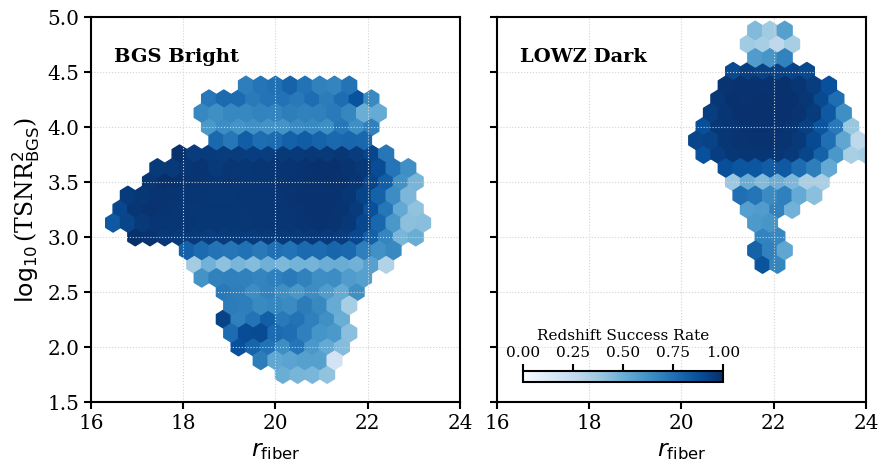

In [8]:
fig,ax = plt.subplots(1,2,figsize = (10,5),sharey=True)

plt.subplots_adjust(wspace = 0.1)

coll = ax[0].hexbin(bgs_bri["FIBERMAG_R"], np.log10(bgs_bri["TSNR2_BGS"]), C = bgs_bri["ZSUCC_COUNT"], gridsize =25, reduce_C_function = np.mean, extent = ( 16,24,1.5,5), vmin = 0, vmax = 1,mincnt = 25,
                 cmap = "Blues")

coll_lz = ax[1].hexbin(lowz_dark["FIBERMAG_R"], np.log10(lowz_dark["TSNR2_BGS"]), C = lowz_dark["ZSUCC_COUNT"], gridsize =25, reduce_C_function = np.mean, extent = ( 16,24,1.5,5), vmin = 0, vmax = 1,mincnt = 25,
                    cmap = "Blues")

# cb = plt.colorbar()
# cb.set_label("Redshift success rate",fontsize = 14)

# Create a colorbar for both plots
# divider = make_axes_locatable(ax[1])
# cax = divider.append_axes("right", size="5%", pad=0.05)
# plt.colorbar(coll_lz, cax=cax)

p  = ax[1].get_position().get_points().flatten()
# this is used to modify the position of the colorbar in the plot
# last number is thickness
cax= fig.add_axes([p[0]+0.07*(p[2]-p[0]) , p[1]+0.05*(p[3]-p[1]) , 0.2, 0.03*(p[3]-p[1])])
cbar = plt.colorbar(coll_lz, cax=cax, orientation='horizontal', ticklocation='top')
cbar.set_label(r'Redshift Success Rate', fontsize=11)
cbar.ax.tick_params(labelsize = 11)


ax[0].text(16.5, 4.6,"BGS Bright",fontsize = 14, weight = "bold")
ax[1].text(16.5, 4.6,"LOWZ Dark",fontsize = 14, weight = "bold")

for i in range(2):
    ax[i].set_xlim([16,24])
    ax[i].set_ylim([1.5, 5])
    ax[i].set_xlabel(r"$r_{\rm fiber}$",fontsize = 17)
    ax[0].set_ylabel(r"$\log_{10}$(TSNR$_{\rm BGS}^2$)",fontsize = 17)
    ax[i].grid(ls = ":",color = "lightgrey")
    
# plt.savefig("paper_plots/bgs_bright_lowz_rfib_tsnr2_zsucc.pdf",bbox_inches="tight")

plt.show()

# # ###
# from matplotlib.colors import LogNorm
# plt.figure(figsize = (7,5))
# coll_count = plt.hexbin(bgs_bri["FIBERMAG_R"], np.log10(bgs_bri["TSNR2_BGS"]), C = bgs_bri["TOT_COUNT"], gridsize = 20, reduce_C_function = np.sum, extent = ( 16,23,1.5,5), norm=LogNorm(vmin = 1, vmax = 1e3),mincnt = 1)
# plt.colorbar()
# plt.xlim([16,23])
# plt.ylim([1.5, 5])
# plt.xlabel(r"$r_{\rm fiber}$",fontsize = 17)
# plt.ylabel(r"log TSNR2_BGS",fontsize = 17)
# plt.hlines(y= 2,xmin=16,xmax = 23,color = "k",ls = "--")
# plt.hlines(y= 2.5,xmin=16,xmax = 23,color = "k",ls = "--")
# plt.hlines(y= 3,xmin=16,xmax = 23,color = "k",ls = "--")
# plt.show()


In [24]:
## now to get the value of each bin and match it to each galaxy for a comparison .. 
def get_hexbin_vals(coll, bgs_bri):
    '''
    coll is the output of the science hex bin plot
    coll_count is the output of the total count 
    '''
    bin_vals = coll.get_array()
    verts = coll.get_offsets()
    
    hex_x, hex_y = verts[:, 0], verts[:, 1]

    # Calculate the hexbin for each point
    from scipy.spatial import cKDTree
    # Create a k-d tree for quick lookup
    tree = cKDTree(verts)
    # Query the tree to find the closest hexbin center for each point
    _, bin_idx = tree.query(np.column_stack([bgs_bri["FIBERMAG_R"], np.log10(bgs_bri["TSNR2_BGS"])]),k = 1)
    ## the very last bin is used for objects where there is a nan value!
    
    weights = np.zeros(len(bgs_bri))

    weights[bin_idx == np.max(bin_idx)] = -99.
    weights[bin_idx != np.max(bin_idx)] = np.array(bin_vals[bin_idx[bin_idx != np.max(bin_idx)]])

    bgs_bri["ZSUCC_WEIGHT_TSNR2"] = weights

    return bgs_bri
    

In [25]:
bgs_bri = get_hexbin_vals(coll, bgs_bri)
lowz_dark = get_hexbin_vals(coll_lz, lowz_dark)

/tmp/ipykernel_1198055/1497614813.py:17: RuntimeWarning: divide by zero encountered in log10
  _, bin_idx = tree.query(np.column_stack([bgs_bri["FIBERMAG_R"], np.log10(bgs_bri["TSNR2_BGS"])]),k = 1)


The weigths are obtained and saved in the Iron BGS Bright fits file. I have saved different variants of failure weights method. Apart from the above, the weights are obtained in the SOM nb.

Interesting point : If I include the SPECTYPE in my classification for redshift failure rate, then in LOWZ I see the failure rate increases for bright fiber mags and red colors. That is becaues we tend to get QSOs there!! Results look more reasonable if I do not let SPECTYPE in redshift success definition


I am not sure I know what is the causing the difference between the LOWZ TIER 1 and TIER 2/3 success rates...
I tried binning in MU_R instead of fiber mag, but the difference still persists 

### Understanding the selection function by means of redshift success rate (HALPHA_FLUX and rfiber) 

In [140]:
## and in a fixed r-z color range ... 
rfibbins = np.arange(21.5,23.25,0.25)
ha_bins = np.arange(-0.001,30,2)
# ha_bins = np.arange(-0.001,50,2) 

ha_cens = 0.5*(ha_bins[1:]+ha_bins[:-1])
rfib_cens = 0.5*(rfibbins[1:]+rfibbins[:-1])
ha_M,rfib_M = np.meshgrid(ha_cens,rfib_cens)

ha_bins = ha_bins
#this is the bin width

mc = 10
fibmag_label = "FIBERMAG_R"

#computing the redshift failure rate fractions here
_,zf_bgs_ha_all, zf_err_bgs_ha_all = get_zsucc_2d_vals(bgs_vac, rfibbins, ha_bins,color = "HALPHA_FLUX",fibmag=fibmag_label, num_samp=50,min_count=mc,output_2d=True)
_,zf_lowz_ha_all, zf_err_lowz_ha_all = get_zsucc_2d_vals(lowz_vac, rfibbins, ha_bins,color = "HALPHA_FLUX",fibmag=fibmag_label, num_samp=50,min_count=mc,output_2d=True)

#### Setting up the splittings...

## LOWZ 
tr_lmask = (lowz_vac["Z"] > 0.001) & (lowz_vac["Z"] < 0.05) &  ( (lowz_vac["SCND_TARGET"] == 2**16) | (lowz_vac["SCND_TARGET"] == 2**17) ) 
tb_lmask = (lowz_vac["Z"] > 0.001) & (lowz_vac["Z"] < 0.05) &  (lowz_vac["SCND_TARGET"] == 2**15)


t1_lmask = (lowz_vac["Z"] > 0.001) & (lowz_vac["Z"] < 0.05)
t2_lmask = (lowz_vac["Z"] > 0.05) & (lowz_vac["Z"] < 0.1)
t3_lmask = (lowz_vac["Z"] > 0.1) & (lowz_vac["Z"] < 0.15)

# zfail_org, zfail_mean, zfail_std

zf_lowzB_ha_all_org_v2, zf_lowzB_ha_all_v2, zf_err_lowzB_ha_all_v2 = get_zsucc_2d_vals(lowz_vac[tb_lmask], rfibbins, ha_bins,color = "HALPHA_FLUX",fibmag="FIBERMAG_R",num_samp=50,min_count=mc,output_2d=True)

zf_lowzR_ha_all_org_v2, zf_lowzR_ha_all_v2, zf_err_lowzR_ha_all_v2 = get_zsucc_2d_vals(lowz_vac[tr_lmask], rfibbins, ha_bins,color = "HALPHA_FLUX",fibmag="FIBERMAG_R",num_samp=50,min_count=mc,output_2d=True)

_, zf_lowz1_ha_all, zf_err_lowz1_ha_all = get_zsucc_2d_vals(lowz_vac[t1_lmask], rfibbins, ha_bins,color = "HALPHA_FLUX",fibmag=fibmag_label,num_samp=50,min_count=mc,output_2d=True)
_, zf_lowz2_ha_all, zf_err_lowz2_ha_all = get_zsucc_2d_vals(lowz_vac[t2_lmask], rfibbins, ha_bins,color = "HALPHA_FLUX",fibmag=fibmag_label,num_samp=50,min_count=mc,output_2d=True)
_, zf_lowz3_ha_all, zf_err_lowz3_ha_all = get_zsucc_2d_vals(lowz_vac[t3_lmask], rfibbins, ha_bins,color = "HALPHA_FLUX",fibmag=fibmag_label,num_samp=50,min_count=mc,output_2d=True)


### BGS BRIGHT

tr_bmask = (bgs_vac["Z"] > 0.001) & (bgs_vac["Z"] < 0.05) &  ( (bgs_vac["SCND_TARGET"] == 2**16) | (bgs_vac["SCND_TARGET"] == 2**17)) 
tb_bmask = (bgs_vac["Z"] > 0.001) & (bgs_vac["Z"] < 0.05) &  (bgs_vac["SCND_TARGET"] == 2**15)

t1_bmask = (bgs_vac["Z"] > 0.001) & (bgs_vac["Z"] < 0.05)
t2_bmask = (bgs_vac["Z"] > 0.05) & (bgs_vac["Z"] < 0.1)
t3_bmask = (bgs_vac["Z"] > 0.1) & (bgs_vac["Z"] < 0.15)

zf_bgsB_ha_all_org_v2, zf_bgsB_ha_all_v2, zf_err_bgsB_ha_all_v2 = get_zsucc_2d_vals(bgs_vac[tb_bmask], rfibbins, ha_bins,color = "HALPHA_FLUX",fibmag="FIBERMAG_R",num_samp=50,min_count=mc,output_2d=True)
zf_bgsR_ha_all_org_v2, zf_bgsR_ha_all_v2, zf_err_bgsR_ha_all_v2 = get_zsucc_2d_vals(bgs_vac[tr_bmask], rfibbins, ha_bins,color = "HALPHA_FLUX",fibmag="FIBERMAG_R",num_samp=50,min_count=mc,output_2d=True)

_, zf_bgs1_ha_all, zf_err_bgs1_ha_all = get_zsucc_2d_vals(bgs_vac[t1_bmask], rfibbins, ha_bins,color = "HALPHA_FLUX",fibmag=fibmag_label, num_samp=50,min_count=mc,output_2d=True)
_, zf_bgs2_ha_all, zf_err_bgs2_ha_all = get_zsucc_2d_vals(bgs_vac[t2_bmask], rfibbins, ha_bins,color = "HALPHA_FLUX",fibmag=fibmag_label, num_samp=50,min_count=mc,output_2d=True)
_, zf_bgs3_ha_all, zf_err_bgs3_ha_all = get_zsucc_2d_vals(bgs_vac[t3_bmask], rfibbins, ha_bins,color = "HALPHA_FLUX",fibmag=fibmag_label,num_samp=50,min_count=mc,output_2d=True)



/tmp/ipykernel_2175110/2120311485.py:122: RuntimeWarning: divide by zero encountered in true_divide
  sigma_errs = np.array(1/np.sqrt(lowz_all[color + "_IVAR"]))
/tmp/ipykernel_2175110/2120311485.py:150: RuntimeWarning: Mean of empty slice
  zfail_mean = np.nanmean(all_zfail_stat,axis = 0)
/global/common/software/desi/perlmutter/desiconda/20230111-2.1.0/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_2175110/2120311485.py:122: RuntimeWarning: divide by zero encountered in true_divide
  sigma_errs = np.array(1/np.sqrt(lowz_all[color + "_IVAR"]))
/tmp/ipykernel_2175110/2120311485.py:150: RuntimeWarning: Mean of empty slice
  zfail_mean = np.nanmean(all_zfail_stat,axis = 0)
/global/common/software/desi/perlmutter/desiconda/20230111-2.1.0/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 f

In [181]:
color_cut = 0.4

tred_lmask = (lowz_vac["Z"] > 0.001) & (lowz_vac["Z"] < 0.05) &  (lowz_vac["g-r"] > color_cut)
tblue_lmask = (lowz_vac["Z"] > 0.001) & (lowz_vac["Z"] < 0.05) &  (lowz_vac["g-r"] < color_cut)

zf_lowzBcol_ha_all_org_v2, zf_lowzBcol_ha_all_v2, zf_err_lowzBcol_ha_all_v2 = get_zsucc_2d_vals(lowz_vac[tblue_lmask], rfibbins, ha_bins,color = "HALPHA_FLUX",fibmag="FIBERMAG_R",num_samp=50,min_count=mc,output_2d=True)

zf_lowzRcol_ha_all_org_v2, zf_lowzRcol_ha_all_v2, zf_err_lowzRcol_ha_all_v2 = get_zsucc_2d_vals(lowz_vac[tred_lmask], rfibbins, ha_bins,color = "HALPHA_FLUX",fibmag="FIBERMAG_R",num_samp=50,min_count=mc,output_2d=True)


###

tred_bmask = (bgs_vac["Z"] > 0.001) & (bgs_vac["Z"] < 0.05) &  (bgs_vac["g-r"] > color_cut)
tblue_bmask = (bgs_vac["Z"] > 0.001) & (bgs_vac["Z"] < 0.05) &   (bgs_vac["g-r"] < color_cut)

zf_bgsBcol_ha_all_org_v2, zf_bgsBcol_ha_all_v2, zf_err_bgsBcol_ha_all_v2 = get_zsucc_2d_vals(bgs_vac[tblue_bmask], rfibbins, ha_bins,color = "HALPHA_FLUX",fibmag="FIBERMAG_R",num_samp=50,min_count=mc,output_2d=True)
zf_bgsRcol_ha_all_org_v2, zf_bgsRcol_ha_all_v2, zf_err_bgsRcol_ha_all_v2 = get_zsucc_2d_vals(bgs_vac[tred_bmask], rfibbins, ha_bins,color = "HALPHA_FLUX",fibmag="FIBERMAG_R",num_samp=50,min_count=mc,output_2d=True)



/tmp/ipykernel_2175110/2120311485.py:122: RuntimeWarning: divide by zero encountered in true_divide
  sigma_errs = np.array(1/np.sqrt(lowz_all[color + "_IVAR"]))
/tmp/ipykernel_2175110/2120311485.py:150: RuntimeWarning: Mean of empty slice
  zfail_mean = np.nanmean(all_zfail_stat,axis = 0)
/global/common/software/desi/perlmutter/desiconda/20230111-2.1.0/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_2175110/2120311485.py:122: RuntimeWarning: divide by zero encountered in true_divide
  sigma_errs = np.array(1/np.sqrt(lowz_all[color + "_IVAR"]))
/tmp/ipykernel_2175110/2120311485.py:150: RuntimeWarning: Mean of empty slice
  zfail_mean = np.nanmean(all_zfail_stat,axis = 0)
/global/common/software/desi/perlmutter/desiconda/20230111-2.1.0/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 f

In [298]:
# np.sum(bgs_vac[t23_bmask & (bgs_vac["HALPHA_FLUX"] < 2.5)]["ZSUCC_COUNT"])/len(bgs_vac[t23_bmask & (bgs_vac["HALPHA_FLUX"] < 2.5)])

In [82]:
temp = bgs_vac[t1_bmask & (bgs_vac["HALPHA_FLUX"] < 2) & (bgs_vac["FIBERMAG_R"] > 22) ]
len(temp[temp["ZSUCC_COUNT"] == 1])/len(temp)


0.968

In [83]:
# temp =lowz_vac[t1_lmask & (lowz_vac["HALPHA_FLUX"] < 2) & (lowz_vac["FIBERMAG_R"] > 22.5) ]
# len(temp[temp["ZSUCC_COUNT"] == 1])/len(temp)

In [84]:
# temp[temp["ZSUCC_COUNT"] == 1]
# ### there are some weird objects here ... need to think about this ..

In [85]:
# binary_rep = np.binary_repr(2050)

In [86]:
# np.nonzero([int(bit) for bit in binary_rep[::-1]])[0]

## Plotting the sensitivity of failure rate to different splittings

In [157]:
def plt_between(ax, xvals, meds, sigs, alpha, col, label=None,ls="--"):
    ax.plot(xvals, meds, color = col, ls= ls, label = label)
    ax.fill_between( xvals, meds -sigs, meds + sigs, alpha = alpha, color = col)
    return 

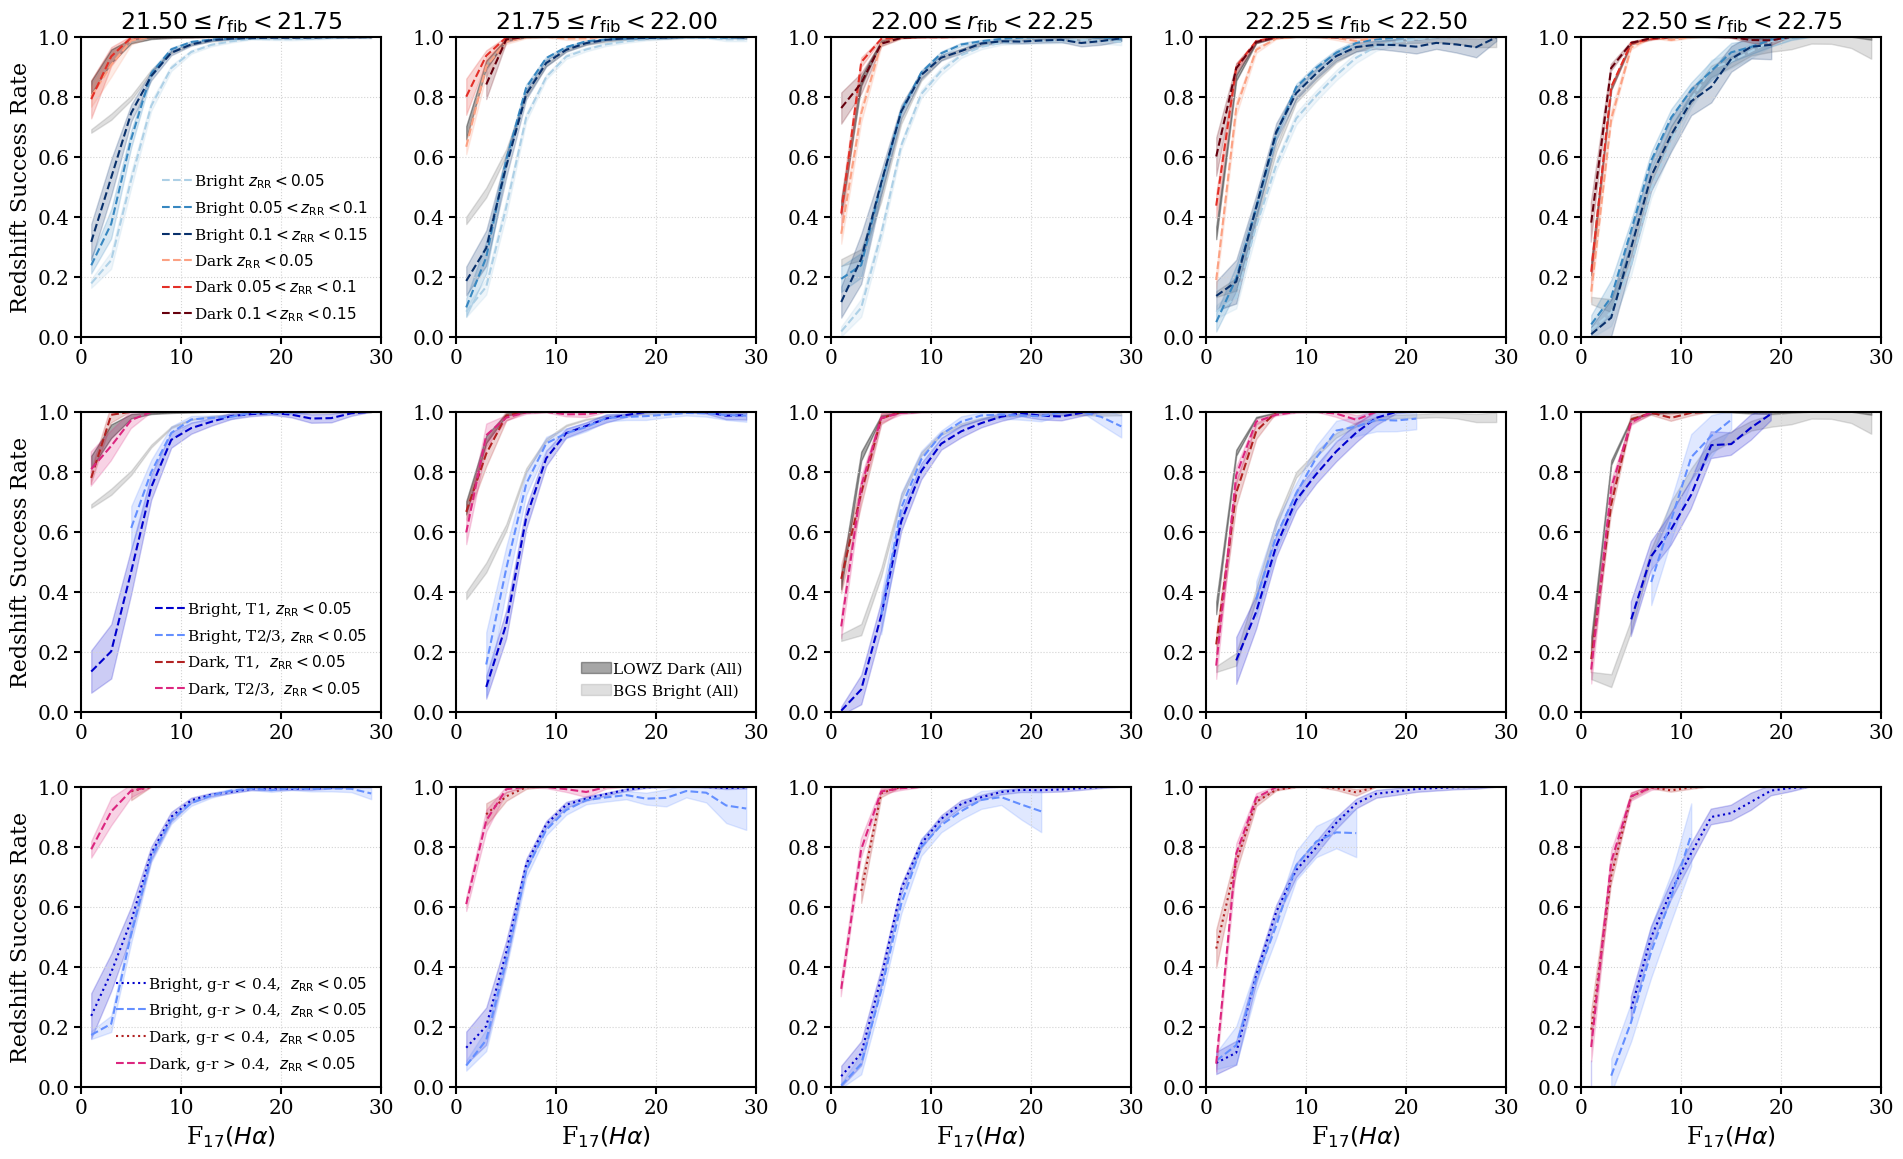

In [184]:
bgs_col = "#648FFF" #DC267F
lowz_col = "#DC267F"

# fig,all_ax = plt.subplots(2,6,figsize = (18,6),sharex=True,sharey=True)
all_ax = make_subplots(ncol = 5, nrow = 3,row_spacing = 0.75, col_spacing = 0.75)
all_ax = np.array(all_ax)
all_ax = all_ax.reshape((3,5))


all_alls = [zf_bgs1_ha_all,zf_bgs2_ha_all,zf_bgs3_ha_all]
all_errs = [zf_err_bgs1_ha_all,zf_err_bgs2_ha_all,zf_err_bgs3_ha_all]

all_lowz_alls = [zf_lowz1_ha_all,zf_lowz2_ha_all,zf_lowz3_ha_all]
all_lowz_errs = [zf_err_lowz1_ha_all,zf_err_lowz2_ha_all,zf_err_lowz3_ha_all]

all_row2_labels = [r"$z_{\rm RR} < 0.05$",r"$0.05 < z_{\rm RR} < 0.1$",r"$0.1 < z_{\rm RR} < 0.15$"]

# Choose a colormap (e.g., 'viridis')
cmap = plt.cm.Blues
colors_bright = cmap(np.linspace(0.33, 1, len(all_alls)))

cmap = plt.cm.Reds
colors_lowz = cmap(np.linspace(0.33, 1, len(all_alls)))

for index in range(5):
    ##plotting the all

    if index == 1:
        all_labels = ["LOWZ Dark (All)","BGS Bright (All)",None,None,None,None]
    if index == 0:
        all_labels = [None,None,r"Dark, T1,  $z_{\rm RR}<0.05$",r"Dark, T2/3,  $z_{\rm RR}<0.05$",r"Bright, T1, $z_{\rm RR}<0.05$",r"Bright, T2/3, $z_{\rm RR}<0.05$"]
    
    all_ax[2,index].set_title(r"$%.2f \leq r_{\rm fib} < %.2f$"%(rfib_cens[index]-0.125,rfib_cens[index]+0.125),size=17)
    
    
    all_ax[1,index].fill_between(ha_M[index,:], zf_lowz_ha_all[index,:] - zf_err_lowz_ha_all[index,:],zf_lowz_ha_all[index,:] + zf_err_lowz_ha_all[index,:],alpha = 0.35, color ="k", label = all_labels[0] )

    all_ax[1,index].fill_between(ha_M[index,:], zf_bgs_ha_all[index,:] - zf_err_bgs_ha_all[index,:],zf_bgs_ha_all[index,:] + zf_err_bgs_ha_all[index,:],alpha = 0.25, color = "grey",label =  all_labels[1])

    
    all_ax[1,index].plot(ha_M[index,:],zf_bgsB_ha_all_v2[index,:],color = "mediumblue",ls = "--", label =  all_labels[4])    
    all_ax[1,index].fill_between(ha_M[index,:], zf_bgsB_ha_all_v2[index,:] - zf_err_bgsB_ha_all_v2[index,:],zf_bgsB_ha_all_v2[index,:] + zf_err_bgsB_ha_all_v2[index,:],alpha = 0.2, color = "mediumblue"  )

    all_ax[1,index].plot(ha_M[index,:],zf_bgsR_ha_all_v2[index],color = bgs_col,ls = "--", label =  all_labels[5])    
    all_ax[1,index].fill_between(ha_M[index,:], zf_bgsR_ha_all_v2[index,:] - zf_err_bgsR_ha_all_v2[index,:],zf_bgsR_ha_all_v2[index,:] + zf_err_bgsR_ha_all_v2[index,:],alpha = 0.2, color = bgs_col  )

    
    all_ax[1,index].plot(ha_M[index,:],zf_lowzB_ha_all_v2[index,:],color = "firebrick",ls = "--", label =  all_labels[2])    
    all_ax[1,index].fill_between(ha_M[index,:], zf_lowzB_ha_all_v2[index,:] - zf_err_lowzB_ha_all_v2[index,:],zf_lowzB_ha_all_v2[index,:] + zf_err_lowzB_ha_all_v2[index,:],alpha = 0.2, color = "firebrick" )

    all_ax[1,index].plot(ha_M[index,:],zf_lowzR_ha_all_v2[index,:],color = lowz_col,ls = "--", label =  all_labels[3])    
    all_ax[1,index].fill_between(ha_M[index,:], zf_lowzR_ha_all_v2[index,:] - zf_err_lowzR_ha_all_v2[index,:],zf_lowzR_ha_all_v2[index,:] + zf_err_lowzR_ha_all_v2[index,:],alpha = 0.2, color = lowz_col  )


    ## SECOND ROW STUFF
    ##Bright redshift bins
    all_ax[2,index].fill_between(ha_M[index,:], zf_lowz_ha_all[index,:] - zf_err_lowz_ha_all[index,:],zf_lowz_ha_all[index,:] + zf_err_lowz_ha_all[index,:],alpha = 0.35, color ="k")
    all_ax[2,index].fill_between(ha_M[index,:], zf_bgs_ha_all[index,:] - zf_err_bgs_ha_all[index,:],zf_bgs_ha_all[index,:] + zf_err_bgs_ha_all[index,:],alpha = 0.25, color = "grey")

    for j in range(len(all_alls)):
        all_ax[2,index].plot(ha_M[index,:],all_alls[j][index,:],color = colors_bright[j],ls = "--", label = r"Bright " + all_row2_labels[j])
        all_ax[2,index].fill_between(ha_M[index,:], all_alls[j][index,:] - all_errs[j][index,:],all_alls[j][index,:] + all_errs[j][index,:],alpha = 0.2, color = colors_bright[j]  )

    ## Dark redshift bins
    for j in range(len(all_lowz_alls)):
        all_ax[2,index].plot(ha_M[index,:],all_lowz_alls[j][index,:],color = colors_lowz[j],ls = "--", label = r"Dark " + all_row2_labels[j])
        all_ax[2,index].fill_between(ha_M[index,:], all_lowz_alls[j][index,:] - all_lowz_errs[j][index,:],all_lowz_alls[j][index,:] + all_lowz_errs[j][index,:],alpha = 0.2, color = colors_lowz[j]  )

    
    
    if index in [0,1]:
        all_ax[1,index].legend(frameon=False, ncol = 1,fontsize = 11, loc = "lower right",markerscale = 1.5,
                            handletextpad = 0.1)
        
    all_ax[2,0].legend(frameon=False, ncol = 1,fontsize = 11, loc = "lower right",markerscale = 1.5,
                            handletextpad = 0.1)
    

    plt_between(all_ax[0, index], ha_M[index,:], zf_bgsBcol_ha_all_v2[index,:], zf_err_bgsBcol_ha_all_v2[index,:], 0.2, "mediumblue",ls="dotted",label = r"Bright, g-r < 0.4,  $z_{\rm RR}<0.05$")
    plt_between(all_ax[0, index], ha_M[index,:], zf_bgsRcol_ha_all_v2[index,:], zf_err_bgsRcol_ha_all_v2[index,:], 0.2, bgs_col,ls="--",label = r"Bright, g-r > 0.4,  $z_{\rm RR}<0.05$")

    plt_between(all_ax[0, index], ha_M[index,:], zf_lowzBcol_ha_all_v2[index,:], zf_err_lowzBcol_ha_all_v2[index,:], 0.2, "firebrick",ls="dotted",label = r"Dark, g-r < 0.4,  $z_{\rm RR}<0.05$")
    plt_between(all_ax[0, index], ha_M[index,:], zf_lowzRcol_ha_all_v2[index,:], zf_err_lowzRcol_ha_all_v2[index,:], 0.2, lowz_col,ls="--",label = r"Dark, g-r > 0.4,  $z_{\rm RR}<0.05$")


    all_ax[0,0].legend(frameon=False, ncol = 1,fontsize = 11, loc = "lower right",markerscale = 1.5,
                            handletextpad = 0.1)
        
    all_ax[0,index].set_xlabel(r"F$_{17}(H\alpha)$",fontsize = 17)
    
    
    for i in range(3):
        all_ax[i,index].set_xlim([0,30])
        all_ax[i,index].set_ylim([0,1])
        all_ax[i,index].grid(ls = ":",color ="lightgrey")
        
    
    
for i in range(3):
    all_ax[i,0].set_ylabel("Redshift Success Rate",fontsize = 16)

plt.savefig("paper_plots/zfail_group_split.pdf",bbox_inches="tight")

plt.show()


In [18]:

rfib_bins = np.arange(19,23.5,0.25)
ha_bins = np.arange(0,40,1) 

ha_cens = 0.5*(ha_bins[1:]+ha_bins[:-1])
rfib_cens = 0.5*(rfib_bins[1:]+rfib_bins[:-1])
ha_M,rfib_M = np.meshgrid(ha_cens,rfib_cens)

mc = 10

zfail_bgs_org, zfail_bgs_mean, zfail_bgs_std = get_zsucc_2d_vals(bgs_vac[bgs_vac["Z"] < 0.15], rfib_bins, ha_bins,color = "HALPHA_FLUX",fibmag="FIBERMAG_R",num_samp=50,min_count=mc,output_2d=True)

zfail_lowz_org, zfail_lowz_mean, zfail_lowz_std = get_zsucc_2d_vals(lowz_vac[lowz_vac["Z"] < 0.15], rfib_bins, ha_bins,color = "HALPHA_FLUX",fibmag="FIBERMAG_R",num_samp=50,min_count=mc,output_2d=True)



/tmp/ipykernel_253431/2120311485.py:122: RuntimeWarning: divide by zero encountered in true_divide
  sigma_errs = np.array(1/np.sqrt(lowz_all[color + "_IVAR"]))
/tmp/ipykernel_253431/2120311485.py:150: RuntimeWarning: Mean of empty slice
  zfail_mean = np.nanmean(all_zfail_stat,axis = 0)
/global/common/software/desi/perlmutter/desiconda/20230111-2.1.0/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_253431/2120311485.py:122: RuntimeWarning: divide by zero encountered in true_divide
  sigma_errs = np.array(1/np.sqrt(lowz_all[color + "_IVAR"]))
/tmp/ipykernel_253431/2120311485.py:150: RuntimeWarning: Mean of empty slice
  zfail_mean = np.nanmean(all_zfail_stat,axis = 0)
/global/common/software/desi/perlmutter/desiconda/20230111-2.1.0/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for s

In [19]:
rfib_M.shape

(17, 39)

In [20]:
# Flatten the meshgrid and the values
rfib_flat = rfib_M.flatten()
ha_flat = ha_M.flatten()
# zfail_bgs_flat = zfail_bgs_mean.flatten()
zfail_lowz_flat = zfail_lowz_mean.flatten()


In [21]:
len(rfib_bins)

18

In [68]:
from scipy.optimize import curve_fit
from scipy import special

def sigmoid_tanh(x, x0, k):
    return 1 / (1 + np.exp(-k * (x - x0)))

def sigmoid_tanha(x, x0, k, a):
    return a / (1 + np.exp(-k * (x - x0)))

def sigmoid_tanh_inv(x, x0, k,a):
    return a * (1 -  (1/ (1 + np.exp(-k * (x - x0)) )  ) )

def sigmoid_root(x, x0, k):
    return 0.5 +  ( (k*(x-x0)) /  (2*np.sqrt(1+(k*(x-x0))**2 ) ) )

def sigmoid_erf(x, x0, k):
    return 0.5 * ( 1 + special.erf((x-x0)/k) )


def sigmoid_erf_inv(x, x0, k,a):
    return a * (1 - 0.5 * ( 1 + special.erf((x-x0)/k) ) )

def get_sigmoid_fit(xdata, ydata,ydata_err, func = sigmoid_tanh, p0 =[21,4],bounds=None):
    # Initial guess for the parameters [x0, k]
    # Perform the curve fit
    popt, pcov = curve_fit(f=func, xdata=xdata,ydata = ydata,p0=p0 , bounds = bounds )
    return popt


def line(x,m,c):
    return m*x + c

def cubic(x,a,b,c,d):
    return a*x**3 + b*x**2 + c*x + d


def quad(x,a,b,c):
    return a*(x-b)**2 + c*x


def cont_line(x,c):
    return 0*x + c


def piecewise_linear_two_lines(x, x0, y0, m1, m2):
    """
    Compute a piecewise linear function with two segments, defined by a breakpoint and slopes.
    
    Parameters:
    x : np.ndarray or float
        Input x-coordinate(s).
    x_break : float
        X-coordinate of the breakpoint.
    y0 : float
        Y-intercept of the first segment (x < x_break).
    slope1 : float
        Slope of the first segment (x < x_break).
    y1 : float
        Y-intercept of the second segment (x >= x_break).
    slope2 : float
        Slope of the second segment (x >= x_break).
    
    Returns:
    np.ndarray or float
        The output y-coordinate(s) for the input x.
    """
     # Ensure x is a numpy array for vectorized operations
    x = np.array(x, dtype=float)
    
    # Calculate the intercepts
    c1 = y0 - m1*x0
    c2 = y0 - m2*x0
    
    # Compute y values for each segment
    y = np.where(x < x0,
                 m1 * x + c1,
                 m2 * x + c2)
    return y


Trying to fit the parametric function as a function of rfiber mag

36


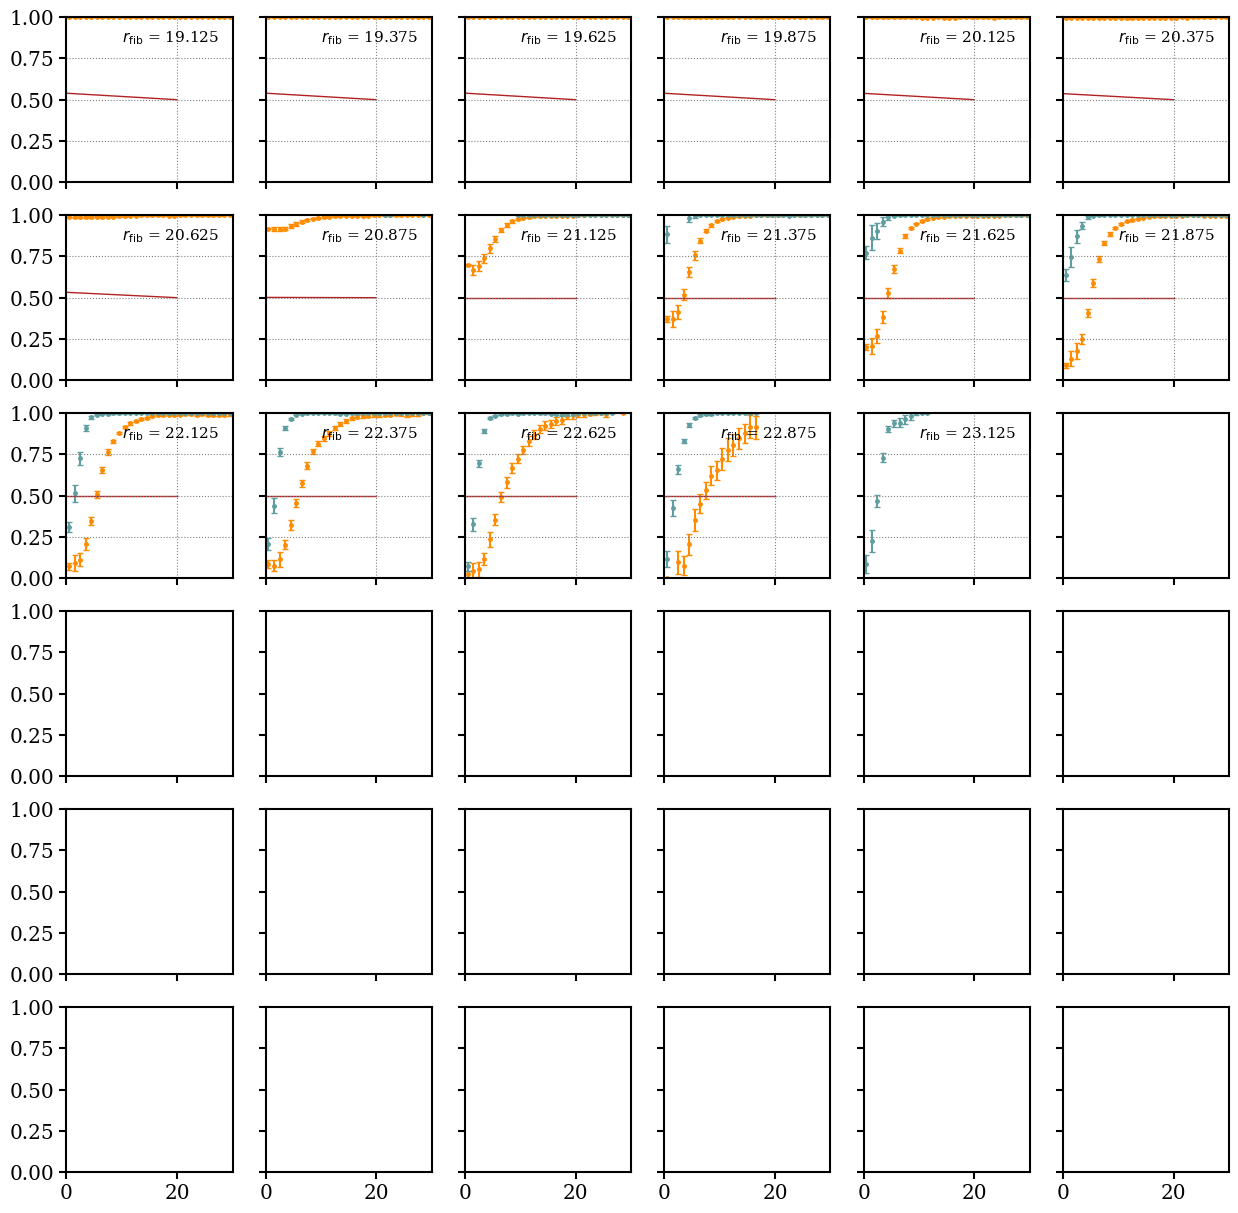

In [73]:
## now let us use our model!!

fig, ax = plt.subplots(6,6,figsize = (15,15),sharey=True,sharex=True)
axs = np.concatenate(ax)
print(len(axs))

all_x0s_lowz = []
all_ks_lowz = []
all_as_lowz = []
all_rfibs_lowz = []

all_x0s_bgs = []
all_ks_bgs = []
all_as_bgs = []
all_rfibs_bgs = []

for i in range(len(rfib_cens)):
    iax = i

    axs[iax].errorbar(ha_M[i,:], y=zfail_bgs_mean[i,:], yerr = zfail_bgs_std[i,:], color = "darkorange",capsize=2,ls="none",marker=".",markersize=5,zorder=0)

    axs[iax].errorbar(ha_M[i,:], y=zfail_lowz_mean[i,:], yerr = zfail_lowz_std[i,:], color = "cadetblue",capsize=2,ls="none",marker=".",markersize=5,zorder=0 )
    # axs[i].scatter(ha_M[i,:], zfail_lowz_mean[i,:], color = "cadetblue" )
    
    ## fit sigmoids ...
    
    #BGS fitting
    try:
        gmask = ~np.isnan(zfail_bgs_mean[i,:])
        popt_i, _  = curve_fit(f=sigmoid_tanh_inv, xdata=ha_M[i,:][gmask],ydata = zfail_bgs_mean[i,:][gmask],p0=[8,1,0.5],bounds=( (0,0,0),(20,20,1) ) )
        # print(popt_i)
        
        all_x0s_bgs.append(popt_i[0])
        all_ks_bgs.append(popt_i[1])
        all_as_bgs.append(popt_i[2])
        all_rfibs_bgs.append(rfib_cens[i])
        
        ha_grid = np.linspace(0,20,100)

        axs[iax].plot(ha_grid, sigmoid_tanh_inv(ha_grid, popt_i[0],popt_i[1],popt_i[2]), lw = 1,color = "firebrick",zorder=1 )
    except:
        pass


    
    #LOWZ fitting
    try:
        gmask = ~np.isnan(zfail_lowz_mean[i,:])
        
        
        a_fit = erf_a_dark_dchi25(rfib_cens[i])
        
        # popt_i, _  = curve_fit(f=sigmoid_tanh_inv, xdata=ha_M[i,:][gmask],ydata = zfail_lowz_mean[i,:][gmask],p0=[8,1,0.5],bounds=( (0,0,0),(20,20,1) ) )
        # popt_i, _  = curve_fit(f=sigmoid_tanha, xdata=ha_M[i,:][gmask],ydata = zfail_lowz_mean[i,:][gmask],p0=[8,1,0.5],bounds=( (0,0,0),(20,20,1) ) )
        
        popt_i, _  = curve_fit(f=sigmoid_tanha, xdata=ha_M[i,:][gmask],ydata = zfail_lowz_mean[i,:][gmask],p0=[8,1,0.5],bounds=( (0,0,a_fit - 0.01),(20,20,a_fit + 0.01) ) )
        
        # print(popt_i)
        
        all_x0s_lowz.append(popt_i[0])
        all_ks_lowz.append(popt_i[1])
        all_as_lowz.append(popt_i[2])
        all_rfibs_lowz.append(rfib_cens[i])
        
        ha_grid = np.linspace(0,20,100)

        # axs[iax].plot(ha_grid, sigmoid_tanh_inv(ha_grid, popt_i[0],popt_i[1],popt_i[2]), lw = 1,color = "mediumblue",zorder=1)
        axs[iax].plot(ha_grid, sigmoid_tanha(ha_grid, popt_i[0],popt_i[1],popt_i[2]), lw = 1,color = "mediumblue",zorder=1)
        
    except:
        pass

    
    
    axs[iax].grid(ls = ":",color = "grey")
        
    axs[iax].text(10,0.85,r"$r_{\rm fib}$ = %.3f"%rfib_cens[i],size=11)
    

for axi in axs:
    axi.set_xlim([0,30])
    axi.set_ylim([0,1])
    # axi.set_yscale("log")
    
    
plt.show()
    
all_rfibs_lowz = np.array(all_rfibs_lowz)
all_rfibs_bgs = np.array(all_rfibs_bgs)

all_as_lowz = np.array(all_as_lowz)
all_as_bgs = np.array(all_as_bgs)

all_x0s_lowz = np.array(all_x0s_lowz)
all_x0s_bgs = np.array(all_x0s_bgs)

all_ks_lowz = np.array(all_ks_lowz)
all_ks_bgs = np.array(all_ks_bgs)


In [178]:
# rfib_cens

In [25]:
def erf_x0_bright_dchi40(rfib):
    '''
    x0 parameter in sigmoid parametrization    
    
    bright [21.32855512  4.98790657 -2.52462029  3.65661779]
    dark [  1.02501322 -20.32833839]
    '''    
    params = [21.32855512,  4.98790657, -2.52462029,  3.65661779]
    all_x0s = piecewise_linear_two_lines(rfib, params[0], params[1], params[2], params[3] )
    return all_x0s

def erf_x0_dark_dchi40(rfib):
    '''
    x0 parameter in sigmoid parametrization    
    '''
    params = [1.02501322,  -20.32833839]
    all_x0s = params[0] * rfib + params[1] 
    return all_x0s

def erf_k_dark_dchi40(rfib):
    '''
    k parameter in sigmoid parametrization
    bright [21.03431337  0.68134887  0.90955823 -0.18031046]
    dark [-0.88822542 22.29855157  0.06208355]
    '''
    params = [-0.88822542, 22.29855157,  0.06208355]
    all_ks = quad(rfib, params[0], params[1], params[2])
    return np.maximum(all_ks,0.01)

def erf_k_bright_dchi40(rfib):
    '''
    function returns value of k. Input is halpha in units of 1e-17
    '''
    params = [21.03431337, 0.68134887,  0.90955823, -0.18031046]
    all_ks = piecewise_linear_two_lines(rfib, params[0], params[1], params[2], params[3] )
    return all_ks


def erf_a_dark_dchi40(rfib):
    '''
    a parameter in sigmoid parametrization  
    bright [21.06509115  6.79338176]
    dark [21.66482961  4.9797648 ]
    '''
    # params = [21.66482961,  4.9797648]
    params = [21.68437994,  5.50215296]
    all_as = sigmoid_tanh(rfib, params[0], params[1])
    return all_as

def erf_a_bright_dchi40(rfib):
    '''
    function returns value of a. Input is halpha in units of 1e-17
    '''
    params = [21.06509115,  6.79338176]
    
    all_as = sigmoid_tanh(rfib, params[0], params[1])
    return all_as


In [63]:
def erf_x0_bright_dchi25(rfib):
    '''
    x0 parameter in sigmoid parametrization    
    
    bright [ 1.88930748 21.66478978  0.22810742]
    dark [  0.64668376 -12.58144983]
    '''    
    params = [ 1.88930748, 21.66478978, 0.22810742]
    all_x0s = quad(rfib, params[0], params[1], params[2] )
    return all_x0s



def erf_x0_dark_dchi25(rfib):
    '''
    x0 parameter in sigmoid parametrization    
    '''
    params = [ 0.64668376,  -12.58144983]
    all_x0s = params[0] * rfib + params[1] 
    return all_x0s


#####################################

def erf_k_bright_dchi25(rfib):
    '''
    
    '''
    params = [21.1918879,  0.76453186,  0.89130006,  -0.23673844]
    all_ks = piecewise_linear_two_lines(rfib, params[0], params[1], params[2], params[3] )

    return np.maximum(all_ks,0.01)


def erf_k_dark_dchi25(rfib):
    '''
    k parameter in sigmoid parametrization
    bright [21.1918879   0.76453186  0.89130006 -0.23673844]
   k
    dark [22.31303592  1.49349551  1.05102452 -0.49664293]
    '''
    params =  [22.31303592,  1.49349551,  1.05102452, -0.49664293]
    all_ks = piecewise_linear_two_lines(rfib, params[0], params[1], params[2], params[3])
    return np.maximum(all_ks,0.01)


#####################################


def erf_a_bright_dchi25(rfib):
    '''
    bright [21.24500573  5.24242464]
    dark [21.88301147  5.32649399]
    '''
    params = [21.24500573,  5.24242464]
    
    all_as = sigmoid_tanh(rfib, params[0], params[1])
    return all_as


def erf_a_dark_dchi25(rfib):
    '''
    dark [21.67174256  2.84768896]
    '''
    # params = [21.67174256,  2.84768896]
    params = [21.88301147,  5.32649399]
    all_as = sigmoid_tanh(rfib, params[0], params[1])
    return all_as


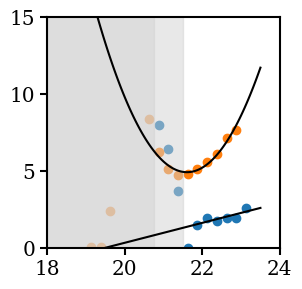

k


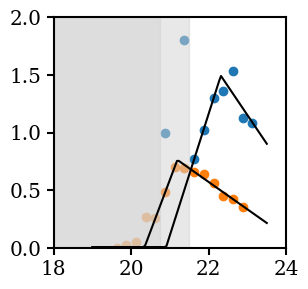

a
dark [21.88301147  5.32649399]


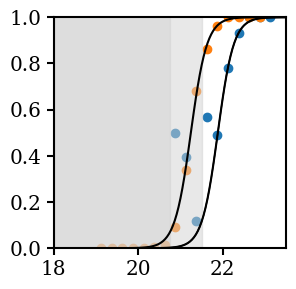

In [65]:
rfib_grid = np.linspace(19,23.5,100)
 
plt.figure(figsize = (3,3))
plt.scatter(all_rfibs_lowz, all_x0s_lowz)
plt.scatter(all_rfibs_bgs, all_x0s_bgs)
plt.xlim([18,24])
plt.fill_between(x = [18,20.75],y1=0,y2 = 20,color = "lightgrey",alpha = 0.5)
plt.fill_between(x = [18,21.5],y1=0,y2 = 20,color = "lightgrey",alpha = 0.5)

# print("X0")
# popt_i, _  = curve_fit(f=piecewise_linear_two_lines, xdata=all_rfibs_bgs[all_rfibs_bgs > 20.75],ydata = all_x0s_bgs[all_rfibs_bgs > 20.75],p0=[21,5,1,-1])
# ytemp = piecewise_linear_two_lines(rfib_grid, popt_i[0], popt_i[1], popt_i[2], popt_i[3] )
# plt.plot(rfib_grid, ytemp,color = "k")
# print("bright",popt_i)

# popt_i, _  = curve_fit(f=cubic, xdata=all_rfibs_bgs[all_rfibs_bgs > 20.5],ydata = all_x0s_bgs[all_rfibs_bgs > 20.5],p0=[21,5,1,-1])
# ytemp = cubic(rfib_grid, popt_i[0], popt_i[1], popt_i[2], popt_i[3])
# plt.plot(rfib_grid, ytemp,color = "k")
# print("bright",popt_i)

# print("X0")
# popt_i, _  = curve_fit(f=quad, xdata=all_rfibs_bgs[(all_rfibs_bgs > 20.75) & (all_rfibs_bgs < 24)],ydata = all_x0s_bgs[(all_rfibs_bgs > 20.75) & (all_rfibs_bgs < 24)],p0=[5,21.5,5])
# ytemp = quad(rfib_grid, popt_i[0], popt_i[1], popt_i[2] )
# plt.plot(rfib_grid, ytemp,color = "k")
# print("bright",popt_i)

# popt_i, _  = curve_fit(f=line, xdata=all_rfibs_lowz[all_rfibs_lowz > 21.75],ydata = all_x0s_lowz[all_rfibs_lowz > 21.75],p0=[1,1])
# print("dark",popt_i)
# plt.plot(rfib_grid, line(rfib_grid,popt_i[0], popt_i[1]) , color="k",lw = 1 )

plt.plot(rfib_grid, erf_x0_bright_dchi25(rfib_grid),color = "k" )
plt.plot(rfib_grid, erf_x0_dark_dchi25(rfib_grid),color = "k" )

plt.ylim([0,15])
plt.show()


#######
plt.figure(figsize = (3,3))
plt.scatter(all_rfibs_lowz, all_ks_lowz)
plt.scatter(all_rfibs_bgs, all_ks_bgs)
plt.xlim([18,24])
plt.fill_between(x = [18,20.75],y1=0,y2 = 20,color = "lightgrey",alpha = 0.5)
plt.fill_between(x = [18,21.5],y1=0,y2 = 20,color = "lightgrey",alpha = 0.5)

print("k")

# popt_i, _  = curve_fit(f=piecewise_linear_two_lines, xdata=all_rfibs_bgs[all_rfibs_bgs > 20.5],ydata = all_ks_bgs[all_rfibs_bgs > 20.5],p0=[21,6,-1,1])
# ytemp = piecewise_linear_two_lines(rfib_grid, popt_i[0], popt_i[1], popt_i[2], popt_i[3] )
# plt.plot(rfib_grid, ytemp,color = "k")
# print("bright",popt_i)


# popt_i, _  = curve_fit(f=piecewise_linear_two_lines, xdata=all_rfibs_lowz[all_rfibs_lowz > 21.5],ydata = all_ks_lowz[all_rfibs_lowz > 21.5],p0=[22.25,1.5,2,-2])
# ytemp = piecewise_linear_two_lines(rfib_grid, popt_i[0], popt_i[1], popt_i[2], popt_i[3] )
# print("dark",popt_i)
# plt.plot(rfib_grid, ytemp,color = "k")


# popt_i, _  = curve_fit(f=quad, xdata=all_rfibs_lowz[all_rfibs_lowz > 21.5],ydata = all_ks_lowz[all_rfibs_lowz > 21.5],p0=[-5,22.2,1.5])
# ytemp = quad(rfib_grid, popt_i[0], popt_i[1], popt_i[2] )
# print("dark",popt_i)
# plt.plot(rfib_grid, ytemp,color = "k")

plt.plot(rfib_grid, erf_k_bright_dchi25(rfib_grid),color = "k" )
plt.plot(rfib_grid, erf_k_dark_dchi25(rfib_grid),color = "k" )

plt.ylim([0,2])
plt.show()


#######
plt.figure(figsize = (3,3))
plt.scatter(all_rfibs_lowz, all_as_lowz)
plt.scatter(all_rfibs_bgs, all_as_bgs)
plt.xlim([18,23.5])
plt.fill_between(x = [18,20.75],y1=0,y2 = 20,color = "lightgrey",alpha = 0.5)
plt.fill_between(x = [18,21.5],y1=0,y2 = 20,color = "lightgrey",alpha = 0.5)
plt.ylim([0,1])

print("a")

# popt_i, _  = curve_fit(f = sigmoid_tanh, xdata = all_rfibs_bgs[all_rfibs_bgs > 20.9375] , ydata = all_as_bgs[all_rfibs_bgs > 20.9375] , p0=[21,1] )
# rfib_grid = np.linspace(19,23.5,100)
# plt.plot(rfib_grid, sigmoid_tanh(rfib_grid, popt_i[0], popt_i[1]) , color="k",lw = 1 )
# print("bright",popt_i)

# # ##

popt_i, _  = curve_fit(f=sigmoid_tanh, xdata=all_rfibs_lowz[all_rfibs_lowz > 21.75],ydata = all_as_lowz[all_rfibs_lowz > 21.75],p0=[21,1])
rfib_grid = np.linspace(19,23.5,100)
plt.plot(rfib_grid, sigmoid_tanh(rfib_grid, popt_i[0], popt_i[1]) , color="k",lw = 1 )
print("dark",popt_i)

# plt.plot(rfib_grid, sigmoid_tanh(rfib_grid, popt_i[0], popt_i[1]), color = "k" )
plt.plot(rfib_grid, erf_a_bright_dchi25(rfib_grid),color = "k" )
plt.plot(rfib_grid, erf_a_dark_dchi25(rfib_grid),color = "k" )


plt.show()



In [181]:

rfib_bins_mod = np.arange(19,23.5,0.25)
ha_bins_mod = np.arange(0,40,1) 

ha_cens_mod = 0.5*(ha_bins_mod[1:]+ha_bins_mod[:-1])
rfib_cens_mod = 0.5*(rfib_bins_mod[1:]+rfib_bins_mod[:-1])
ha_M_mod,rfib_M_mod = np.meshgrid(ha_cens_mod,rfib_cens_mod)

mc = 10
zfail_bgs_org, zfail_bgs_mean, zfail_bgs_std = get_zsucc_2d_vals(bgs_vac[bgs_vac["Z"] < 0.15], rfib_bins_mod, ha_bins_mod,color = "HALPHA_FLUX",fibmag="FIBERMAG_R",num_samp=50,min_count=mc,output_2d=True)
zfail_lowz_org, zfail_lowz_mean, zfail_lowz_std = get_zsucc_2d_vals(lowz_vac[lowz_vac["Z"] < 0.15], rfib_bins_mod, ha_bins_mod,color = "HALPHA_FLUX",fibmag="FIBERMAG_R",num_samp=50,min_count=mc,output_2d=True)

/tmp/ipykernel_253431/2120311485.py:122: RuntimeWarning: divide by zero encountered in true_divide
  sigma_errs = np.array(1/np.sqrt(lowz_all[color + "_IVAR"]))
/tmp/ipykernel_253431/2120311485.py:150: RuntimeWarning: Mean of empty slice
  zfail_mean = np.nanmean(all_zfail_stat,axis = 0)
/global/common/software/desi/perlmutter/desiconda/20230111-2.1.0/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_253431/2120311485.py:122: RuntimeWarning: divide by zero encountered in true_divide
  sigma_errs = np.array(1/np.sqrt(lowz_all[color + "_IVAR"]))
/tmp/ipykernel_253431/2120311485.py:150: RuntimeWarning: Mean of empty slice
  zfail_mean = np.nanmean(all_zfail_stat,axis = 0)
/global/common/software/desi/perlmutter/desiconda/20230111-2.1.0/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for s

/global/common/software/desi/perlmutter/desiconda/20230111-2.1.0/conda/lib/python3.10/site-packages/matplotlib/axes/_base.py:2539: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


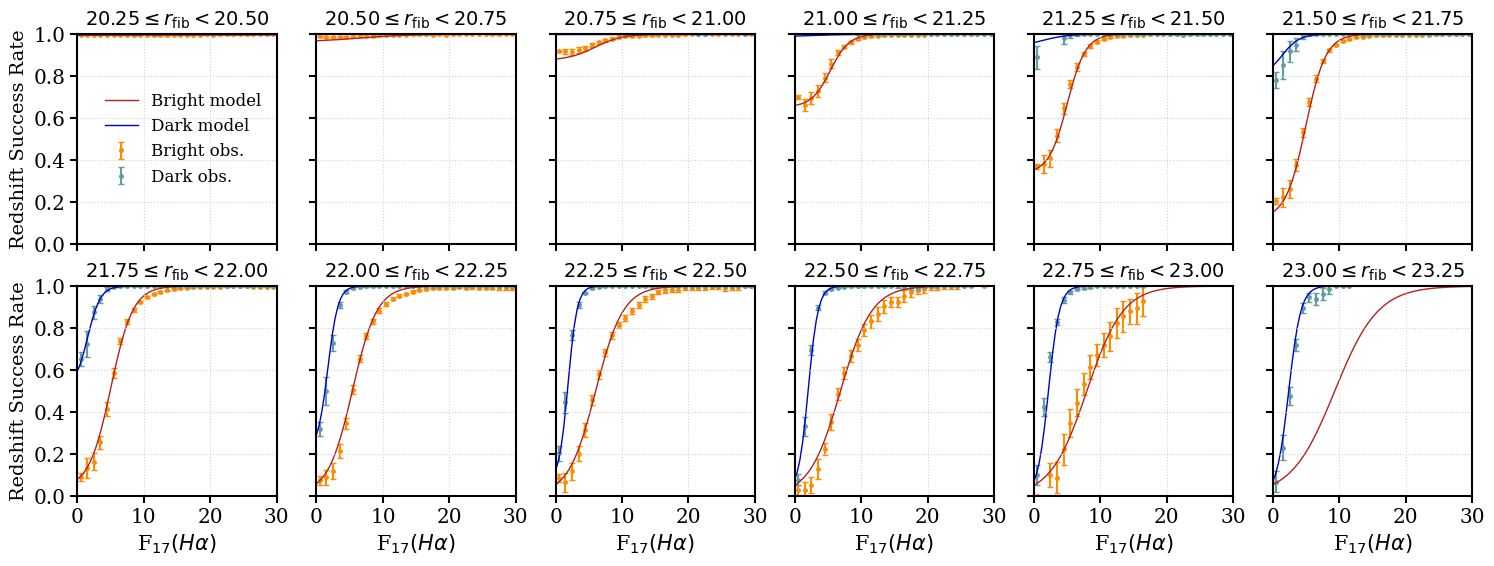

In [182]:
## now let us use our model!!

fig, ax = plt.subplots(2,6,figsize = (18,6),sharey=True,sharex=True)
axs = np.concatenate(ax)

ha_grid = np.linspace(0,40,100)
for iax in range(12):
    i = iax + 5

    axs[iax].errorbar(ha_M_mod[i,:], y=zfail_bgs_mean[i,:], yerr = zfail_bgs_std[i,:], color = "darkorange",capsize=2,ls="none",marker=".",markersize=5,zorder=0,label = "Bright obs.")

    axs[iax].errorbar(ha_M_mod[i,:], y=zfail_lowz_mean[i,:], yerr = zfail_lowz_std[i,:], color = "cadetblue",capsize=2,ls="none",marker=".",markersize=5,zorder=0,label = "Dark obs." )
    # axs[i].scatter(ha_M[i,:], zfail_lowz_mean[i,:], color = "cadetblue" )
    
    ## fit sigmoids ...
    dark_model = [erf_x0_dark_dchi25(rfib_cens_mod[i]) ,erf_k_dark_dchi25(rfib_cens_mod[i]),erf_a_dark_dchi25(rfib_cens_mod[i]) ]
    bright_model = [erf_x0_bright_dchi25(rfib_cens_mod[i]) ,erf_k_bright_dchi25(rfib_cens_mod[i]) ,erf_a_bright_dchi25(rfib_cens_mod[i]) ]
    
    axs[iax].plot(ha_grid,  1 - sigmoid_tanh_inv(ha_grid, bright_model[0], bright_model[1], bright_model[2]), lw = 1,color = "firebrick",zorder=1, label = "Bright model")
    axs[iax].plot(ha_grid, 1 - sigmoid_tanh_inv(ha_grid, dark_model[0], dark_model[1], dark_model[2]), lw = 1,color = "mediumblue",zorder=1 , label = "Dark model")

    if iax == 0:
        axs[iax].legend(frameon=False,loc="center right",fontsize = 12)
    
    axs[iax].grid(ls = ":",color = "lightgrey")
        
    axs[iax].set_title(r"$%.2f \leq r_{\rm fib} < %.2f$"%(rfib_cens_mod[i]-0.125,rfib_cens_mod[i]+0.125),size=14)
    
    
        
axs[0].set_ylabel("Redshift Success Rate",fontsize = 14)
axs[6].set_ylabel("Redshift Success Rate",fontsize = 14)

# axs[0].text(7.5,0.1,r"$\Delta\chi^2 > 25$",fontsize = 15)

for i in range(6,12):
    axs[i].set_xlabel(r"F$_{17}(H\alpha)$",fontsize = 15)

for axi in axs:
    axi.set_xlim([0,30])
    axi.set_ylim([0,1])
    axi.set_xticks([0,10,20,30])
    
# plt.savefig("paper_plots/zfail_model_fits.pdf",bbox_inches="tight")

plt.show()
    

In [184]:
# ## storing all the fit info
# all_x0s = []
# all_ks = []
# all_as = []
# all_has = []

# for i in range(len(ha_cens)):
#     print(ha_cens[i])
#     plt.figure(figsize = (4,4))
    
#     plt.errorbar(rfib_M[:,i], y=zfail_bgs_mean[:,i], yerr = zfail_bgs_std[:,i], color = "darkorange",capsize=4,ls="none",marker=".",markersize=7.5 )
#     # plt.plot(rfib_M[:,i],zfail_bgs_org[:,i],color = "grey")
    
#     plt.errorbar(rfib_M[:,i], y=zfail_lowz_mean[:,i], yerr = zfail_lowz_std[:,i], color = "cadetblue",capsize=4,ls="none",marker=".",markersize=7.5 )
#     # plt.plot(rfib_M[:,i],zfail_lowz_org[:,i],color = "grey")
        
#     #BGS fitting
#     gmask = ~np.isnan(zfail_bgs_mean[:,i])
    
#     x0_i,k_i = get_sigmoid_fit(rfib_M[:,i][gmask], zfail_bgs_mean[:,i][gmask],zfail_bgs_std[:,i][gmask],func=sigmoid_erf, plot=False)
    
# #     all_x0s.append(x0_i)
# #     all_ks.append(k_i)
# #     all_has.append(ha_cens[i])
    
#     rfib_grid = np.linspace(19,23.5,100)

#     plt.plot(rfib_grid, sigmoid_erf(rfib_grid, x0_i, k_i), lw = 1,color = "r" )
#     plt.grid(ls = ":",color = "grey")
        
#     gmask_L = ~np.isnan(zfail_lowz_mean[:,i])
    
    
#     ## running the fixed analysis
#     x0_fix = float(erf_x0_dark(np.array([ha_cens[i]])))
    
#     def sigmoid_erf_fix(x, k):
#         return 0.5 * ( 1 + special.erf((x-x0_fix)/k) )
    
#     popt, pcov = curve_fit(f=sigmoid_erf_fix, xdata= rfib_M[:,i][gmask_L] ,ydata = zfail_lowz_mean[:,i][gmask_L] , p0=[1])
#     k_L = popt[0]
#     print(x0_fix, k_L)
#     plt.plot(rfib_grid, sigmoid_erf_fix(rfib_grid, k_L), lw = 1,color = "blue" )
    
    
#     ## running both parameters free ...
#     x0_L,k_L = get_sigmoid_fit(rfib_M[:,i][gmask_L], zfail_lowz_mean[:,i][gmask_L],zfail_lowz_std[:,i][gmask_L],func=sigmoid_erf, plot=False)
#     plt.plot(rfib_grid, sigmoid_erf(rfib_grid, x0_L, k_L), lw = 1,color = "mediumblue",ls = "dotted" )
#     print(x0_L,k_L)
#     all_x0s.append(x0_L)
#     all_ks.append(k_L)
#     all_has.append(ha_cens[i])
    
#     plt.xlim([19,23.5])
#     plt.ylim([0,1])
#     plt.show()
    
    
# all_has = np.array(all_has)
# all_ks = np.array(all_ks)
# all_x0s = np.array(all_x0s)


In [509]:
all_x0s[0]

21.73035269473028

In [166]:
# ## now let us use our model!!

# fig, ax = plt.subplots(4,5,figsize = (15,12),sharey=True,sharex=True)
# axs = np.concatenate(ax)

# for i in range(len(ha_cens)):

#     axs[i].errorbar(rfib_M[:,i], y=zfail_bgs_mean[:,i], yerr = zfail_bgs_std[:,i], color = "darkorange",capsize=4,ls="none",marker=".",markersize=7.5 )
    
#     axs[i].errorbar(rfib_M[:,i], y=zfail_lowz_mean[:,i], yerr = zfail_lowz_std[:,i], color = "cadetblue",capsize=4,ls="none",marker=".",markersize=7.5 )
    
#     rfib_grid = np.linspace(19,23.5,100)
#     ha_cen_i = np.array([ha_cens[i]])
    
#     erf_ki = erf_k_bright(ha_cen_i)
#     erf_x0i = erf_x0_bright(ha_cen_i)
    
#     axs[i].plot(rfib_grid, sigmoid_erf(rfib_grid, erf_x0i, erf_ki), lw = 1,color = "r" )

#     axs[i].grid(ls = ":",color = "grey")
        
#     axs[i].text(19.2,0.85,r"F(H$\alpha$) = %.1f"%ha_cen_i,size=10)
    
    
# #     gmask_L = ~np.isnan(zfail_lowz_mean[:,i])
# #     x0_L,k_L = get_sigmoid_fit(rfib_M[:,i][gmask_L], zfail_lowz_mean[:,i][gmask_L],zfail_lowz_std[:,i][gmask_L],func=sigmoid_erf, plot=False)
    
#     erf_x0i_dark = erf_x0_dark(ha_cen_i)
#     erf_ki_dark = erf_k_dark(ha_cen_i)
    
    
#     axs[i].plot(rfib_grid, sigmoid_erf(rfib_grid, erf_x0i_dark,erf_ki_dark), lw = 1,color = "mediumblue" )
#     axs[i].plot(rfib_grid, sigmoid_erf(rfib_grid, all_x0s[i],all_ks[i]), lw = 1,color = "darkblue",ls="dotted" )

# for axi in axs:
#     axi.set_xlim([19,23.5])
#     axi.set_ylim([0,1])
# plt.show()
    


In [ ]:
# ha_cens_mod = 0.5*(ha_bins_mod[1:]+ha_bins_mod[:-1])
# rfib_cens_mod = 0.5*(rfib_bins_mod[1:]+rfib_bins_mod[:-1])
# ha_M_mod,rfib_M_mod = np.meshgrid(ha_cens_mod,rfib_cens_mod)

# mc = 10
# zfail_bgs_org, zfail_bgs_mean, zfail_bgs_std = get_zsucc_2d_vals(bgs_vac[bgs_vac["Z"] < 0.15], rfib_bins_mod, ha_bins_mod,color = "HALPHA_FLUX",fibmag="FIBERMAG_R",num_samp=50,min_count=mc,output_2d=True)
# zfail_lowz_org, zfail_lowz_mean, zfail_lowz_std = get_

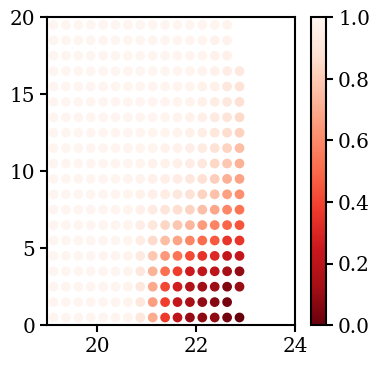

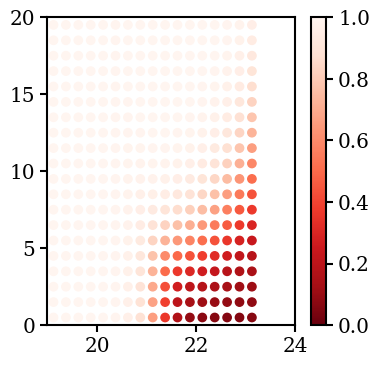

/tmp/ipykernel_253431/1619781513.py:36: RuntimeWarning: divide by zero encountered in true_divide
  plt.scatter(rfib_flat, ha_flat,c = (zsucc_mods - zfail_bgs_flat)/(zfail_bgs_flat),vmin=-3,vmax=3,cmap = "PiYG")


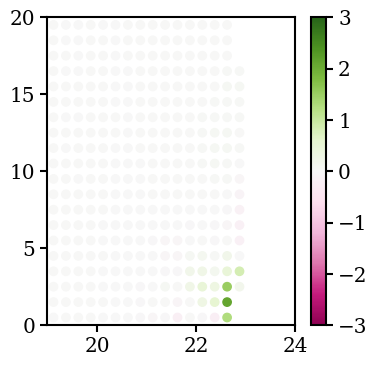

In [186]:
## this is the data


rfib_flat = np.concatenate(rfib_M_mod)
ha_flat = np.concatenate(ha_M_mod)
zfail_bgs_flat = np.concatenate(zfail_bgs_mean)
zfail_bgs_std_flat = np.concatenate(zfail_bgs_std)


plt.figure(figsize = (4,4))
plt.scatter(rfib_flat, ha_flat,c = zfail_bgs_flat,vmin=0,vmax=1,cmap = "Reds_r")
plt.colorbar()
plt.xlim([19,24])
plt.ylim([0,20])
plt.show()

## this is the model

xmods = erf_x0_bright_dchi25(rfib_flat)
kmods = erf_k_bright_dchi25(rfib_flat)
amods = erf_a_bright_dchi25(rfib_flat)

zsucc_mods = 1 - sigmoid_tanh_inv(ha_flat, xmods, kmods, amods)

plt.figure(figsize = (4,4))
plt.scatter(rfib_flat, ha_flat,c = zsucc_mods,vmin=0,vmax=1,cmap = "Reds_r")
plt.colorbar()
plt.xlim([19,24])
plt.ylim([0,20])
plt.show()


###

plt.figure(figsize = (4,4))
plt.scatter(rfib_flat, ha_flat,c = (zsucc_mods - zfail_bgs_flat)/(zfail_bgs_flat),vmin=-3,vmax=3,cmap = "PiYG")
plt.colorbar()
plt.xlim([19,24])
plt.ylim([0,20])
plt.show()

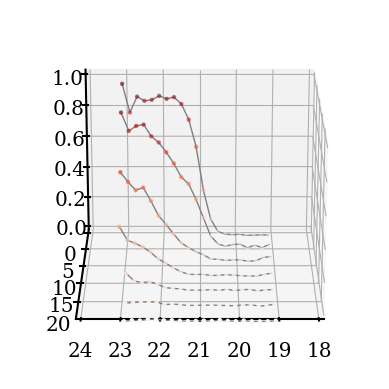

In [732]:
# %matplotlib inline
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter3D(X_flat, Y_flat,Z_flat, c=Z_flat,cmap = "Reds",s=5)

for i in range(len(ha_cens)):
    ax.plot(rfib_M[:,i], ha_M[:,i], zfail_mean[:,i],color = "grey",lw = 1)

ax.set_xlim(18, 24); ax.set_ylim(-0.5, 24); ax.set_zlim(0, 1.01);
ax.view_init(20,90)
plt.show()


In [20]:
## bin in redshift, rfiber-mag and redshift failure rate space. Then to confirm, split by color etc. and then

We make a 3d dimensional plot of this to begin to understand some of the trends...

Our main

In [ ]:
## trying something like the logistiic regresio modelm 

In [395]:
# import numpy as np
# from sklearn.linear_model import LogisticRegression
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D

# # Example data
# np.random.seed(0)
# x_data = np.random.rand(500) * 10 - 5  # Random x values
# y_data = np.random.rand(500) * 10 - 5  # Random y values
# # Example binary outcomes (0 or 1)
# z_data = (x_data**3 + y_data > 0).astype(int)  # For demonstration,

# Part 2) Understanding purity and completeness as a function of $\Delta\chi^2$, rfib and Halpha flux

For BGS Bright there already exists a reference catalog of deeper exposure/truth redshifts from BGS SV. For LOWZ, I might use the SAGA DR3 full catalog? There could be other catalogs to look at like in COSMOS field  

I also am running spectral simulations to have more statistics and to see if I can quantify these

In [4]:
## read SV3 data from Changhoon Hahn
dat_dir = '/global/cfs/cdirs/desi/users/chahah/bgs-cmxsv/sv-paper'

sv3_gals = Table.read(os.path.join(dat_dir, 'sv3.bgs_exps.efftime160_200.zsuccess.fuji.fits'))
sv3_gals.remove_columns(["SUBTYPE", "REF_CAT"])

from astropy.table import Table, unique
# sv3_gals = unique(sv3_gals)  

# print(len(sv3_gals))
_,inds,cts = np.unique(sv3_gals["TARGETID"],return_index=True,return_counts=True)
# ##there were a lot of repeat observations in the SV3 data file ...
sv3_gals = sv3_gals[inds]

print(len(sv3_gals))


71636


In [5]:

## let us clean the SV3 catalog using our cleaning cuts so we are not dealing with spurious sources
## this will help us in the lowz-redshift case ..

vacdir = '/global/cfs/cdirs/desi/public/edr/vac/edr/lsdr9-photometry/fuji/v2.1/observed-targets'
def read_tractorphot(zcat, verbose=False):
    from glob import glob
    from desimodel.footprint import radec2pix

    tractorphotfiles = glob(os.path.join(vacdir, 'tractorphot', 'tractorphot-nside4-hp???-fuji.fits'))
    
    hdr = fitsio.read_header(tractorphotfiles[0], 'TRACTORPHOT')
    tractorphot_nside = hdr['FILENSID']

    tot_len = len(zcat)
    tot_sofar = 0
    
    pixels = radec2pix(tractorphot_nside, zcat['TARGET_RA'], zcat['TARGET_DEC'])
    # pixels = radec2pix(tractorphot_nside, zcat['RA'], zcat['DEC'])
    
    phot = []
    for pixel in set(pixels):
        J = pixel == pixels
        photfile = os.path.join(vacdir, 'tractorphot', 'tractorphot-nside4-hp{:03d}-fuji.fits'.format(pixel))
        targetids = fitsio.read(photfile, columns='TARGETID')
        K = np.where(np.isin(targetids, zcat['TARGETID'][J]))[0]
        
        tot_sofar += len(K)
        
        if verbose:
            # print('Reading photometry for {} objects from {}'.format(len(K), photfile))
            print("%.2f percent done!"%(100*tot_sofar/tot_len))
         
        _phot = fitsio.read(photfile, rows=K)
        phot.append(Table(_phot))
    phot = vstack(phot)

    # Is there a better way to sort here??
    # srt = np.hstack([np.where(tid == phot['TARGETID'])[0] for tid in trange(zcat['TARGETID'])]) 
    # phot = phot[srt]
    ## I will just match by RA, Dec later
    
    #matching the two catalogs now so we have a 1-1 comparison
    catalog = SkyCoord(ra=np.array(phot["RA"])*u.degree, dec=np.array(phot["DEC"])*u.degree)
    c = SkyCoord(ra=np.array(zcat["TARGET_RA"])*u.degree, dec=np.array(zcat["TARGET_DEC"])*u.degree)
    idx, d2d, d3d = c.match_to_catalog_sky(catalog)
    
    return phot[idx]

zpix_sv3 = read_tractorphot(sv3_gals, verbose=True)

from desi_lowz_funcs import get_useful_cat_colms, get_remove_flag, _n_or_more_lt
#read the tractor phot catalogs
zpix_sv3 = get_useful_cat_colms(zpix_sv3)

allmask_grz = [f"ALLMASK_{b}" for b in "GRZ"]
sigma_grz = [f"SIGMA_GOOD_{b}" for b in "GRZ"]
sigma_wise = [f"SIGMA_GOOD_W{b}" for b in range(1, 5)]
fracflux_grz = [f"FRACFLUX_{b}" for b in "GRZ"]
rchisq_grz = [f"RCHISQ_{b}" for b in "GRZ"]

fracmasked_grz = [f"FRACMASKED_{b}" for b in "GRZ"]

remove_queries = [
"(MASKBITS >> 1) % 2 > 0",  # 1
"(MASKBITS >> 5) % 2 > 0",  # 2
"(MASKBITS >> 6) % 2 > 0",  # 3
"(MASKBITS >> 7) % 2 > 0",  # 4
"(MASKBITS >> 12) % 2 > 0",  # 5
"(MASKBITS >> 13) % 2 > 0",  # 6
_n_or_more_lt(sigma_grz, 2, 5),  # 7
"FRACFLUX_G > 0.7",
"FRACFLUX_R > 0.7",
"FRACFLUX_Z > 0.7"
]

# Query(_n_or_more_gt(fracflux_grz, 1, 0.7)),  # 8

mask = get_remove_flag(zpix_sv3, remove_queries) == 0
mask2 = (zpix_sv3["is_galaxy"] == True)
tot_mask = mask&mask2

### this is the mask that will keep good objects and remove bad

sv3_gals = sv3_gals[tot_mask]
zpix_sv3 = zpix_sv3[tot_mask]

print(len(sv3_gals))




3.17 percent done!
8.79 percent done!
9.09 percent done!
16.91 percent done!
29.51 percent done!
34.85 percent done!
39.66 percent done!
44.59 percent done!
46.49 percent done!
48.67 percent done!
48.86 percent done!
54.04 percent done!
54.36 percent done!
55.04 percent done!
81.62 percent done!
91.75 percent done!
93.00 percent done!
93.51 percent done!
95.53 percent done!
95.95 percent done!
100.00 percent done!
69031


In [6]:
zpix_sv3[:3]

RELEASE,BRICKID,BRICKNAME,OBJID,BRICK_PRIMARY,MASKBITS,FITBITS,TYPE,RA,DEC,RA_IVAR,DEC_IVAR,BX,BY,DCHISQ,EBV,MJD_MIN,MJD_MAX,REF_CAT,REF_ID,PMRA,PMDEC,PARALLAX,PMRA_IVAR,PMDEC_IVAR,PARALLAX_IVAR,REF_EPOCH,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_G_MEAN_FLUX_OVER_ERROR,GAIA_PHOT_G_N_OBS,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_BP_MEAN_FLUX_OVER_ERROR,GAIA_PHOT_BP_N_OBS,GAIA_PHOT_RP_MEAN_MAG,GAIA_PHOT_RP_MEAN_FLUX_OVER_ERROR,GAIA_PHOT_RP_N_OBS,GAIA_PHOT_VARIABLE_FLAG,GAIA_ASTROMETRIC_EXCESS_NOISE,GAIA_ASTROMETRIC_EXCESS_NOISE_SIG,GAIA_ASTROMETRIC_N_OBS_AL,GAIA_ASTROMETRIC_N_GOOD_OBS_AL,GAIA_ASTROMETRIC_WEIGHT_AL,GAIA_DUPLICATED_SOURCE,GAIA_A_G_VAL,GAIA_E_BP_MIN_RP_VAL,GAIA_PHOT_BP_RP_EXCESS_FACTOR,GAIA_ASTROMETRIC_SIGMA5D_MAX,GAIA_ASTROMETRIC_PARAMS_SOLVED,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_W3,FLUX_W4,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FLUX_IVAR_W3,FLUX_IVAR_W4,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,APFLUX_G,APFLUX_R,APFLUX_Z,APFLUX_RESID_G,APFLUX_RESID_R,APFLUX_RESID_Z,APFLUX_BLOBRESID_G,APFLUX_BLOBRESID_R,APFLUX_BLOBRESID_Z,APFLUX_IVAR_G,APFLUX_IVAR_R,APFLUX_IVAR_Z,APFLUX_MASKED_G,APFLUX_MASKED_R,APFLUX_MASKED_Z,APFLUX_W1,APFLUX_W2,APFLUX_W3,APFLUX_W4,APFLUX_RESID_W1,APFLUX_RESID_W2,APFLUX_RESID_W3,APFLUX_RESID_W4,APFLUX_IVAR_W1,APFLUX_IVAR_W2,APFLUX_IVAR_W3,APFLUX_IVAR_W4,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,MW_TRANSMISSION_W3,MW_TRANSMISSION_W4,NOBS_G,NOBS_R,NOBS_Z,NOBS_W1,NOBS_W2,NOBS_W3,NOBS_W4,RCHISQ_G,RCHISQ_R,RCHISQ_Z,RCHISQ_W1,RCHISQ_W2,RCHISQ_W3,RCHISQ_W4,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACFLUX_W1,FRACFLUX_W2,FRACFLUX_W3,FRACFLUX_W4,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,ANYMASK_G,ANYMASK_R,ANYMASK_Z,ALLMASK_G,ALLMASK_R,ALLMASK_Z,WISEMASK_W1,WISEMASK_W2,PSFSIZE_G,PSFSIZE_R,PSFSIZE_Z,PSFDEPTH_G,PSFDEPTH_R,PSFDEPTH_Z,GALDEPTH_G,GALDEPTH_R,GALDEPTH_Z,NEA_G,NEA_R,NEA_Z,BLOB_NEA_G,BLOB_NEA_R,BLOB_NEA_Z,PSFDEPTH_W1,PSFDEPTH_W2,PSFDEPTH_W3,PSFDEPTH_W4,WISE_COADD_ID,WISE_X,WISE_Y,LC_FLUX_W1,LC_FLUX_W2,LC_FLUX_IVAR_W1,LC_FLUX_IVAR_W2,LC_NOBS_W1,LC_NOBS_W2,LC_FRACFLUX_W1,LC_FRACFLUX_W2,LC_RCHISQ_W1,LC_RCHISQ_W2,LC_MJD_W1,LC_MJD_W2,LC_EPOCH_INDEX_W1,LC_EPOCH_INDEX_W2,SERSIC,SERSIC_IVAR,SHAPE_R,SHAPE_R_IVAR,SHAPE_E1,SHAPE_E1_IVAR,SHAPE_E2,SHAPE_E2_IVAR,LS_ID,TARGETID,is_galaxy,SIGMA_G,SIGMA_GOOD_G,SIGMA_R,SIGMA_GOOD_R,SIGMA_Z,SIGMA_GOOD_Z,g_mag,r_mag
int16,int32,str8,int32,bool,int16,int16,str3,float64,float64,float32,float32,float32,float32,float32[5],float32,float64,float64,str2,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,int16,float32,float32,int16,bool,float32,float32,int16,int16,float32,bool,float32,float32,float32,float32,uint8,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32[8],float32[8],float32[8],float32[8],float32[8],float32[8],float32[8],float32[8],float32[8],float32[8],float32[8],float32[8],float32[8],float32[8],float32[8],float32[5],float32[5],float32[5],float32[5],float32[5],float32[5],float32[5],float32[5],float32[5],float32[5],float32[5],float32[5],float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,int16,int16,uint8,uint8,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,str8,float32,float32,float32[15],float32[15],float32[15],float32[15],int16[15],int16[15],float32[15],float32[15],float32[15],float32[15],float64[15],float64[15],int16[15],int16[15],float32,float32,float32,float32,float32,float32,float32,float32,int64,int64,bool,float32,float32,float32,float32,float32,float32,f

In [7]:
sv3_deep  = np.isin(sv3_gals['PRIORITY'].data, np.array([102100, 102000])) & (sv3_gals['EFFTIME_SPEC'] > 100)

from desitarget.sv3.sv3_targetmask import bgs_mask as sv3_bgs_mask
# catastrophic redshift errors based on deep as truth table
sv3_catasto = np.abs(sv3_gals['RR_Z'] - sv3_gals['RR_Z_DEEP'])/(1 + sv3_gals['RR_Z_DEEP']) > 0.003
sv3_brgt = (sv3_gals['SV3_BGS_TARGET'] & sv3_bgs_mask['BGS_BRIGHT']) != 0 

## WHAT IS THE SV3_DEEP BEING USED FOR??
# sv3_gals_brgt = sv3_gals[sv3_brgt & sv3_deep]
# 

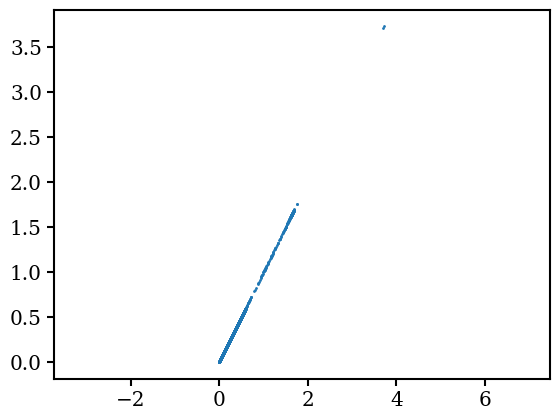

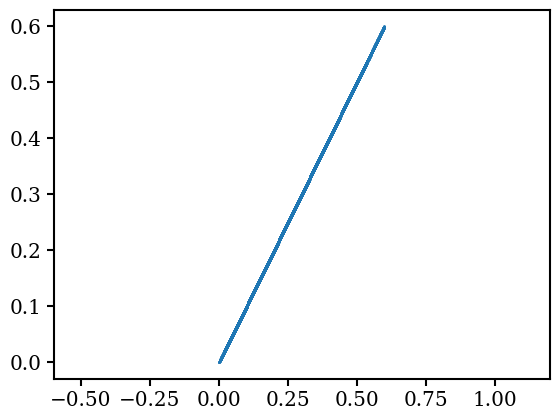

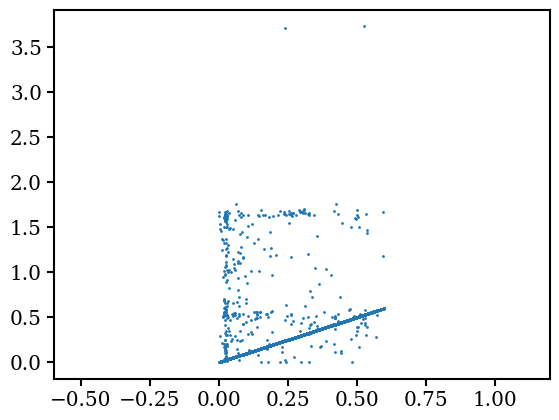

In [8]:
plt.scatter(sv3_gals["RR_Z"], sv3_gals["Z"],s=1)
plt.show()

plt.scatter(sv3_gals["Z_TRUE"], sv3_gals["RR_Z_DEEP"],s=1)
plt.show()

plt.scatter(sv3_gals["Z_TRUE"], sv3_gals["Z"],s=1)
plt.show()

In [9]:

## hOW I AM CONSTRUCTING THE SV3 DATA FILE 
# dat_dir = '/global/cfs/cdirs/desi/users/chahah/bgs-cmxsv/sv-paper'

# sv3_gals = Table.read(os.path.join(dat_dir, 'sv3.bgs_exps.efftime160_200.zsuccess.fuji.fits'))
# sv3_gals.remove_columns(["SUBTYPE", "REF_CAT"])

# from astropy.table import Table, unique

# _,inds,cts = np.unique(sv3_gals["TARGETID"],return_index=True,return_counts=True)
# # ##there were a bunch of repeat observations in the SV3 data file ...
# sv3_gals = sv3_gals[inds]

# sv3_deep  = np.isin(sv3_gals['PRIORITY'].data, np.array([102100, 102000])) & (sv3_gals['EFFTIME_SPEC'] > 100)

# from desitarget.sv3.sv3_targetmask import bgs_mask as sv3_bgs_mask
# # catastrophic redshift errors based on deep as truth table
# sv3_catasto = np.abs(sv3_gals['RR_Z'] - sv3_gals['RR_Z_DEEP'])/(1 + sv3_gals['RR_Z_DEEP']) > 0.003
# sv3_brgt = (sv3_gals['SV3_BGS_TARGET'] & sv3_bgs_mask['BGS_BRIGHT']) != 0 

# sv3_gals_brgt = sv3_gals[sv3_brgt & sv3_deep]



In [10]:
# ## read the SAGA DR3 data and match with BGS BRI 
# saga_ras = []
# saga_decs = []
# saga_rmags = []
# saga_zreds = []
# saga_zsrc = []
# saga_gr = []


# with open("../data/other_data/saga_dr3_fullcat.txt", encoding='UTF8') as f:
#     for i,line in enumerate(f):
#         if i > 28:
#             zred_val = float(line[125:132])
            
#             zred_source = str(line[118:124])
            
#             ra_val = float(line[37:48])
#             dec_val = float(line[49:60])
#             rmag_val = float(line[61:67])
#             gr_val = float(line[76:83])
            
            
#             if zred_val > 0:
#                 saga_ras.append(ra_val)
#                 saga_decs.append(dec_val)
#                 saga_rmags.append(rmag_val)
#                 saga_zreds.append(zred_val)
#                 saga_zsrc.append(zred_source)
#                 saga_gr.append(gr_val)
                

# saga_ras = np.array(saga_ras)
# saga_decs = np.array(saga_decs)
# saga_rmags = np.array(saga_rmags)
# saga_zreds = np.array(saga_zreds)
# saga_zsrc = np.array(saga_zsrc)

# saga_gr = np.array(saga_gr)


# saga_dr3 = {"RA":saga_ras, "DEC":saga_decs, "MAG_R":saga_rmags, "Z":saga_zreds, "g-r":saga_gr, "Z_SRC":saga_zsrc}
# saga_dr3 = Table(saga_dr3)


# ##matching SAGA with BGS Bright
# catalog = SkyCoord(ra=np.array(bgs_bri["TARGET_RA"])*u.degree, dec=np.array(bgs_bri["TARGET_DEC"])*u.degree)
# # catalog = SkyCoord(ra=np.array(bgs_bri["RA"])*u.degree, dec=np.array(bgs_bri["DEC"])*u.degree)
# c = SkyCoord(ra=saga_dr3["RA"].data*u.degree, dec=saga_dr3["DEC"].data*u.degree)
# idx, d2d, d3d = c.match_to_catalog_sky(catalog)

# bgs_bri_saga = bgs_bri[idx]
# bgs_bri_saga = bgs_bri_saga[d2d.arcsec < 1]
# saga_dr3_bgsb = saga_dr3[d2d.arcsec < 1]

# print(len(saga_dr3_bgsb))

# ##matching LOWZ with BGS Bright
# catalog = SkyCoord(ra=np.array(lowz_dark["TARGET_RA"])*u.degree, dec=np.array(lowz_dark["TARGET_DEC"])*u.degree)
# c = SkyCoord(ra=saga_dr3["RA"].data*u.degree, dec=saga_dr3["DEC"].data*u.degree)
# idx, d2d, d3d = c.match_to_catalog_sky(catalog)

# lowz_dark_saga = lowz_dark[idx]
# lowz_dark_saga = lowz_dark_saga[d2d.arcsec < 1]
# saga_dr3_lowz = saga_dr3[d2d.arcsec < 1]

# print(len(saga_dr3_lowz))


In [11]:
# lowz_dark[:4]

In [302]:
## trying to get more statistics on LOWZ objects by looking at deeper exposures ...
## probably best in the COSMOS field?

# Table.read("/global/cfs/cdirs/desi/users/jratajcz/C3PZ/COSMOS/v04122024/COSMOS_master.fits")


In [12]:
# # fig,ax = plt.subplots(1,1,figsize = (6,6))

# # ax.scatter(sv3_gals['RR_Z'][sv3_brgt & sv3_deep], np.log10(sv3_gals['RR_DELTACHI2'][sv3_brgt & sv3_deep]), c='gray', s=1, label='BGS Bright', rasterized=True)
# # ax.scatter(sv3_gals['RR_Z'][sv3_brgt & sv3_deep & sv3_catasto], np.log10(sv3_gals['RR_DELTACHI2'][sv3_brgt & sv3_deep & sv3_catasto]), c='C3', s=5, label=r'$|\Delta z|/z > 0.003$', rasterized=True)
# # ax.axhline(np.log10(40), color='k', linestyle='--', linewidth=3)
# # ax.text(0.45, 4.35, r'SV3 BGS Bright',fontsize=17)

# # ax.set_xlim(0.0, 0.8)
# # ax.set_xticks([0., 0.2, 0.4, 0.6, 0.8])
# # ax.set_ylim(-2, 5)

# # ax.set_xlabel(r'$z_{\rm REDROCK}$',fontsize=16) 
# # ax.set_ylabel(r'$\log\,\Delta \chi^2\,$', fontsize=16)

# # fig.subplots_adjust(wspace=0.1, hspace=0.1)
# # # fig.savefig('figs/dchi2_z.pdf', bbox_inches='tight')
# # plt.show()

# ###
# fig,ax = plt.subplots(1,1,figsize = (6,6))
# ax.scatter(sv3_gals['RR_Z'][sv3_brgt], np.log10(sv3_gals['RR_DELTACHI2'][sv3_brgt ]), c='gray', s=1, label='BGS Bright', rasterized=True)
# ax.scatter(sv3_gals['RR_Z'][sv3_brgt & sv3_catasto], np.log10(sv3_gals['RR_DELTACHI2'][sv3_brgt & sv3_catasto]), c='C3', s=5, label=r'$|\Delta z|/z > 0.003$', rasterized=True)
# ax.axhline(np.log10(40), color='k', linestyle='--', linewidth=3)
# ax.text(0.45, 4.35, r'SV3 BGS Bright',fontsize=17)
# ax.set_xlim(0.0, .8)
# ax.set_xticks([0., 0.2, 0.4, 0.6, 0.8])
# ax.set_ylim(-2, 5)
# ax.set_xlabel(r'$z_{\rm REDROCK}$',fontsize=16) 
# ax.set_ylabel(r'$\log\,\Delta \chi^2\,$', fontsize=16)
# fig.subplots_adjust(wspace=0.1, hspace=0.1)
# # fig.savefig('figs/dchi2_z.pdf', bbox_inches='tight')
# plt.show()

# fig,ax = plt.subplots(1,1,figsize = (6,6))
# ax.scatter(sv3_gals['RR_Z'][sv3_brgt & sv3_deep], np.log10(sv3_gals['RR_DELTACHI2'][sv3_brgt & sv3_deep ]), c='gray', s=1, label='BGS Bright', rasterized=True)
# ax.scatter(sv3_gals['RR_Z'][sv3_brgt & sv3_catasto & sv3_deep], np.log10(sv3_gals['RR_DELTACHI2'][sv3_brgt & sv3_catasto & sv3_deep]), c='C3', s=5, label=r'$|\Delta z|/z > 0.003$', rasterized=True)
# ax.axhline(np.log10(40), color='k', linestyle='--', linewidth=3)
# ax.text(0.45, 4.35, r'SV3 BGS Bright',fontsize=17)
# ax.set_xlim(0.0, .8)
# ax.set_xticks([0., 0.2, 0.4, 0.6, 0.8])
# ax.set_ylim(-2, 5)
# ax.set_xlabel(r'$z_{\rm REDROCK}$',fontsize=16) 
# ax.set_ylabel(r'$\log\,\Delta \chi^2\,$', fontsize=16)
# fig.subplots_adjust(wspace=0.1, hspace=0.1)
# # fig.savefig('figs/dchi2_z.pdf', bbox_inches='tight')
# plt.show()


# plt.figure(figsize = (5,5))
# plt.plot([0,1.5],[0,1.5],color ="k",lw = 1)
# plt.scatter(sv3_gals['Z_TRUE'][sv3_brgt],sv3_gals['RR_Z'][sv3_brgt],s=5,color = "grey")
# plt.scatter(sv3_gals['Z_TRUE'][sv3_brgt & sv3_catasto],sv3_gals['RR_Z'][sv3_brgt & sv3_catasto],s=5,c="C3")
# plt.xlabel(r'$z_{\rm True}$',fontsize=16) 
# plt.ylabel(r'$z_{\rm REDROCK}$',fontsize=16) 
# plt.xlim([0,1.5])
# plt.ylim([0,1.5])
# plt.show()


# saga_lowz_cats = np.abs(lowz_dark_saga["Z"] - saga_dr3_lowz["Z"])/(1 + saga_dr3_lowz["Z"]) > 0.003
# # saga_lowz_cats = np.abs(lowz_dark_saga["Z"] - saga_dr3_lowz["Z"]) > 0.003

# plt.figure(figsize = (5,5))
# plt.title("LOWZ Dark")
# plt.plot([0,1.5],[0,1.5],color ="k",lw = 1)
# plt.scatter(saga_dr3_lowz['Z'],lowz_dark_saga['Z'],s=5,color = "grey")
# plt.scatter(saga_dr3_lowz['Z'][saga_lowz_cats],lowz_dark_saga['Z'][saga_lowz_cats],s=5,c="C3")
# plt.xlabel(r'$z_{\rm SAGA}$',fontsize=16) 
# plt.ylabel(r'$z_{\rm Redrock}$',fontsize=16) 
# plt.xlim([0,.5])
# plt.ylim([0,.5])
# plt.show()


# plt.figure(figsize = (5,5))
# plt.title("LOWZ Dark")
# plt.plot([0,1.5],[0,1.5],color ="k",lw = 1)
# plt.scatter(saga_dr3_lowz['Z'],lowz_dark_saga['Z'],s=5,color = "grey")
# plt.scatter(saga_dr3_lowz['Z'][saga_lowz_cats],lowz_dark_saga['Z'][saga_lowz_cats],s=5,c="C3")
# plt.xlabel(r'$z_{\rm SAGA}$',fontsize=16) 
# plt.ylabel(r'$z_{\rm Redrock}$',fontsize=16) 
# plt.xlim([0,.15])
# plt.ylim([0,.5])
# plt.show()



In [11]:
def zsuccess_dchi2(gals, dchi2,zwarn_inc4=False):
    if zwarn_inc4==False:
        crit_zwarn = (gals['ZWARN'] == 0)
    else:
        crit_zwarn = (gals['ZWARN'] == 0) | (gals['ZWARN'] == 4)
        
    crit_dchi2 = (gals['DELTACHI2'] > dchi2)
    crit_stype = (gals['SPECTYPE'] == 'GALAXY')
    crit_z_lim = (gals['Z'] > 0.001)
    # crit_z_err = (gals['ZERR'] < (0.0005 * (1. + gals['Z'])))
    # dz_1pz     = np.abs(gals['Z_TRUE'] - gals['Z']) / (1. + gals['Z_TRUE'])
    # crit_ztrue = (dz_1pz < 0.003)
    # combine all criteria
    zsuccess   = (crit_zwarn & crit_dchi2 & crit_stype & crit_z_lim) # & crit_z_err
                  # & crit_ztrue & gals['DEEP_TRUE'])
    return zsuccess

### Construct the truth catalog for BGS Bright by combining the saga and sv3 tables

I am not using as I am not sure how reliable the SAGA redshifts and their accuracy is. They are also obtained using a method that is not redrock and so more elements that I do not understand.
For now just using BGS Bright SV data

In [12]:
#sv3 catalog
# sv3_gals_brgt = sv3_gals[sv3_brgt & sv3_deep]
sv3_gals_brgt = sv3_gals[sv3_brgt]


##get the saga catalog too
# saga_dr3_bgsb["Z_TRUE"] = saga_dr3_bgsb["Z"]
# saga_dr3_bgsb["Z"] = bgs_bri_saga["Z"]
# saga_dr3_bgsb["TARGET_RA"] = bgs_bri_saga["TARGET_RA"]
# saga_dr3_bgsb["TARGET_DEC"] = bgs_bri_saga["TARGET_DEC"]
# saga_dr3_bgsb["DELTACHI2"] = bgs_bri_saga["DELTACHI2"]
# saga_dr3_bgsb["ZWARN"] = bgs_bri_saga["ZWARN"]
# saga_dr3_bgsb["SPECTYPE"] = bgs_bri_saga["SPECTYPE"]
# saga_dr3_bgsb["TARGETID"] = bgs_bri_saga["TARGETID"]

#combine these two!
keys = ["TARGET_RA","TARGET_DEC","Z","Z_TRUE","DELTACHI2","ZWARN","SPECTYPE","TARGETID"]

# bgs_truth_catalog = vstack( [ sv3_gals_brgt[keys], saga_dr3_bgsb[keys] ]  )
bgs_truth_catalog = sv3_gals_brgt[keys]

z_cats = np.abs(bgs_truth_catalog["Z"] - bgs_truth_catalog["Z_TRUE"])/(1 + bgs_truth_catalog["Z_TRUE"]) > 0.003
bgs_truth_catalog["z_catastrophic"] = z_cats
                     

The clustering of failures at low true redshifts is probably because that is where the low fiber mags galaxies lie?

In [227]:
# saga_dr3_bgsb["RA","DEC",'Z', "Z_SRC"][saga_cats & gmask  & (bgs_bri_saga["DELTACHI2"] > 200)][:10]

In [228]:
# bgs_bri_saga[saga_cats & gmask & (bgs_bri_saga["DELTACHI2"] > 200)]["Z","TARGET_RA","TARGET_DEC","DELTACHI2"][:10]

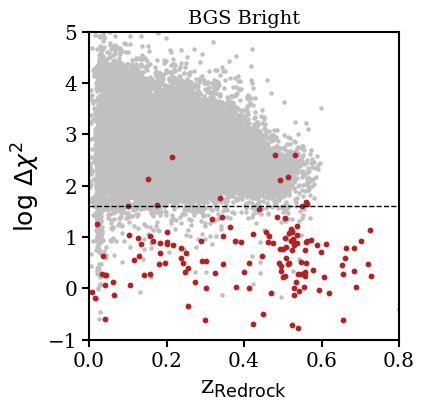

In [13]:
# axs = make_subplots(ncol=2,nrow = 1,col_spacing=1.1,label_font_size=17,direction='horizontal')
fig,ax = plt.subplots(1,1,figsize = (4,4))


##BGS Bright stuff

z_cats = np.abs(bgs_truth_catalog["Z"] - bgs_truth_catalog["Z_TRUE"])/(1 + bgs_truth_catalog["Z_TRUE"]) > 0.003

gmask = zsuccess_dchi2(bgs_truth_catalog, 0,zwarn_inc4=True)

ax.set_title('BGS Bright',size = 14)


ax.scatter(bgs_truth_catalog[gmask]["Z"], np.log10(bgs_truth_catalog[ gmask]["DELTACHI2"]), c='silver', s=5,rasterized=True)

ax.scatter(bgs_truth_catalog[z_cats & gmask]["Z"], np.log10(bgs_truth_catalog[z_cats & gmask]["DELTACHI2"]), c='firebrick', s=10,label = "Incorrect redshift",rasterized=True)

ax.axhline(np.log10(40), color='k', linestyle='--', linewidth=1)
ax.set_xlim(0.0, .8)
ax.set_ylim(-1, 5)

ax.set_xlabel(r'z$_{\rm Redrock}$',fontsize=18) 
ax.set_ylabel(r'$\log\,\Delta \chi^2\,$', fontsize=18)

plt.show()


## LOWZ stuff

# fig,ax = plt.subplots(1,1,figsize = (4,4))

# saga_lowz_cats = np.abs(lowz_dark_saga["Z"] - saga_dr3_lowz["Z"])/(1 + saga_dr3_lowz["Z"]) > 0.003

# gmask = zsuccess_dchi2(lowz_dark_saga, 0,zwarn_inc4=True)

# ax.set_title('LOWZ Dark')
# ax.scatter(lowz_dark_saga[gmask]["Z"], np.log10(lowz_dark_saga[gmask]["DELTACHI2"]), c='silver', s=5,rasterized=True)
# ax.scatter(lowz_dark_saga[saga_lowz_cats & gmask]["Z"], np.log10(lowz_dark_saga[saga_lowz_cats & gmask]["DELTACHI2"]), c='firebrick', s=10,label = "Incorrect redshift",rasterized=True)

# ax.axhline(np.log10(40), color='k', linestyle='--', linewidth=1)
# ax.set_xlim(0.0, .5)
# ax.set_ylim(-1, 5)
# ax.legend(frameon=True,fontsize = 12,markerscale=2,loc ="lower right")
# ax.set_xlabel(r'$z_{\rm Redrock}$',fontsize=18) 

# # plt.savefig('paper_plots/dchi2_zrr.pdf',bbox_inches="tight")
# plt.show()


In [230]:
# saga_dr3_lowz["RA","DEC",'Z', "Z_SRC"][saga_lowz_cats & gmask  & (lowz_dark_saga["Z"] < 0.1)][:10]

In [231]:
# lowz_dark_saga[saga_lowz_cats & gmask & (lowz_dark_saga["Z"] < 0.1)]["TARGET_RA","TARGET_DEC","Z","DELTACHI2","TARGETID"][:10]


In [232]:
# saga_dr3_lowz[saga_lowz_cats & gmask  & (lowz_dark_saga["Z"] > 0.02) & (lowz_dark_saga["Z"] < 0.04)]

In [233]:
# lowz_dark_saga[saga_lowz_cats & gmask & (lowz_dark_saga["Z"] > 0.02) & (lowz_dark_saga["Z"] < 0.04)]

plot 1) : redshift purity in bins of $\Delta\chi^2$ values. This is given a definition of redshit success (ZWARN=0 and SPECTYPE = GALAXY), how does redshift purity vary as a function of DChi2 in the low-est redshift bin (z<0.06). This plot would help inform what is a good threshold for DChi2.

In [121]:
dchi2_bins = 10**np.arange(0,4.5,np.log10(9)/4) 

dchi2_cens = 0.5*(dchi2_bins[1:] + dchi2_bins[:-1])

def get_purity_fracs(dataset, dchi2_bins, max_zred=0.1, min_zred=0.001, zwarn_inc4=True,use_true=False,min_count=5):

    purity_bgsb = []
    # purity_err_bgsb = []
    purity_err_low = []
    purity_err_high = []

    for i in range(len(dchi2_bins)-1):
        low = dchi2_bins[i]
        hi = dchi2_bins[i+1]   
        
        if use_true:
            sv3_i = dataset[( dataset["DELTACHI2"] > low)  & ( dataset["DELTACHI2"] < hi) & ( dataset["Z_TRUE"] < max_zred) & ( dataset["Z_TRUE"] > min_zred)]
        if use_true == False:
            sv3_i = dataset[( dataset["DELTACHI2"] > low)  & ( dataset["DELTACHI2"] < hi) & ( dataset["Z"] < max_zred) & ( dataset["Z"] > min_zred)]
                
        zsucc_mask = zsuccess_dchi2(sv3_i, 0,zwarn_inc4=zwarn_inc4)
        sv3_i = sv3_i[zsucc_mask]

        tot_num = len(sv3_i)
        good_num = np.sum(np.abs(sv3_i["Z"] - sv3_i["Z_TRUE"])/(1 + sv3_i["Z_TRUE"]) < 0.003)

        # https://en.wikipedia.org/wiki/Binomial_proportion_confidence_interval#Normal_approximation_interval
        ## reading this for accurate uncertainties!!
    # # https://www.mwsug.org/proceedings/2008/pharma/MWSUG-2008-P08.pdf

        if tot_num > min_count:
            frac = good_num/tot_num
            print(low, hi, good_num,tot_num)
        
            purity_bgsb.append(good_num/tot_num)

            err_i = np.sqrt(frac * (1- frac)/tot_num)
            result = binomtest(k=good_num, n=tot_num)
            # purity_err_low.append(frac - result.proportion_ci(confidence_level = 0.95,method="exact").low )
            # purity_err_high.append(result.proportion_ci(confidence_level = 0.95,method="exact").high - frac)
            purity_err_low.append(err_i )
            purity_err_high.append(err_i)
        else:
            print(low, hi, good_num,tot_num)
            purity_bgsb.append(np.nan)
            purity_err_low.append(np.nan )
            purity_err_high.append(np.nan)

    return purity_bgsb, purity_err_low, purity_err_high
    

In [59]:
##computing the purity fractions

# dchi2_bins = 10**np.arange(0,5,1)

    
# purity_bgsb_z0_tr, purity_err_low_z0_tr, purity_err_high_z0_tr = get_purity_fracs(max_zred=0.05, min_zred=0.001,zwarn_inc4=True,use_true=True)
# purity_bgsb_z1_tr, purity_err_low_z1_tr, purity_err_high_z1_tr = get_purity_fracs(max_zred=0.1, min_zred=0.05,zwarn_inc4=True,use_true=True)
# purity_bgsb_z2_tr, purity_err_low_z2_tr, purity_err_high_z2_tr = get_purity_fracs(max_zred=0.15, min_zred=0.1,zwarn_inc4=True,use_true=True)

print("--")

purity_bgsb_z0, purity_err_low_z0, purity_err_high_z0 = get_purity_fracs(bgs_truth_catalog, dchi2_bins, max_zred=0.15, min_zred=0.001,zwarn_inc4=True,use_true=False)
# purity_bgsb_z1, purity_err_low_z1, purity_err_high_z1 = get_purity_fracs(max_zred=0.1, min_zred=0.05,zwarn_inc4=True,use_true=False)
# purity_bgsb_z2, purity_err_low_z2, purity_err_high_z2 = get_purity_fracs(max_zred=0.15, min_zred=0.1,zwarn_inc4=True,use_true=False)

print("--")
# purity_bgsb_0, purity_err_low_0, purity_err_high_0 = get_purity_fracs(max_zred=0.15, zwarn_inc4=False)
    

--
1.0 1.7320508075688772 3 6
1.7320508075688772 3.0 10 14
3.0 5.196152422706632 9 12
5.196152422706632 9.0 27 28
9.0 15.588457268119894 35 37
15.588457268119894 27.000000000000004 60 61
27.000000000000004 46.765371804359674 128 129
46.765371804359674 81.0 273 273
81.0 140.296115413079 473 473
140.296115413079 242.99999999999997 865 865
242.99999999999997 420.8883462392372 1329 1329
420.8883462392372 729.0000000000001 1699 1699
729.0000000000001 1262.6650387177122 2076 2076
1262.6650387177122 2186.999999999999 1838 1838
2186.999999999999 3787.995116153134 1468 1468
3787.995116153134 6561.0 870 870
6561.0 11363.985348459393 430 430
11363.985348459393 19682.999999999985 198 198
--


In [52]:
# # dchi2_cens
# from scipy.optimize import curve_fit

# def sigmoid_tanh(x, x0, k):
#     return 1 / (1 + np.exp(-k * (x - x0)))


# popt_i, _  = curve_fit(f=sigmoid_tanh, xdata=np.log10(dchi2_cens),ydata = purity_bgsb_z0,p0=[0.5,1])
# dchi2_grid = np.linspace(0,4,100)

# plt.plot(dchi2_grid, sigmoid_tanh(dchi2_grid, popt_i[0], popt_i[1]) , color="k",lw = 1 )
# print("dark",popt_i)


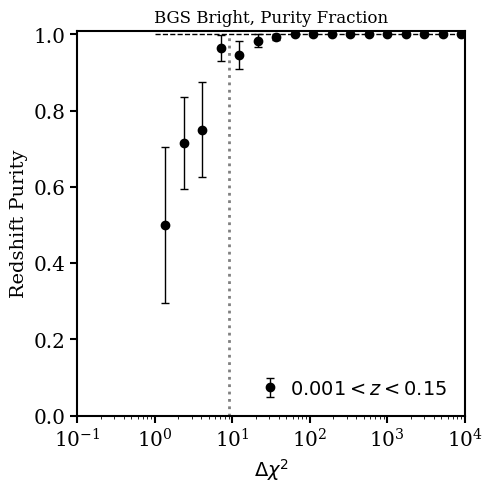

In [60]:
plt.figure(figsize = (5,5))
plt.title(r"BGS Bright, Purity Fraction") #, ZWARN = 0, SPECTYPE = GALAXY

plt.errorbar(dchi2_cens, purity_bgsb_z0, yerr = np.array([purity_err_low_z0, purity_err_high_z0]),color = "k",
             ls="none",marker="o",ms=6,elinewidth = 1,capsize = 3, label = r"$0.001 < z < 0.15$")


# plt.plot(10**dchi2_grid, sigmoid_tanh(dchi2_grid, popt_i[0], popt_i[1]) , color="k",lw = 7,alpha = 0.3)


# plt.errorbar(dchi2_cens, purity_bgsb_z1, yerr = np.array([purity_err_low_z1, purity_err_high_z1]),color = "firebrick",
#              ls="none",marker="o",ms=6,elinewidth = 1,capsize = 3, label = r"$0.075 < z < 0.15$")

# plt.errorbar(dchi2_cens, purity_bgsb_z2, yerr = np.array([purity_err_low_z2, purity_err_high_z2]),color = "firebrick",
             # ls="none",marker="o",ms=6,elinewidth = 1,capsize = 3, label = r"$0.1 < z < 0.15$")


# plt.errorbar(dchi2_cens, purity_bgsb_z0_tr, yerr = np.array([purity_err_low_z0_tr, purity_err_high_z0_tr]),color = "silver",
#              ls="none",marker="o",ms=6,elinewidth = 1,capsize = 3, label = r"$0.001 < z < 0.05$")

# plt.errorbar(dchi2_cens, purity_bgsb_z1_tr, yerr = np.array([purity_err_low_z1_tr, purity_err_high_z1_tr]),color = "darkorange",
#              ls="none",marker="o",ms=6,elinewidth = 1,capsize = 3, label = r"$0.05 < z < 0.1$")

# plt.errorbar(dchi2_cens, purity_bgsb_z2_tr, yerr = np.array([purity_err_low_z2_tr, purity_err_high_z2_tr]),color = "firebrick",
#              ls="none",marker="o",ms=6,elinewidth = 1,capsize = 3, label = r"$0.1 < z < 0.15$")

# plt.plot(dchi2_range, complete,color = "k")

plt.xscale("log")
plt.hlines(y = 1, xmin=1, xmax = 1e5,color = "k",lw = 1,ls = "--")
plt.xlim([.1, 10**4])
plt.ylim([0., 1.01])
plt.ylabel(r"Redshift Purity",fontsize = 14)
plt.xlabel(r"$\Delta\chi^2$",fontsize = 14)

# plt.text(11,0.2,r"ZWARN=0",rotation =90,fontsize = 12,color ="grey")
# plt.text(5.5,0.2,r"ZWARN=4",rotation =90,fontsize = 12,color ="grey")

plt.vlines(x = 9, ymin = 0, ymax = 1, color = "grey",lw = 2,ls = "dotted")

plt.legend(frameon=False,fontsize = 14, loc = "lower right",handletextpad=0.025)

# plt.savefig("paper_plots/redshift_purity_dchi2.pdf",bbox_inches = "tight")

plt.show()


In [15]:
def get_bad_frac(bgs_truth_cat, z_cats, tab_mask, use_true=False,max_zred=0.15):
    '''
    Function that computes the bad frac in below panel plot
    '''
    
    if use_true:
        #bin by true redshift
        bad_num = len(bgs_truth_cat[z_cats & tab_mask & (bgs_truth_cat["Z_TRUE"] < max_zred) & (bgs_truth_cat["Z_TRUE"] > 0.001)  ])
        tot_num = len(bgs_truth_cat[tab_mask & (bgs_truth_cat["Z_TRUE"] < max_zred) & (bgs_truth_cat["Z_TRUE"] > 0.001)  ])
        
    if use_true==False:
        #bin by redrock redshift 
        bad_num = len(bgs_truth_cat[z_cats & tab_mask & (bgs_truth_cat["Z"] < max_zred) & (bgs_truth_cat["Z"] > 0.001)   ])
        tot_num = len(bgs_truth_cat[tab_mask & (bgs_truth_cat["Z"] < max_zred) & (bgs_truth_cat["Z"] > 0.001)  ])
       
    bad_frac = bad_num/tot_num

    return bad_frac


def get_comp_frac(bgs_truth_cat, z_cats, tab_mask, max_zred=0.15,use_true=False):
    '''
    Function that computes the comp frac in below panel plot
    '''

    #what fraction of galaxies with robust redshift am I removing because of my cut...completeness in this sense ...
    
    ## for this, it dfoes not matter if we are using Z_TRUE or Z_RR
    inc_good_num = len(bgs_truth_cat[~z_cats & tab_mask & (bgs_truth_cat["Z"] < max_zred) & (bgs_truth_cat["Z"] > 0.001)  ])
    total_good_num  = len(bgs_truth_cat[~z_cats & (bgs_truth_cat["Z"] < max_zred) & (bgs_truth_cat["Z"] > 0.001)  ])

    comp_frac = (inc_good_num)/(total_good_num)
    
    return comp_frac




----------------------------------------


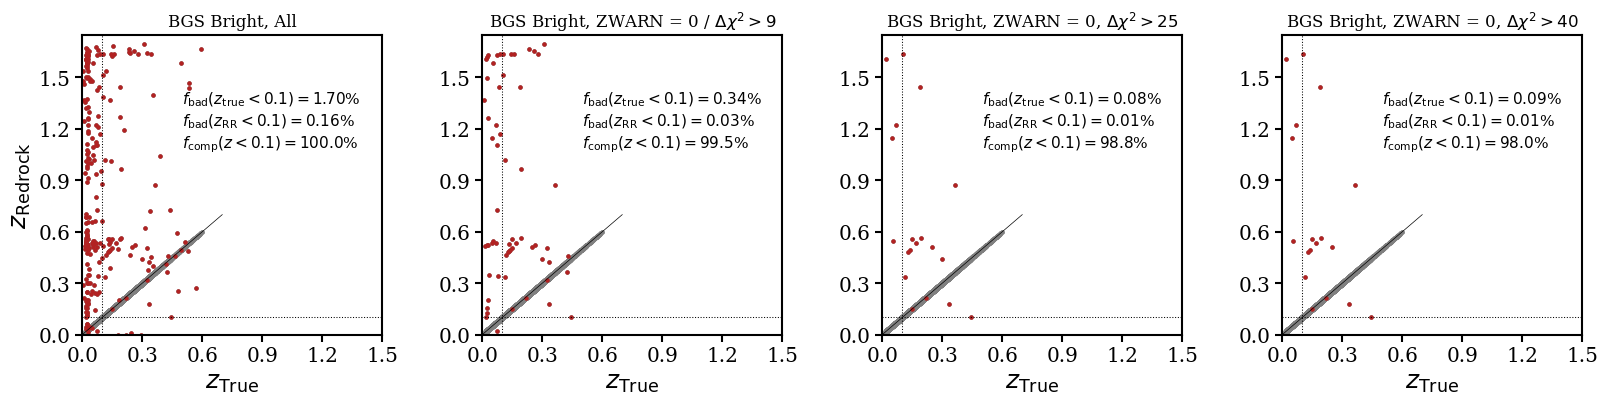

In [17]:

max_zred = 0.15

from desi_lowz_funcs import make_subplots

axs = make_subplots(ncol = 4, nrow = 1, row_spacing = 1,col_spacing = 1,label_font_size = 15,plot_size = 3,direction = "horizontal")

axs[0].set_title("BGS Bright, All")

## used in all panels 
z_cats = np.abs(bgs_truth_catalog["Z"] - bgs_truth_catalog["Z_TRUE"])/(1 + bgs_truth_catalog["Z_TRUE"]) > 0.003

axs[0].scatter(bgs_truth_catalog['Z_TRUE'],bgs_truth_catalog['Z'],s=5,color = "grey",rasterized=True)
axs[0].scatter(bgs_truth_catalog['Z_TRUE'][z_cats],bgs_truth_catalog['Z'][z_cats],s=5,c="firebrick",rasterized=True)

axs[0].set_xlim([0,1.5])
axs[0].set_ylim([0,1.5])

bad_frac_rr =   get_bad_frac(bgs_truth_catalog, z_cats, np.ones(len(bgs_truth_catalog)).astype(bool)  ,max_zred=max_zred,use_true=False)

comp_frac_rr = get_comp_frac(bgs_truth_catalog, z_cats, np.ones(len(bgs_truth_catalog)).astype(bool) , max_zred=max_zred,use_true=False)

bad_frac_true =   get_bad_frac(bgs_truth_catalog, z_cats, np.ones(len(bgs_truth_catalog)).astype(bool),  max_zred=max_zred,use_true=True)


axs[0].text(0.5,1.35,r"$f_{\rm bad}(z_{\rm true}<%.1f)=%.2f$"%(max_zred,bad_frac_true*100) + "%",fontsize = 11)
axs[0].text(0.5,1.22,r"$f_{\rm bad}(z_{\rm RR}<%.1f)=%.2f$"%(max_zred,bad_frac_rr*100) + "%",fontsize = 11)
axs[0].text(0.5,1.09,r"$f_{\rm comp}(z <%.1f)=%.1f$"%(max_zred,comp_frac_rr*100) + "%",fontsize = 11)

########################################

tab_mask = zsuccess_dchi2(bgs_truth_catalog, 9, zwarn_inc4 = True)

axs[1].set_title("BGS Bright, ZWARN = 0 / $\Delta\chi^2 > 9$")
# axs[1].set_title("BGS Bright, ZWARN = 0, $\Delta\chi^2 > 10$")


axs[1].scatter(bgs_truth_catalog[tab_mask]["Z_TRUE"], bgs_truth_catalog[tab_mask]["Z"],s=5,color = "grey",rasterized=True)
axs[1].scatter(bgs_truth_catalog[z_cats & tab_mask]["Z_TRUE"], bgs_truth_catalog[z_cats & tab_mask]["Z"],s=5,color = "firebrick",rasterized=True)

axs[1].set_xlabel(r'$z_{\rm True}$',fontsize=16) 
axs[1].set_xlim([0,1.5])
axs[1].set_ylim([0,1.5])


bad_frac_rr =   get_bad_frac(bgs_truth_catalog, z_cats, tab_mask  ,max_zred=max_zred,use_true=False)

comp_frac_rr = get_comp_frac(bgs_truth_catalog, z_cats, tab_mask , max_zred=max_zred,use_true=False)

bad_frac_true =   get_bad_frac(bgs_truth_catalog, z_cats, tab_mask,  max_zred=max_zred,use_true=True)



axs[1].text(0.5,1.35,r"$f_{\rm bad}(z_{\rm true}<%.1f)=%.2f$"%(max_zred,bad_frac_true*100) + "%",fontsize = 11)
axs[1].text(0.5,1.22,r"$f_{\rm bad}(z_{\rm RR}<%.1f)=%.2f$"%(max_zred,bad_frac_rr*100) + "%",fontsize = 11)
axs[1].text(0.5,1.09,r"$f_{\rm comp}(z <%.1f)=%.1f$"%(max_zred,comp_frac_rr*100) + "%",fontsize = 11)

#####
tab_mask = zsuccess_dchi2(bgs_truth_catalog, 25, zwarn_inc4 = False)

axs[2].set_title("BGS Bright, ZWARN = 0, $\Delta\chi^2 > 25$")

axs[2].scatter(bgs_truth_catalog[tab_mask]["Z_TRUE"], bgs_truth_catalog[tab_mask]["Z"],s=5,color = "grey",rasterized=True)
axs[2].scatter(bgs_truth_catalog[z_cats & tab_mask]["Z_TRUE"], bgs_truth_catalog[z_cats & tab_mask]["Z"],s=5,color = "firebrick",rasterized=True)
axs[2].set_xlabel(r'$z_{\rm True}$',fontsize=16) 
axs[2].set_xlim([0,1.5])
axs[2].set_ylim([0,1.5])


bad_frac_rr =   get_bad_frac(bgs_truth_catalog, z_cats, tab_mask  ,max_zred=max_zred,use_true=False)

comp_frac_rr = get_comp_frac(bgs_truth_catalog, z_cats, tab_mask , max_zred=max_zred,use_true=False)

bad_frac_true =   get_bad_frac(bgs_truth_catalog, z_cats, tab_mask,  max_zred=max_zred,use_true=True)


axs[2].text(0.5,1.35,r"$f_{\rm bad}(z_{\rm true}<%.1f)=%.2f$"%(max_zred,bad_frac_true*100) + "%",fontsize = 11)
axs[2].text(0.5,1.22,r"$f_{\rm bad}(z_{\rm RR}<%.1f)=%.2f$"%(max_zred,bad_frac_rr*100) + "%",fontsize = 11)
axs[2].text(0.5,1.09,r"$f_{\rm comp}(z <%.1f)=%.1f$"%(max_zred,comp_frac_rr*100) + "%",fontsize = 11)

print("--"*20)
#####

tab_mask = zsuccess_dchi2(bgs_truth_catalog, 40, zwarn_inc4 = False)

axs[3].set_title("BGS Bright, ZWARN = 0, $\Delta\chi^2 > 40$")

axs[3].scatter(bgs_truth_catalog[tab_mask]["Z_TRUE"], bgs_truth_catalog[tab_mask]["Z"],s=5,color = "grey",rasterized=True)
axs[3].scatter(bgs_truth_catalog[z_cats & tab_mask]["Z_TRUE"], bgs_truth_catalog[z_cats & tab_mask]["Z"],s=5,color = "firebrick",rasterized=True)


bad_frac_rr =   get_bad_frac(bgs_truth_catalog, z_cats, tab_mask  ,max_zred=max_zred,use_true=False)

comp_frac_rr = get_comp_frac(bgs_truth_catalog, z_cats, tab_mask , max_zred=max_zred,use_true=False)

bad_frac_true =   get_bad_frac(bgs_truth_catalog, z_cats, tab_mask,  max_zred=max_zred,use_true=True)


axs[3].text(0.5,1.35,r"$f_{\rm bad}(z_{\rm true}<%.1f)=%.2f$"%(max_zred,bad_frac_true*100) + "%",fontsize = 11)
axs[3].text(0.5,1.22,r"$f_{\rm bad}(z_{\rm RR}<%.1f)=%.2f$"%(max_zred,bad_frac_rr*100) + "%",fontsize = 11)
axs[3].text(0.5,1.09,r"$f_{\rm comp}(z <%.1f)=%.1f$"%(max_zred,comp_frac_rr*100) + "%",fontsize = 11)

# axs[3].text(0.5,1.22-0.27,r"$f_{\rm comp}(z_{\rm RR}<%.1f)=%.1f$"%(max_zred,comp_frac_rr*100) + "%",fontsize = 11)

axs[0].set_ylabel(r'$z_{\rm Redrock}$',fontsize=18) 

for axsi in axs:
    axsi.set_xticks([0,0.3,0.6,0.9,1.2,1.5])
    axsi.set_yticks([0,0.3,0.6,0.9,1.2,1.5])
    axsi.set_xlabel(r'$z_{\rm True}$',fontsize=18)
    axsi.vlines(x=0.1,color = "k",ls = "dotted",lw = 0.75,ymin=0,ymax = 1.75)
    axsi.hlines(y=0.1,color = "k",ls = "dotted",lw = 0.75,xmin=0,xmax = 1.75)
    axsi.set_xlim([0,1.5])
    axsi.set_ylim([0,1.75])
    axsi.plot([0,0.7],[0,0.7],color ="k",lw = 0.5)

    
# plt.savefig("paper_plots/ztrue_zrr_comp.pdf",bbox_inches="tight")

plt.show()


In [25]:
bgs_truth_catalog[(bgs_truth_catalog["Z_TRUE"] > 0.15) & (bgs_truth_catalog["Z"] < 0.15) & (bgs_truth_catalog["Z"] > 0.001) & (bgs_truth_catalog["z_catastrophic"])]

##this second object redshfit 0.1 appears to be correct! It is also measured to be z=0.1 in other data
##https://simbad.cds.unistra.fr/simbad/sim-id?Ident=%408567062&Name=%5bKEC2012%5d%20218.301222%2b33.706944&submit=submit



TARGET_RA,TARGET_DEC,Z,Z_TRUE,DELTACHI2,ZWARN,SPECTYPE,TARGETID,z_catastrophic
float64,float64,float64,float64,float64,int64,bytes6,int64,bool
216.4065306805527,33.48936872258419,0.006961460681699151,0.24249563235503563,0.8362314053210866,4,GALAXY,39632951327066882,True
218.30123504483618,33.70686052525946,0.10004377497415676,0.44187476962310973,40.8401820063591,0,GALAXY,39632956393785983,True


In [24]:
bgs_truth_catalog[(bgs_truth_catalog["Z_TRUE"] < 0.15) & (bgs_truth_catalog["Z"] < 0.15) & (bgs_truth_catalog["z_catastrophic"])  & (bgs_truth_catalog["Z"] > 0.001)]

TARGET_RA,TARGET_DEC,Z,Z_TRUE,DELTACHI2,ZWARN,SPECTYPE,TARGETID,z_catastrophic
float64,float64,float64,float64,float64,int64,bytes6,int64,bool
219.04826672867475,-1.1814318852007275,0.020651827236610933,0.0717982236880434,17.68212585087167,0,GALAXY,39627758204093732,True
180.65571872981906,-0.18008417739422844,0.041809520051829904,0.021016760281906847,1.1553575618308969,4,GALAXY,39627781717364217,True
194.25912765920418,27.131087105518596,0.06473056419630996,0.026057816693763083,0.7429066830663942,4,GALAXY,39628422527324255,True
195.07321395977405,27.355438178235186,0.033764994026633556,0.02776984964134986,1.881824603799032,4,GALAXY,39628422539906064,True
195.22420726939197,27.242739572813928,0.04305763103325057,0.03686090473491388,1.8168326113373041,4,GALAXY,39628422544098301,True
194.4838450738422,27.62394361338889,0.13320029863326693,0.02461910234630996,7.183153763297014,4,GALAXY,39628427904421026,True
195.95627716633007,27.580215830843738,0.10421226908437672,0.020386493778197193,10.963351439895632,0,GALAXY,39628427925392908,True
193.8052078597114,27.681290820940934,0.1151503568884875,0.02584944533168487,3.623906400964188,4,GALAXY,39628433252159970,True
194.73855166741012,27.752267319959454,0.12682192850506596,0.023021430378421893,9.680246647680178,0,GALAXY,39628433268933846,True


## Get Halpha flux measurements for the truth catalog so can split by that. In case of incorrect redshifts, the halpha flux is remeasured using fastspec run on correct redshift ..

In [63]:
bgs_vac = Table.read("/pscratch/sd/v/virajvm/catalog/iron_bgs_bright_vac_halpha.fits")

# bad_bgs_mask1 = (bgs_vac["HALPHA_FLUX"] == 0) & (bgs_vac["HALPHA_BOXFLUX"] >= 0)
# bad_bgs_mask2 = (bgs_vac["HALPHA_FLUX"] == 0) & (bgs_vac["HBETA_FLUX"] > 0)
# bad_bgs_mask = bad_bgs_mask1 | bad_bgs_mask2

# bgs_vac = bgs_vac[~bad_bgs_mask]

# #also remove galaxies with incomplete wavelength coverage or other warnings that would interfere

# bgs_vac = bgs_vac[(bgs_vac["ZWARN"] == 0) | (bgs_vac["ZWARN"] == 4) ]

len(bgs_vac)

4545932

In [64]:
from desi_lowz_funcs import match_c_to_catalog
idx, d2d,_ = match_c_to_catalog(c_cat = bgs_truth_catalog, catalog_cat = bgs_vac)




In [65]:
bgs_truth_match = bgs_truth_catalog[d2d.arcsec < 1]
bgs_vac_match = bgs_vac[idx][d2d.arcsec < 1]


In [66]:
print(len(bgs_truth_match), len(bgs_truth_catalog)) 

bgs_truth_match["HALPHA_FLUX"] = bgs_vac_match["HALPHA_FLUX"]
bgs_truth_match["HALPHA_BOXFLUX"] = bgs_vac_match["HALPHA_BOXFLUX"]
bgs_truth_match["Z_IRONVAC"] = bgs_vac_match["Z"]

bgs_truth_match["HALPHA_FLUX_ERR"] = 1/np.sqrt(bgs_vac_match["HALPHA_FLUX_IVAR"])
bgs_truth_match["HALPHA_FLUX_ERR"][np.isinf(bgs_truth_match["HALPHA_FLUX_ERR"])] =0



21019 38978


/tmp/ipykernel_1250939/1869836650.py:7: RuntimeWarning: divide by zero encountered in true_divide
  bgs_truth_match["HALPHA_FLUX_ERR"] = 1/np.sqrt(bgs_vac_match["HALPHA_FLUX_IVAR"])


In [68]:
# from desi_lowz_funcs import match_c_to_catalog
# idx2, d2d2,_ = match_c_to_catalog(c_cat = bgs_truth_match, catalog_cat = bgs_bri)

# bgs_truth_match = bgs_truth_match[d2d2.arcsec < 1]
# bgs_bri_match = bgs_bri[idx2][d2d2.arcsec < 1]

# bgs_truth_match["HEALPIX"] = bgs_bri_match["HEALPIX"]



In [21]:
bgs_truth_match["Z_JURA"] = bgs_bri_match["Z"]
bgs_truth_match["z_catastrophic_jura"] = ( (np.abs( bgs_truth_match["Z_JURA"] - bgs_truth_match["Z_TRUE"] )/(1+ bgs_truth_match["Z_TRUE"] )  ) > 0.003 )

# bgs_truth_match

In [22]:
bgs_truth_match.write("/pscratch/sd/v/virajvm/catalog/bgs_bright_truth_catalog_matched.fits",overwrite=True)

In [60]:
bgs_truth_match[:2]

TARGET_RA,TARGET_DEC,Z,Z_TRUE,DELTACHI2,ZWARN,SPECTYPE,TARGETID,z_catastrophic,HALPHA_FLUX,HALPHA_BOXFLUX,Z_IRONVAC,HALPHA_FLUX_ERR,HEALPIX,Z_JURA
float64,float64,float64,float64,float64,int64,bytes6,int64,bool,float32,float32,float64,float32,int32,float64
212.14293772910978,-2.127708100431868,0.18572530109199387,0.18572530109199387,473.13002466224134,0,GALAXY,39627733927463809,False,25.178051,22.525179,0.18557512097199078,2.4484954,25915,0.18557570020275455
212.24237651229095,-2.1316196803977387,0.31175262206192994,0.31175262206192994,456.7810842692852,0,GALAXY,39627733927465840,False,84.40906,81.28522,0.31173723780986745,1.3964047,25915,0.3117358683266049


In [69]:
# bgs_truth_match = Table.read("/pscratch/sd/v/virajvm/catalog/bgs_bright_truth_catalog_matched.fits")

## we re ran fastspect fit on the objects where the true redshift was different ...
bgs_truth_catas = bgs_truth_match[bgs_truth_match["z_catastrophic"]]
# bgs_truth_cats

print(len(bgs_truth_catas))
all_new_has = np.copy(bgs_truth_match["HALPHA_FLUX"].data)
all_new_has_err = np.copy(bgs_truth_match["HALPHA_FLUX_ERR"].data)



ha_catas = []
ha_err_catas = []

## read all the new HALPHA fluxes
for inds in trange(len(bgs_truth_catas)): 
    try:
        tgid = bgs_truth_catas["TARGETID"][inds]
        
        out_file = "/pscratch/sd/v/virajvm/fastspecfit_fits/output_%d.fits"%tgid
        temp = Table.read(out_file)
        ha_new = float(temp["HALPHA_FLUX"])
        ha_err_new = float(1/np.sqrt(temp["HALPHA_FLUX_IVAR"]))
        ha_catas.append(ha_new)
        ha_err_catas.append(ha_err_new) 
    except:
        ha_new = np.nan
        ha_err_new = np.nan
        ha_catas.append(ha_new)
        ha_err_catas.append(ha_err_new)
        
        
## then we do the replacing

all_new_has[ bgs_truth_match["z_catastrophic"] ] = ha_catas
all_new_has_err[ bgs_truth_match["z_catastrophic"] ] = ha_err_catas

bgs_truth_match["HALPHA_FLUX_true"] =all_new_has
bgs_truth_match["HALPHA_FLUX_ERR_true"] =all_new_has_err




78


  4%|▍         | 3/78 [00:00<00:16,  4.45it/s]/tmp/ipykernel_1250939/630581516.py:24: RuntimeWarning: divide by zero encountered in true_divide
  ha_err_new = float(1/np.sqrt(temp["HALPHA_FLUX_IVAR"]))
100%|██████████| 78/78 [00:21<00:00,  3.68it/s]


In [70]:
bgs_truth_match[ bgs_truth_match["z_catastrophic"] & (bgs_truth_match["DELTACHI2"] > 60)]

TARGET_RA,TARGET_DEC,Z,Z_TRUE,DELTACHI2,ZWARN,SPECTYPE,TARGETID,z_catastrophic,HALPHA_FLUX,HALPHA_BOXFLUX,Z_IRONVAC,HALPHA_FLUX_ERR,HALPHA_FLUX_true,HALPHA_FLUX_ERR_true
float64,float64,float64,float64,float64,int64,bytes6,int64,bool,float32,float32,float64,float32,float32,float32
183.66291030832704,0.14664983138441867,0.5122242526030122,0.24658319962210087,144.7133031450212,0,GALAXY,39627793847291194,True,22.66276,19.866451,0.24653374757612784,1.7637023,nan,nan
219.662850155979,0.4471216286689422,0.49169131129943333,0.138044600366274,128.39389729499817,0,GALAXY,39627800491068956,True,26.167725,26.19822,0.13805521054472647,1.2640568,nan,nan
217.95977817495188,35.356699507076826,-0.0005271510026027536,0.2203537644850223,196.64118691691147,0,STAR,39632986315948930,True,63.5502,63.85979,0.22036618911642547,1.3768839,50.450687,1.8748842
190.08642268153642,62.03956678150077,0.5325614030564161,0.16922134261632252,390.05617594718933,0,GALAXY,39633410695626939,True,44.607025,46.709297,0.16923635118690863,1.3650652,45.000866,1.5599892


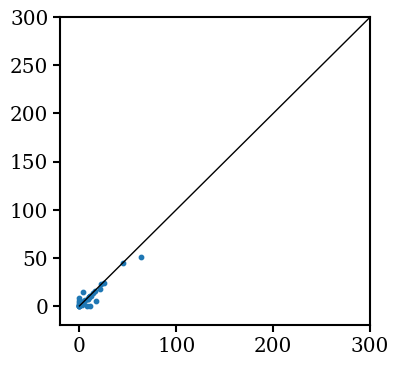

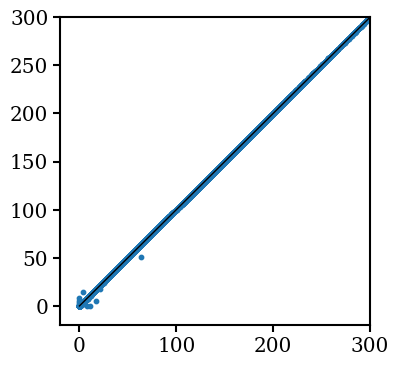

In [71]:
plt.figure(figsize = (4,4))
plt.scatter(bgs_truth_catas["HALPHA_FLUX"], ha_catas ,s=10)
plt.plot([0,300],[0,300],color = "k",lw = 1)
plt.xlim([-20,300])
plt.ylim([-20,300])
plt.show()

plt.figure(figsize = (4,4))
plt.scatter(bgs_truth_match["HALPHA_FLUX"], bgs_truth_match["HALPHA_FLUX_true"] ,s=10)
plt.plot([0,300],[0,300],color = "k",lw = 1)
plt.xlim([-20,300])
plt.ylim([-20,300])
plt.show()

In [25]:
### are the sv3_gals redshifts really indicative of what BGS BRIGHT IS LIKE ....?
### WHY ARE HTERE SOME CASES WHERE JURA ZRR IS CORRECT BUT NOT THE ONE IN SV3 GALS,
### is it becase some coadded thingy? or is it different redshift conditions??

## i think it is due to coadds...and stuff, I should just trust the sv3 redshifts ....

In [72]:
## what happens if we make a split on those with Halpha ...?
print(len(bgs_truth_match))

21019


In [86]:
bgs_truth_match_noha = bgs_truth_match[ bgs_truth_match["HALPHA_FLUX_true"] <= 5]
bgs_truth_match_yesha = bgs_truth_match[ bgs_truth_match["HALPHA_FLUX_true"] > 5]

print(len(bgs_truth_match_noha),len(bgs_truth_match_yesha))

6295 14681


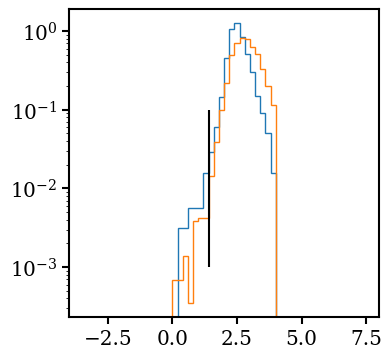

In [87]:

plt.figure(figsize = (4,4))
plt.hist( np.log10(bgs_truth_match_noha["DELTACHI2"]), range=(0,4),bins=20,density=True,histtype="step")
plt.hist( np.log10(bgs_truth_match_yesha["DELTACHI2"]), range=(0,4),bins=20,density=True,histtype="step")
plt.yscale("log")
plt.vlines(x = np.log10(25), ymin=1e-3, ymax=1e-1,color = "k")
plt.show()

In [88]:
dchi2_bins = 10**np.arange(0,4.5,np.log10(9)/2) 
dchi2_cens = 0.5*(dchi2_bins[1:] + dchi2_bins[:-1])

In [89]:
pure_tot, pure_err_low_tot, pure_err_high_tot = get_purity_fracs(bgs_truth_match, dchi2_bins, max_zred=0.15, min_zred=0.001,zwarn_inc4=True,use_true=False)


1.0 3.0 2 4
3.0 9.0 10 10
9.0 27.000000000000004 31 32
27.000000000000004 81.0 173 174
81.0 242.99999999999997 669 669
242.99999999999997 729.0000000000001 1671 1671
729.0000000000001 2186.999999999999 2230 2230
2186.999999999999 6561.0 1338 1338
6561.0 19682.999999999985 362 362


In [90]:
pure_yesha, pure_err_low_yesha, pure_err_high_yesha = get_purity_fracs(bgs_truth_match_yesha, dchi2_bins, max_zred=0.15, min_zred=0.001,zwarn_inc4=True,use_true=False)

print("--"*10)

pure_noha, pure_err_low_noha, pure_err_high_noha = get_purity_fracs(bgs_truth_match_noha, dchi2_bins, max_zred=0.15, min_zred=0.001,zwarn_inc4=True,use_true=False)

1.0 3.0 0 0
3.0 9.0 5 5
9.0 27.000000000000004 18 18
27.000000000000004 81.0 124 124
81.0 242.99999999999997 514 514
242.99999999999997 729.0000000000001 1340 1340
729.0000000000001 2186.999999999999 1821 1821
2186.999999999999 6561.0 1152 1152
6561.0 19682.999999999985 345 345
--------------------
1.0 3.0 2 2
3.0 9.0 5 5
9.0 27.000000000000004 13 13
27.000000000000004 81.0 49 50
81.0 242.99999999999997 155 155
242.99999999999997 729.0000000000001 331 331
729.0000000000001 2186.999999999999 409 409
2186.999999999999 6561.0 186 186
6561.0 19682.999999999985 17 17


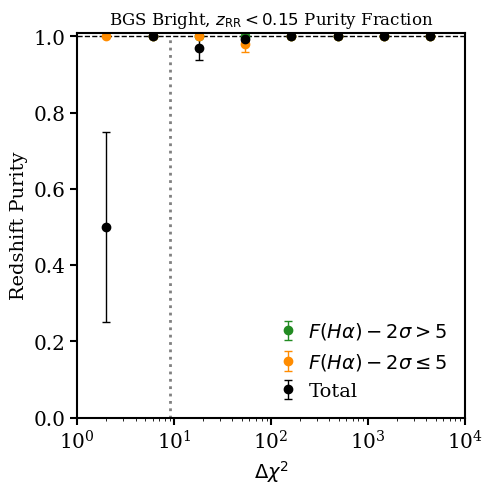

In [92]:
plt.figure(figsize = (5,5))
plt.title(r"BGS Bright, $z_{\rm RR} < 0.15$ Purity Fraction")

plt.errorbar(dchi2_cens, pure_yesha, yerr = np.array([pure_err_low_yesha, pure_err_high_yesha]),color = "forestgreen",
             ls="none",marker="o",ms=6,elinewidth = 1,capsize = 3, label = r"$F(H\alpha) - 2\sigma > 5$")

plt.errorbar(dchi2_cens, pure_noha, yerr = np.array([pure_err_low_noha, pure_err_high_noha]),color = "darkorange",
             ls="none",marker="o",ms=6,elinewidth = 1,capsize = 3, label = r"$F(H\alpha) - 2\sigma \leq 5$")


plt.errorbar(dchi2_cens, pure_tot, yerr = np.array([pure_err_low_tot, pure_err_high_tot]),color = "k",
             ls="none",marker="o",ms=6,elinewidth = 1,capsize = 3, label = r"Total")


plt.xscale("log")
plt.hlines(y = 1, xmin=1, xmax = 1e5,color = "k",lw = 1,ls = "--")
plt.xlim([1, 10**4])
plt.ylim([0., 1.01])
plt.ylabel(r"Redshift Purity",fontsize = 14)
plt.xlabel(r"$\Delta\chi^2$",fontsize = 14)

plt.vlines(x = 9, ymin = 0, ymax = 1, color = "grey",lw = 2,ls = "dotted")

plt.legend(frameon=False,fontsize = 14, loc = "lower right",handletextpad=0.025)

# plt.savefig("paper_plots/redshift_purity_dchi2.pdf",bbox_inches = "tight")

plt.show()


In [79]:
## let us get the catastrophic rate??
## at ztrue < 0.15 and function of deltachi2, what is fraction of wrong redshifts??


In [84]:
dchi2_bins = 10**np.arange(0,4.5,np.log10(9)/4) 
dchi2_cens = 0.5*(dchi2_bins[1:] + dchi2_bins[:-1])


def get_cat_fracs(bgs_truth_z015, dchi2_bins):

    cat_frac = []
    cat_frac_err = []


    for i in range(len(dchi2_bins)-1):
        low = dchi2_bins[i]
        hi = dchi2_bins[i+1]

        temp_i = bgs_truth_z015[ (bgs_truth_z015["DELTACHI2"] > low) & (bgs_truth_z015["DELTACHI2"] < hi)  ]

        #get the fraction of redshifts with cat failures
        temp_cat_mask = ((np.abs(temp_i["Z"] - temp_i["Z_TRUE"])/(1 + temp_i["Z_TRUE"])) < 0.003 )


        frac_i = np.sum(temp_cat_mask)/len(temp_i)
        cat_frac.append( frac_i )
        cat_frac_err.append( np.sqrt(frac_i * (1- frac_i)/len(temp_i) )  )
        
    return cat_frac, cat_frac_err


# bgs_truth_z015 =  bgs_truth_cat[bgs_truth_cat["Z_TRUE"] < 0.15]
bgs_truth_match_z015 =  bgs_truth_match[bgs_truth_match["Z_TRUE"] < 0.15]


bgs_truth_yesha_z015 =  bgs_truth_match_yesha[bgs_truth_match_yesha["Z_TRUE"] < 0.15]
bgs_truth_noha_z015 =  bgs_truth_match_noha[bgs_truth_match_noha["Z_TRUE"] < 0.15]


######

# cat_frac_tot, cat_frac_tot_err = get_cat_fracs(bgs_truth_z015, dchi2_bins)
cat_frac_tot2, cat_frac_tot2_err = get_cat_fracs(bgs_truth_match_z015, dchi2_bins)

cat_frac_yesha, cat_frac_yesha_err = get_cat_fracs(bgs_truth_yesha_z015, dchi2_bins)
cat_frac_noha, cat_frac_noha_err = get_cat_fracs(bgs_truth_noha_z015, dchi2_bins)




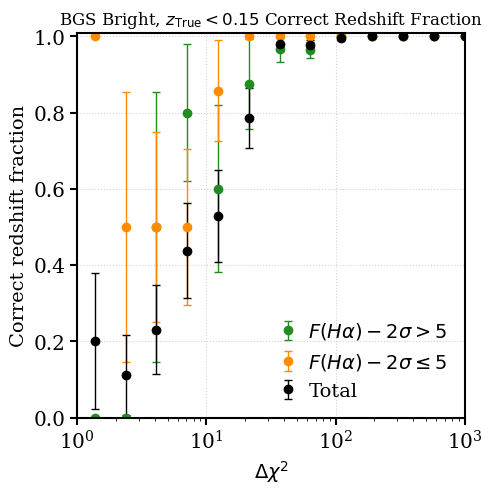

In [85]:
plt.figure(figsize = (5,5))
plt.title(r"BGS Bright, $z_{\rm True} < 0.15$ Correct Redshift Fraction")

plt.errorbar(dchi2_cens, cat_frac_yesha, yerr = np.array([cat_frac_yesha_err, cat_frac_yesha_err ]),color = "forestgreen",
             ls="none",marker="o",ms=6,elinewidth = 1,capsize = 3, label = r"$F(H\alpha) - 2\sigma > 5$")

plt.errorbar(dchi2_cens, cat_frac_noha, yerr = np.array([cat_frac_noha_err, cat_frac_noha_err]),color = "darkorange",
             ls="none",marker="o",ms=6,elinewidth = 1,capsize = 3, label = r"$F(H\alpha) - 2\sigma \leq 5$")

plt.errorbar(dchi2_cens, cat_frac_tot2, yerr = np.array([cat_frac_tot2_err, cat_frac_tot2_err]),color = "k",
             ls="none",marker="o",ms=6,elinewidth = 1,capsize = 3, label = r"Total")


plt.xscale("log")
# plt.hlines(y = 1, xmin=1, xmax = 1e5,color = "k",lw = 1,ls = "--")
plt.xlim([1, 10**3])
plt.ylim([0., 1.01])
plt.ylabel(r"Correct redshift fraction",fontsize = 14)
plt.xlabel(r"$\Delta\chi^2$",fontsize = 14)

# plt.vlines(x = 9, ymin = 0, ymax = 1, color = "grey",lw = 2,ls = "dotted")

plt.grid(ls = ":",color = "lightgrey")
plt.legend(frameon=False,fontsize = 14, loc = "lower right",handletextpad=0.025)

# plt.savefig("paper_plots/redshift_purity_dchi2.pdf",bbox_inches = "tight")

plt.show()


In [125]:
# print( len(p1_ztrue[p1_ztrue < 0.15]) )

##this is the number of not confidence redshifts zrr < 0.15 
print( len(p1_ztrue[(p1_ztrue < 0.15) & (p1_zrr > 0.15) & p1_unconf ])  )

##this is the number of not confidence redshifts zrr < 0.15 
print( len(p1_ztrue[(p1_ztrue < 0.15) & (p1_zrr < 0.15) & p1_unconf ])  )




179
157


In [30]:
## BGS BRIGHT data

p1_ztrue = sv3_gals['Z_TRUE'][sv3_brgt]
p1_zrr = sv3_gals['Z'][sv3_brgt]
# p1_unconf = ~sv3_mask[sv3_brgt]
# p1_rfib = sv3_gals["FIBER_RMAG_DRED"][sv3_brgt]
p1_dchi2 = sv3_gals["DELTACHI2"][sv3_brgt]
p1_mask = (sv3_gals["ZWARN"] == 0) | (sv3_gals["ZWARN"] == 4)
p1_mask = p1_mask[sv3_brgt]

p2_ztrue = saga_dr3_bgsb["Z"]
p2_zrr = bgs_bri_saga["Z"]
# p2_unconf = ~saga_mask
p2_dchi2 = bgs_bri_saga["DELTACHI2"]
p2_mask = (bgs_bri_saga["ZWARN"] == 0) | (bgs_bri_saga["ZWARN"] == 4)

## LOWZ Dark data
lowz_zrr = lowz_dark_saga["Z"]
lowz_dchi2 = lowz_dark_saga["DELTACHI2"]
lowz_mask = (lowz_dark_saga["ZWARN"] == 0) | (lowz_dark_saga["ZWARN"] == 4)
lowz_ztrue = saga_dr3_lowz["Z"]



dchi2_vals = np.arange(2.5,40,5)

wlost_bgsb = []
wlost_lowzd = []


for di in dchi2_vals:

    #this is for the SV3 matches
    num1 = len(p1_ztrue[(p1_ztrue <= 0.15) & (p1_zrr > 0.15)  & p1_mask & ( np.abs(p1_dchi2 - di) < 2.5 ) ]) 
    ##this is the number of not confidence redshifts zrr < 0.15 
    num2 = len(p1_ztrue[(p1_ztrue <= 0.15) & (p1_zrr <= 0.15) & p1_mask & ( np.abs(p1_dchi2 - di) < 2.5 )])
    
    #this is for the SAG matches objects
    num1_2 = len(p2_ztrue[(p2_ztrue <= 0.15) & (p2_zrr > 0.15)  & p2_mask &  ( np.abs(p2_dchi2 - di) < 2.5 ) ]) 
    ##this is the number of not confidence redshifts zrr < 0.15 
    num2_2 = len(p2_ztrue[(p2_ztrue <= 0.15) & (p2_zrr <= 0.15)  & p2_mask & ( np.abs(p2_dchi2 - di) < 2.5 )])
    

    try:
        # frac = (num1+num2 )/(num2)
        tot_num = num1+num2 + num1_2 + num2_2 
        bot_num = num2 + num2_2
        frac = tot_num / bot_num
        
        frac_lowz = tot_num_lowz/inc_num_lowz
        
        ## I can bootstrap this error .. 
        
    except:
        frac = np.nan
        frac_lowz = np.nan
        
        frac_err = np.nan
    
    ##compute the error on this quantity
    wlost_bgsb.append(frac)
    wlost_lowzd.append(frac_lowz)
    
    
dchi2_vals_lowz = np.arange(2.5,100,10)

wlost_lowzd = []

for di in dchi2_vals_lowz:   
    
    ## get same for the LOWZ Dark stuff
    tot_num_lowz = len(lowz_ztrue[ (lowz_ztrue <= 0.15) & lowz_mask & (np.abs( lowz_dchi2 - di) < 5 ) ] )
    inc_num_lowz = len(lowz_ztrue[ (lowz_ztrue <= 0.15) & (lowz_zrr <= 0.15) & lowz_mask & (np.abs( lowz_dchi2 - di) < 5 ) ] )
        
    print(tot_num_lowz,inc_num_lowz, di)
    
    try:
        frac_lowz = tot_num_lowz/inc_num_lowz        
    except:
        frac_lowz = np.nan
            
    wlost_lowzd.append(frac_lowz)
        
    

1 1 2.5
3 1 12.5
3 1 22.5
4 4 32.5
2 2 42.5
2 2 52.5
8 8 62.5
4 4 72.5
5 5 82.5
5 5 92.5


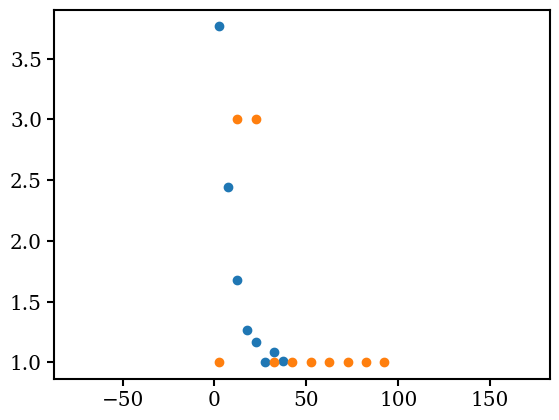

In [31]:
plt.scatter(dchi2_vals, wlost_bgsb)
plt.scatter(dchi2_vals_lowz, wlost_lowzd)



# plt.xlim([19.5,23])
plt.show()

In [146]:
dchi2_vals

array([ 2.5,  7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5])

In [147]:
all_nums

[3.765625,
 2.4444444444444446,
 1.6756756756756757,
 1.2682926829268293,
 1.1666666666666667,
 1.0,
 1.0888888888888888,
 1.0153846153846153]

In [71]:
print( len(p1_ztrue[(p1_ztrue < 0.15) & (p1_zrr > 0.15) & p1_unconf & ( np.abs(p1_rfib - 22) < 0.25 ) ])  )

##this is the number of not confidence redshifts zrr < 0.15 
print( len(p1_ztrue[(p1_ztrue < 0.15) & (p1_zrr < 0.15) & p1_unconf & ( np.abs(p1_rfib - 22) < 0.25 )])  )

70
32


In [46]:
## of all the galaxies that are classifed as failed redshifts, 

print( len(p2_ztrue[p2_ztrue < 0.15]) )

##this is the number of not confidence redshifts zrr > 0.15 
print( len(p2_ztrue[(p2_ztrue < 0.15) & (p2_zrr > 0.15) & p2_unconf ])  )

##this is the number of not confidence redshifts zrr < 0.15 
print( len(p2_ztrue[(p2_ztrue < 0.15) & (p2_zrr < 0.15) & p2_unconf ])  )

7912
109
175


In [51]:
(179+109+157 + 175) / (157 + 175)  

1.8674698795180722

## Constructing quantitative model for purity and completeness using spectral simulations 

Some basic steps:
1) Run a bunch of mock observations spanning a wide range in rfiber and Halpha flux.
2) What factors apart from Dchi2 influence purity and completenes fracs? Just Halpha flux, or does rfib also matter?? Is it a 3d function then??
3) Once that is figured out, quantify the function
4) How well do I need to understand this function? What kind of simplifying assumptions are okay. For instance, which of purity and completeness are most relevant?


Once I get this function, I will have a weight for each galaxy: the weight will be how much to downweight it and upweight it by

In [522]:
def plt_between(ax, xvals, med, err,color="k",alpha=0.2,plot_med=True,label = None,ls = "-"):
    ax.plot(xvals, med,color = color,label = label,ls = ls)
    ax.fill_between(xvals, med - err,med + err,alpha = alpha, color =color )
    return


def catas_redshift(z_true, z_meas,cut = 0.0033):
    '''
    The fidicual cut is for redshift to be consistent to within 1000 km/s. Function returns True if redshift is consistent
    '''
    
    temp_vals = np.abs(z_true - z_meas) / (1 + z_true)
    
    return (temp_vals < cut)



def get_purity_fracs(sum_tab, dchi2_bins, dchi2_lab=None, zwarn_lab = None, zrr_lab = None,return_catas_frac=False,min_count=5):
    '''
    
    Interestingly, it seems that even if one gets non 0/4 ZWARN flags, in the forward model spectra I do not get those?? Not sure why ... 
    Is there a reason for this? This could be hinting at some problem??
    '''
    purity_frac_900 = []
    purity_frac_900_err = []
    
    for i in range(len(dchi2_bins)-1):
        #filter for the relevant objects

        temp_sum = sum_tab[ (sum_tab[dchi2_lab] > dchi2_bins[i]) & (sum_tab[dchi2_lab] < dchi2_bins[i+1])]

        #then we need to get all the objects that have ZWARN = 0 or ZWARN = 4
        
        temp_sum = temp_sum[(temp_sum[zwarn_lab] == 0) | (temp_sum[zwarn_lab] == 4)]
        
        #then we find the redshifs with catastrophic failures
        # if return_catas_frac == False:
        isgood_zred = catas_redshift(temp_sum["Z"], temp_sum[zrr_lab])
        # if return_catas_frac:
        #     isgood_zred = ~catas_redshift(temp_sum["Z"], temp_sum[zrr_lab])
        
        #this is the min_count
        if len(temp_sum) > min_count:
            #then compute the purity fraction
            pure_frac = np.sum(isgood_zred)/len(isgood_zred)

            purity_frac_900.append(pure_frac)
            purity_frac_900_err.append(  np.sqrt( pure_frac * (1-pure_frac) / len(isgood_zred) ) )
        else:
            purity_frac_900.append(np.nan)
            purity_frac_900_err.append( np.nan )

        
    return purity_frac_900, purity_frac_900_err


In [178]:
model_tot = Table.read("/pscratch/sd/v/virajvm/fsps_dwarf_spectra/bgs_bright_highemi_cat_total.fits")
print(len(model_tot))

450000


In [179]:
model_tot = model_tot[(model_tot["ZWARN"] == 0)|(model_tot["ZWARN"] == 4)]
print(len(model_tot))



450000


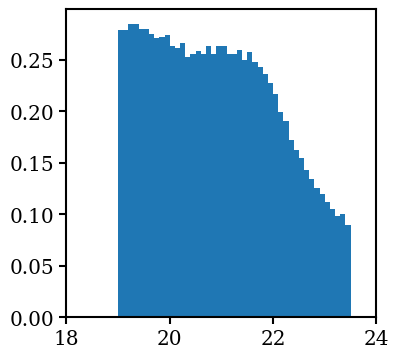

In [180]:
plt.figure(figsize = (4,4))
plt.hist(model_tot["rfib_mags_decam_noatm_new"],bins=np.arange(18,24,0.1),range=(18,24),density=True)
plt.xlim([18,24])
plt.show()

### How does rfib - Halpha - dchi2 relate to each other? In a fixed rfib bin, does dchi2 correlate strongly with dchi2?

Am I using correct fiber magnitude, maybe use SNR cuts as well instead of everything else?

In [60]:
bgs_vac = Table.read("/pscratch/sd/v/virajvm/catalog/iron_bgs_bright_vac_halpha.fits")

In [393]:
# ###3 plotting what phil suggested

# plt.hist2d( np.log10(bgs_vac[] )

# ## load the SNR values here 
iron_vac = fits.open("/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v2.1/catalogs/fastspec-iron.fits")
iron_vac2 = iron_vac[2].data
iron_vac1 = iron_vac[1].data

## select the bgs bright one 
vac_data_bgs_tgid = iron_vac2["BGS_TARGET"]
iron_scnd_tgr = iron_vac2["SCND_TARGET"]
iron_program = iron_vac2["PROGRAM"]

#BGS sample mask
from desitarget.targetmask import desi_mask, bgs_mask
iron_bgs_mask = (vac_data_bgs_tgid & bgs_mask["BGS_BRIGHT"]) != 0

bgs_rfib_flux = iron_vac2["FIBERFLUX_R"][iron_bgs_mask]
bgs_ha_ew = iron_vac1["HALPHA_EW"][iron_bgs_mask]
bgs_ha_flux = iron_vac1["HALPHA_FLUX"][iron_bgs_mask]

bgs_rfib_mag = 22.5 - 2.5*np.log10(bgs_rfib_flux)

bgs_zred = iron_vac2["Z"][iron_bgs_mask]
bgs_spect = iron_vac2["SPECTYPE"][iron_bgs_mask]
bgs_dchi2 = iron_vac2["DELTACHI2"][iron_bgs_mask]
bgs_tsnr = iron_vac2["TSNR2_BGS"][iron_bgs_mask]

del iron_vac
del iron_vac2
del iron_vac1

bgs_vac_2 = {"FIBERMAG_R":bgs_rfib_mag, "HALPHA_FLUX":bgs_ha_flux,"HALPHA_EW":bgs_ha_ew, "Z":bgs_zred, "SPECTYPE":bgs_spect, "DELTACHI2":bgs_dchi2, "TSNR2_BGS":bgs_tsnr}


In [402]:
bgs_vac_2 = {"FIBERMAG_R":bgs_rfib_mag, "HALPHA_FLUX":bgs_ha_flux,"HALPHA_EW":bgs_ha_ew, "Z":bgs_zred, "SPECTYPE":bgs_spect, "DELTACHI2":bgs_dchi2, "TSNR2_BGS":bgs_tsnr}


In [405]:
bgs_vac_2 = Table(bgs_vac_2)

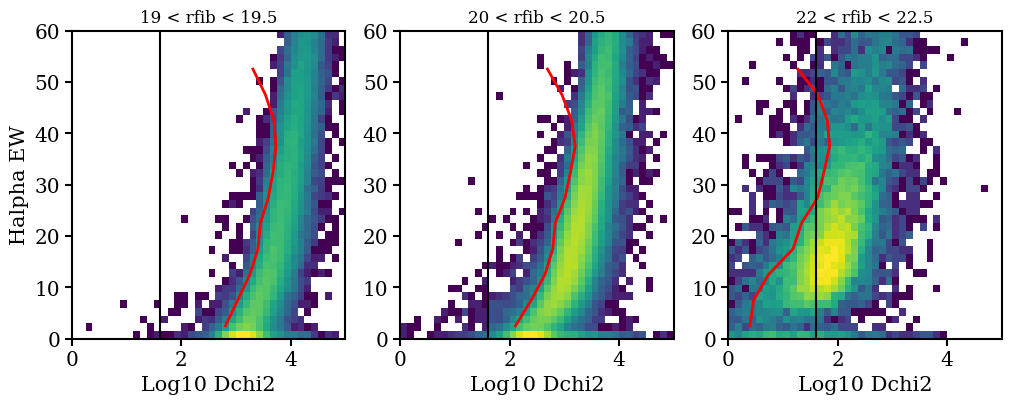

In [70]:

rfib_min= 19
rfib_max = 19.5
# &  (bgs_vac["ZWARN"] == 0)
vac_0 = (bgs_rfib_mag > rfib_min) & (bgs_rfib_mag < rfib_max) & (bgs_zred < 0.1)  &   (bgs_zred > 0.001) & (bgs_spect == "GALAXY") 

rfib_min= 20
rfib_max = 20.5
vac_1 = (bgs_rfib_mag > rfib_min) & (bgs_rfib_mag < rfib_max) & (bgs_zred < 0.1)  &   (bgs_zred > 0.001) & (bgs_spect == "GALAXY")

rfib_min= 22
rfib_max = 22.5
vac_2 = (bgs_rfib_mag > rfib_min) & (bgs_rfib_mag < rfib_max) & (bgs_zred < 0.1)  &   (bgs_zred > 0.001) & (bgs_spect == "GALAXY")

fig,ax = plt.subplots(1,3,figsize = (12,4))


ax[0].set_title("19 < rfib < 19.5")
ax[1].set_title("20 < rfib < 20.5")
ax[2].set_title("22 < rfib < 22.5")

ax[0].hist2d( np.log10(bgs_dchi2[vac_0]), bgs_ha_ew[vac_0],norm=LogNorm(),range=( (0,5),(0,60) ),bins=40)
ax[0].plot( temp19["median"],temp19["bin_cents"],color = "r",lw = 2)

ax[1].hist2d( np.log10(bgs_dchi2[vac_1]), bgs_ha_ew[vac_1],norm=LogNorm(),range=( (0,5),(0,60) ),bins=40)
ax[1].plot( temp20["median"],temp20["bin_cents"],color = "r",lw = 2)

ax[2].hist2d( np.log10(bgs_dchi2[vac_2]), bgs_ha_ew[vac_2],norm=LogNorm(),range=( (0,5),(0,60) ),bins=40)
ax[2].plot( temp22["median"],temp22["bin_cents"],color = "r",lw = 2)

for axi in ax:
    axi.set_xlim([0,5])
    axi.set_ylim([0,60])
    # axi.vlines(x = np.log10(5e3),ymin=-1,ymax=5,color = "k")
    axi.vlines(x = np.log10(40),ymin=0,ymax=60,color = "k",ls = "-")
    axi.set_xlabel(r"Log10 Dchi2",fontsize = 15)
    ax[0].set_ylabel(r"Halpha EW",fontsize = 15)
    
plt.show()


228894
228894
228894


/tmp/ipykernel_1721175/2320332482.py:24: RuntimeWarning: divide by zero encountered in log10
  ax[0].hist2d( np.log10(vac_0["DELTACHI2"]), np.log10(vac_0["HALPHA_FLUX"]),norm=LogNorm(),range=( (0,6),(-1,6) ),bins=40)
/tmp/ipykernel_1721175/2320332482.py:25: RuntimeWarning: divide by zero encountered in log10
  ax[1].hist2d( np.log10(vac_1["DELTACHI2"]), np.log10(vac_1["HALPHA_FLUX"]),norm=LogNorm(),range=( (0,6),(-1,6) ),bins=40)
/tmp/ipykernel_1721175/2320332482.py:26: RuntimeWarning: divide by zero encountered in log10
  ax[2].hist2d( np.log10(vac_2["DELTACHI2"]), np.log10(vac_2["HALPHA_FLUX"]),norm=LogNorm(),range=( (0,6),(-1,6) ),bins=40)


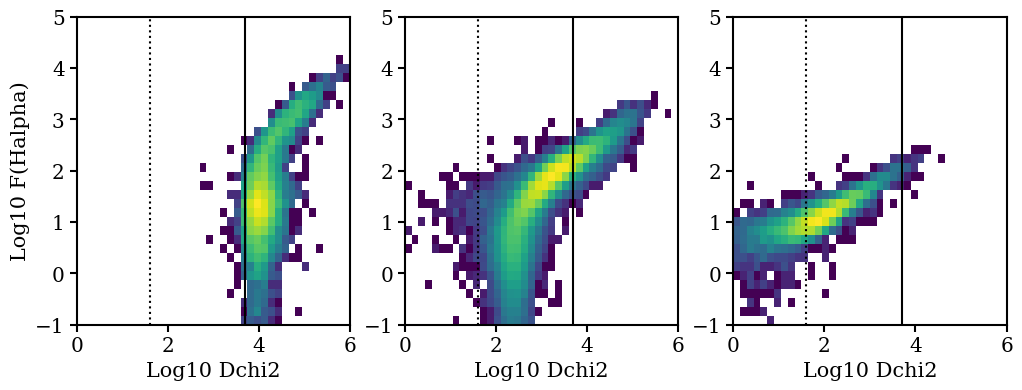

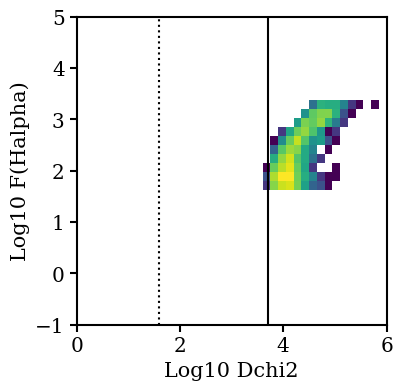

In [159]:
rfib_min= 15
rfib_max = 18
# &  (bgs_vac["ZWARN"] == 0)
vac_0 = bgs_vac[ (bgs_vac["FIBERMAG_R"] > rfib_min) & (bgs_vac["FIBERMAG_R"] < rfib_max) & (bgs_vac["Z"] < 0.15)  &   (bgs_vac["Z"] > 0.001) & (bgs_vac["SPECTYPE"]== "GALAXY") ]
print(len(vac_i))

rfib_min= 20
rfib_max = 20.5


vac_1 = bgs_vac[ (bgs_vac["FIBERMAG_R"] > rfib_min) & (bgs_vac["FIBERMAG_R"] < rfib_max) & (bgs_vac["Z"] < 0.15)&   (bgs_vac["Z"] > 0.001) & (bgs_vac["SPECTYPE"]== "GALAXY") ]
print(len(vac_i))

rfib_min= 22
rfib_max = 22.5


vac_2 = bgs_vac[ (bgs_vac["FIBERMAG_R"] > rfib_min) & (bgs_vac["FIBERMAG_R"] < rfib_max) & (bgs_vac["Z"] < 0.15) &   (bgs_vac["Z"] > 0.001) & (bgs_vac["SPECTYPE"]== "GALAXY") ]
print(len(vac_i))

fig,ax = plt.subplots(1,3,figsize = (12,4))


ax[0].hist2d( np.log10(vac_0["DELTACHI2"]), np.log10(vac_0["HALPHA_FLUX"]),norm=LogNorm(),range=( (0,6),(-1,6) ),bins=40)
ax[1].hist2d( np.log10(vac_1["DELTACHI2"]), np.log10(vac_1["HALPHA_FLUX"]),norm=LogNorm(),range=( (0,6),(-1,6) ),bins=40)
ax[2].hist2d( np.log10(vac_2["DELTACHI2"]), np.log10(vac_2["HALPHA_FLUX"]),norm=LogNorm(),range=( (0,6),(-1,6) ),bins=40)

for axi in ax:
    axi.set_xlim([0,6])
    axi.set_ylim([-1,5])
    axi.vlines(x = np.log10(5e3),ymin=-1,ymax=5,color = "k")
    axi.vlines(x = np.log10(40),ymin=-1,ymax=5,color = "k",ls = "dotted")
    axi.set_xlabel(r"Log10 Dchi2",fontsize = 15)
    ax[0].set_ylabel(r"Log10 F(Halpha)",fontsize = 15)
    
plt.show()

## let us first see it is in the model tot as well

fig,ax = plt.subplots(1,1,figsize = (4,4))
ax.hist2d( np.log10(model_tot["DELTACHI2"]), np.log10(model_tot["HALPHA_FLUX"]),norm=LogNorm(),range=( (0,6),(-1,6) ),bins=40)
ax.set_xlim([0,6])
ax.set_ylim([-1,5])
ax.vlines(x = np.log10(5e3),ymin=-1,ymax=5,color = "k")
ax.vlines(x = np.log10(40),ymin=-1,ymax=5,color = "k",ls = "dotted")
ax.set_xlabel(r"Log10 Dchi2",fontsize = 15)
ax.set_ylabel(r"Log10 F(Halpha)",fontsize = 15)
plt.show()


###########################



The above behavior of Halpha flux correlating strongly with Dchi2 in bins of fiber magnitude is seen in real data.

The behavior in the original data used to simulate obs also seems good

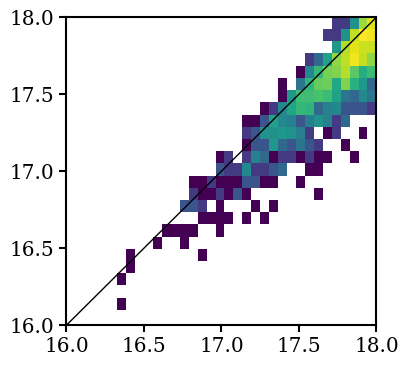

In [146]:
## are the spectra measured fiber mag vals roughly consistent with the fiber mag measured through the 

plt.figure(figsize =(4,4))
plt.hist2d(model_tot["FIBERMAG_R"], model_tot["rfib_mags_decam_noatm"],bins=30,norm=LogNorm())
plt.plot([16,18],[16,18],color = "k",lw = 1)
plt.xlim([16,18])
plt.ylim([16,18])
plt.show()

## How much do TSNR2_BGS and Dchi2 correlate? Is TSNR2 informative for our coempleteness model?

In [470]:
bgs_vac_hiz = bgs_vac_2[(bgs_vac_2["Z"] > 0.13) & (bgs_vac_2["Z"] < 0.37) &(bgs_vac_2["FIBERMAG_R"] < 21) & (bgs_vac_2["FIBERMAG_R"] > 20.5)] #  &(bgs_vac_2["HALPHA_EW"] > 10) & (bgs_vac_2["HALPHA_EW"] < 20)]
bgs_vac_lowz = bgs_vac_2[(bgs_vac_2["Z"] > 0.001) & (bgs_vac_2["Z"] < 0.15) &(bgs_vac_2["FIBERMAG_R"] < 21) & (bgs_vac_2["FIBERMAG_R"] > 20.5)] # &(bgs_vac_2["HALPHA_EW"] > 10) & (bgs_vac_2["HALPHA_EW"] < 20)]

In [471]:
from scipy.stats import pearsonr
len(bgs_vac_hiz),len(bgs_vac_lowz)
     # &(bgs_vac_2["HALPHA_EW"] > 10) & (bgs_vac_2["HALPHA_EW"] < 20)]

(842462, 244185)

In [461]:
mask = (bgs_vac_lowz["DELTACHI2"] > 1) & (bgs_vac_lowz["DELTACHI2"] < 7500)

pearsonr(np.log10(bgs_vac_lowz["DELTACHI2"][mask]) ,bgs_vac_lowz["TSNR2_BGS"][mask])

(0.23002703830207694, 0.0)

In [462]:
mask = (bgs_vac_hiz["DELTACHI2"] > 1) & (bgs_vac_hiz["DELTACHI2"] < 7500)

pearsonr(np.log10(bgs_vac_hiz["DELTACHI2"][mask]) ,bgs_vac_hiz["TSNR2_BGS"][mask])

(0.02199935609075408, 2.0849025686547742e-22)

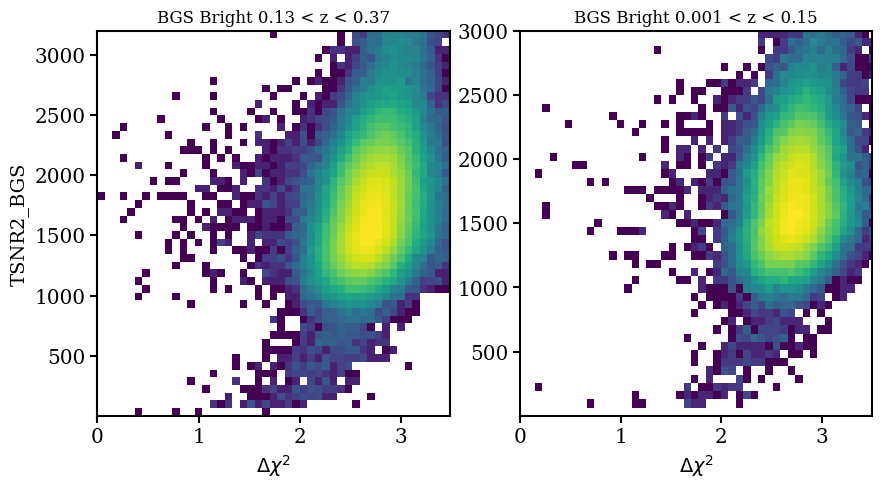

In [463]:
fig,ax = plt.subplots(1,2,figsize =(10,5))
ax[0].set_title("BGS Bright 0.13 < z < 0.37")
ax[0].hist2d(np.log10(bgs_vac_hiz["DELTACHI2"]) ,bgs_vac_hiz["TSNR2_BGS"],range= ( (0,np.log10(5000)), (1,3200) ),bins=50,norm=LogNorm() )
ax[0].set_ylim([1,3200])
ax[0].set_xlim([0,np.log10(3000)])
ax[0].set_xlabel(r"$\Delta\chi^2$",fontsize = 14)
ax[0].set_ylabel(r"TSNR2_BGS",fontsize = 14)


ax[1].set_title("BGS Bright 0.001 < z < 0.15")
ax[1].hist2d(np.log10(bgs_vac_lowz["DELTACHI2"]) ,bgs_vac_lowz["TSNR2_BGS"],range= ( (0,np.log10(5000)), (1,3200) ),bins=50,norm=LogNorm() )
# plt.scatter(bgs_vac_lowz["DELTACHI2"] ,bgs_vac_lowz["TSNR2_BGS"],s=1 )
ax[1].set_ylim([1,3000])
ax[1].set_xlim([0,np.log10(3200)])
ax[1].set_xlabel(r"$\Delta\chi^2$",fontsize = 14)
plt.show()

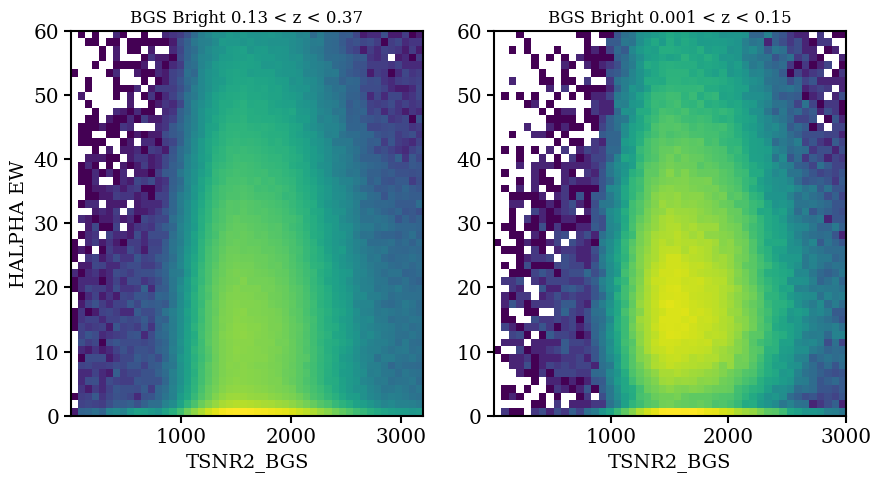

In [476]:
fig,ax = plt.subplots(1,2,figsize =(10,5))
ax[0].set_title("BGS Bright 0.13 < z < 0.37")
ax[0].hist2d(bgs_vac_hiz["TSNR2_BGS"],bgs_vac_hiz["HALPHA_EW"],range= ( (1,3200), (0,60) ),bins=50,norm=LogNorm() )
ax[0].set_xlim([1,3200])
ax[0].set_ylim([0,60])
ax[0].set_xlabel(r"TSNR2_BGS",fontsize = 14)
ax[0].set_ylabel(r"HALPHA EW",fontsize = 14)


ax[1].set_title("BGS Bright 0.001 < z < 0.15")
ax[1].hist2d(bgs_vac_lowz["TSNR2_BGS"],bgs_vac_lowz["HALPHA_EW"],range= ( (1,3200), (0,60) ),bins=50,norm=LogNorm() )
# plt.scatter(bgs_vac_lowz["DELTACHI2"] ,bgs_vac_lowz["TSNR2_BGS"],s=1 )
ax[1].set_xlim([1,3000])
ax[1].set_ylim([0,60])
ax[1].set_xlabel(r"TSNR2_BGS",fontsize = 14)
plt.show()

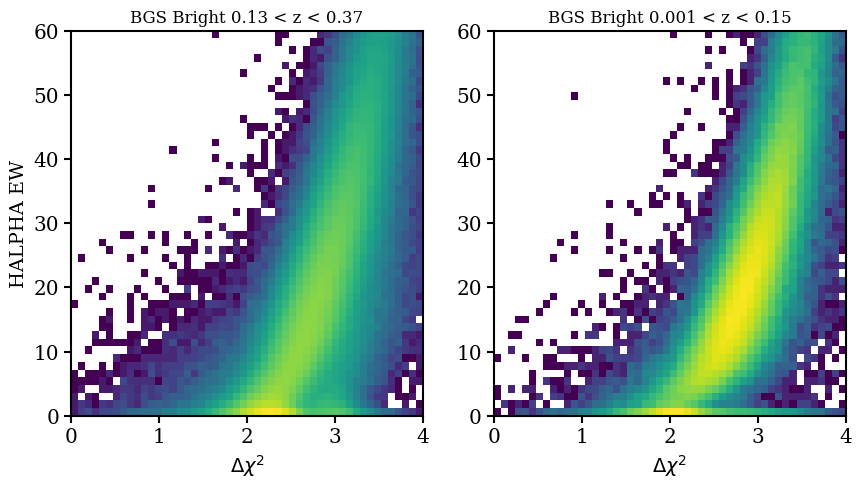

In [478]:
fig,ax = plt.subplots(1,2,figsize =(10,5))
ax[0].set_title("BGS Bright 0.13 < z < 0.37")
ax[0].hist2d(np.log10(bgs_vac_hiz["DELTACHI2"]),bgs_vac_hiz["HALPHA_EW"],range= ( (0,4), (0,60) ),bins=50,norm=LogNorm() )
ax[0].set_xlim([0,4])
ax[0].set_ylim([0,60])
ax[0].set_xlabel(r"$\Delta\chi^2$",fontsize = 14)
ax[0].set_ylabel(r"HALPHA EW",fontsize = 14)


ax[1].set_title("BGS Bright 0.001 < z < 0.15")
ax[1].hist2d(np.log10(bgs_vac_lowz["DELTACHI2"]),bgs_vac_lowz["HALPHA_EW"],range= ( (0,4), (0,60) ),bins=50,norm=LogNorm() )
# plt.scatter(bgs_vac_lowz["DELTACHI2"] ,bgs_vac_lowz["TSNR2_BGS"],s=1 )
ax[1].set_xlim([0,4])
ax[1].set_ylim([0,60])
ax[1].set_xlabel(r"$\Delta\chi^2$",fontsize = 14)
plt.show()

In the below plot I am directly comparing the spectral simulations to real data ...

In [42]:

lowz_vac = Table.read("/pscratch/sd/v/virajvm/catalog/iron_lowz_dark_vac_halpha.fits")
lowz_vac_1 = lowz_vac[(lowz_vac["FIBERMAG_R"] > 21) & (lowz_vac["FIBERMAG_R"] < 21.5)]
lowz_vac_2 = lowz_vac[(lowz_vac["FIBERMAG_R"] > 22) & (lowz_vac["FIBERMAG_R"] < 22.5)]
lowz_vac_3 = lowz_vac[(lowz_vac["FIBERMAG_R"] > 23) & (lowz_vac["FIBERMAG_R"] < 23.5)]

In [43]:
sum_emi_tot_v2 = Table.read(scratch_dir + "/fsps_model_spec_summs_V2/summary_emi_total_v2.csv")


In [48]:
sum_emi_1 = sum_emi_tot_v2[ (sum_emi_tot_v2["MAG_R"] > 21) & (sum_emi_tot_v2["MAG_R"]< 21.5) ]
sum_emi_2 = sum_emi_tot_v2[ (sum_emi_tot_v2["MAG_R"] > 22) & (sum_emi_tot_v2["MAG_R"]< 22.5) ]
sum_emi_3 = sum_emi_tot_v2[ (sum_emi_tot_v2["MAG_R"] > 23) & (sum_emi_tot_v2["MAG_R"]< 23.5) ]

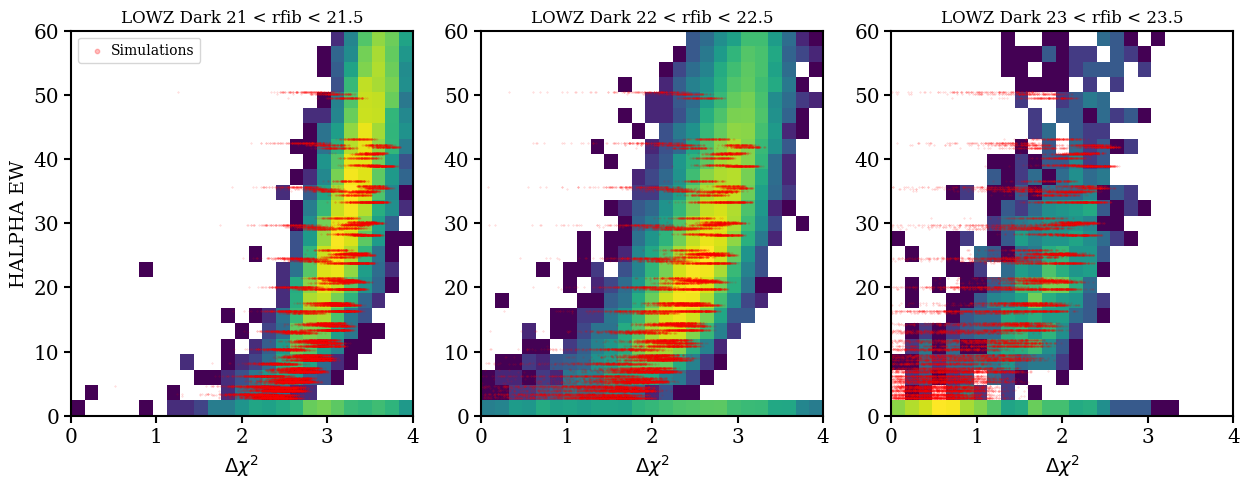

In [59]:


## now overplot the median simulation contours on this ... 

fig,ax = plt.subplots(1,3,figsize =(15,5))
ax[0].set_title("LOWZ Dark 21 < rfib < 21.5")
ax[0].hist2d(np.log10(lowz_vac_1["DELTACHI2"]),lowz_vac_1["HALPHA_EW"],range= ( (0,4), (0,60) ),bins=25,norm=LogNorm() )

ax[0].scatter( np.log10(sum_emi_1["DELTACHI2_900s"]),sum_emi_1["HALPHA_EW"], s=0.1,alpha = 0.25,color = "r",label = "Simulations")
ax[0].set_xlim([0,4])
ax[0].legend(frameon=True,loc="upper left",markerscale=10,handletextpad=0)
ax[0].set_ylim([0,60])
ax[0].set_xlabel(r"$\Delta\chi^2$",fontsize = 14)
ax[0].set_ylabel(r"HALPHA EW",fontsize = 14)


ax[1].set_title("LOWZ Dark 22 < rfib < 22.5")
ax[1].hist2d(np.log10(lowz_vac_2["DELTACHI2"]),lowz_vac_2["HALPHA_EW"],range= ( (0,4), (0,60) ),bins=25,norm=LogNorm() )
ax[1].scatter( np.log10(sum_emi_2["DELTACHI2_900s"]),sum_emi_2["HALPHA_EW"], s=0.1,alpha = 0.25,color = "r" )

# plt.scatter(bgs_vac_lowz["DELTACHI2"] ,bgs_vac_lowz["TSNR2_BGS"],s=1 )
ax[1].set_xlim([0,4])
ax[1].set_ylim([0,60])
ax[1].set_xlabel(r"$\Delta\chi^2$",fontsize = 14)

ax[2].set_title("LOWZ Dark 23 < rfib < 23.5")
ax[2].hist2d(np.log10(lowz_vac_3["DELTACHI2"]),lowz_vac_3["HALPHA_EW"],range= ( (0,4), (0,60) ),bins=25,norm=LogNorm() )
ax[2].scatter( np.log10(sum_emi_3["DELTACHI2_900s"]),sum_emi_3["HALPHA_EW"], s=0.1,alpha = 0.25,color = "r" )

# plt.scatter(bgs_vac_lowz["DELTACHI2"] ,bgs_vac_lowz["TSNR2_BGS"],s=1 )
ax[2].set_xlim([0,4])
ax[2].set_ylim([0,60])
ax[2].set_xlabel(r"$\Delta\chi^2$",fontsize = 14)
plt.show()

In [61]:
bgs_vac_1 = bgs_vac[(bgs_vac["FIBERMAG_R"] > 21) & (bgs_vac["FIBERMAG_R"] < 21.5)]
bgs_vac_2 = bgs_vac[(bgs_vac["FIBERMAG_R"] > 22) & (bgs_vac["FIBERMAG_R"] < 22.5)]
bgs_vac_3 = bgs_vac[(bgs_vac["FIBERMAG_R"] > 23) & (bgs_vac["FIBERMAG_R"] < 23.5)]

In [70]:
from desi_lowz_funcs import read_vac_line_info

bgs_vac_3 = read_vac_line_info(bgs_vac_3, columns = ["HALPHA_EW"],coord_name="TARGET_")
bgs_vac_2 = read_vac_line_info(bgs_vac_2, columns = ["HALPHA_EW"],coord_name="TARGET_")
bgs_vac_1 = read_vac_line_info(bgs_vac_1, columns = ["HALPHA_EW"],coord_name="TARGET_")


The maximum distance in arcsec is =  0.0
The maximum distance in arcsec is =  0.0
The maximum distance in arcsec is =  0.0


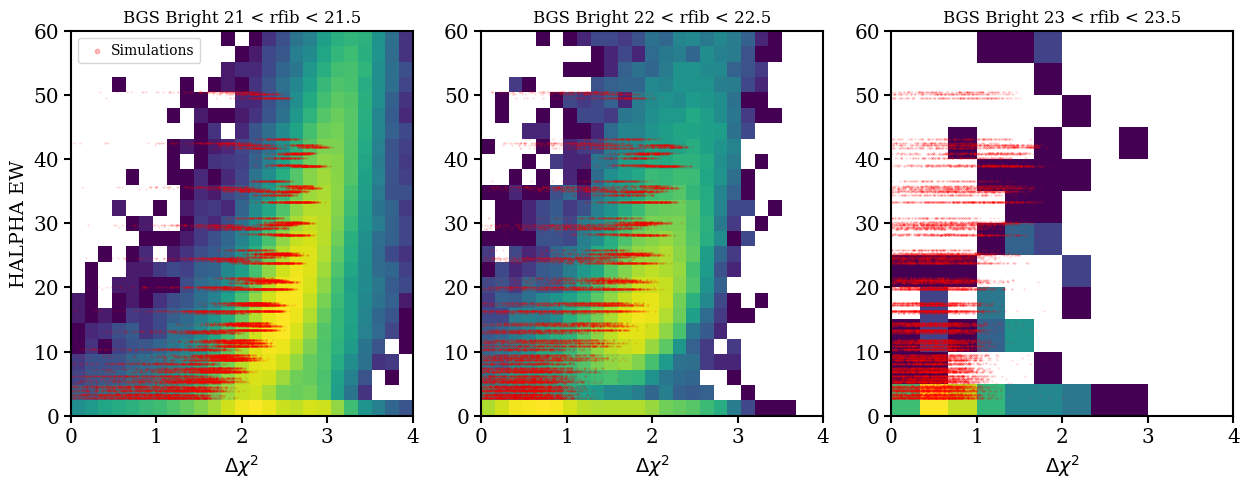

In [74]:


## now overplot the median simulation contours on this ... 

fig,ax = plt.subplots(1,3,figsize =(15,5))
ax[0].set_title("BGS Bright 21 < rfib < 21.5")
ax[0].hist2d(np.log10(bgs_vac_1["DELTACHI2"]),bgs_vac_1["HALPHA_EW"],range= ( (0,4), (0,60) ),bins=25,norm=LogNorm() )
ax[0].scatter( np.log10(sum_emi_1["DELTACHI2_180s"]),sum_emi_1["HALPHA_EW"], s=0.1,alpha = 0.25,color = "r",label = "Simulations")
ax[0].set_xlim([0,4])
ax[0].legend(frameon=True,loc="upper left",markerscale=10,handletextpad=0)
ax[0].set_ylim([0,60])
ax[0].set_xlabel(r"$\Delta\chi^2$",fontsize = 14)
ax[0].set_ylabel(r"HALPHA EW",fontsize = 14)


ax[1].set_title("BGS Bright 22 < rfib < 22.5")
ax[1].hist2d(np.log10(bgs_vac_2["DELTACHI2"]),bgs_vac_2["HALPHA_EW"],range= ( (0,4), (0,60) ),bins=25,norm=LogNorm() )
ax[1].scatter( np.log10(sum_emi_2["DELTACHI2_180s"]),sum_emi_2["HALPHA_EW"], s=0.1,alpha = 0.25,color = "r" )

# plt.scatter(bgs_vac_lowz["DELTACHI2"] ,bgs_vac_lowz["TSNR2_BGS"],s=1 )
ax[1].set_xlim([0,4])
ax[1].set_ylim([0,60])
ax[1].set_xlabel(r"$\Delta\chi^2$",fontsize = 14)

ax[2].set_title("BGS Bright 23 < rfib < 23.5")
ax[2].hist2d(np.log10(bgs_vac_3["DELTACHI2"]),bgs_vac_3["HALPHA_EW"],range= ( (0,4), (0,60) ),bins=12,norm=LogNorm() )
ax[2].scatter( np.log10(sum_emi_3["DELTACHI2_180s"]),sum_emi_3["HALPHA_EW"], s=0.1,alpha = 0.25,color = "r" )

# plt.scatter(bgs_vac_lowz["DELTACHI2"] ,bgs_vac_lowz["TSNR2_BGS"],s=1 )
ax[2].set_xlim([0,4])
ax[2].set_ylim([0,60])
ax[2].set_xlabel(r"$\Delta\chi^2$",fontsize = 14)

plt.show()

In [160]:
# plt.hist2d( model_tot["rfib_mags_decam_noatm_new"], np.log10(model_tot["HALPHA_FLUX_scaled"]),bins=100,norm=LogNorm() )
# plt.show()

In [3]:
## load the relevant continuum stellar spectra data ... 

sum_cont_tot = Table.read("fsps_model_spec_summs/summary_cont_total.csv")

cont_models = Table.read("fsps_model_spectra/fsps_cont_model_summary.csv")

## adding the model info
sum_cont_tot["logZ"] = cont_models[ np.array(sum_cont_tot["model_index"]) ]["logZ"]
sum_cont_tot["logU"] = cont_models[ np.array(sum_cont_tot["model_index"]) ]["logU"]
sum_cont_tot["tau"] = cont_models[ np.array(sum_cont_tot["model_index"]) ]["tau"]
sum_cont_tot["age"] = cont_models[ np.array(sum_cont_tot["model_index"]) ]["age"]

sum_nonebi = sum_cont_tot[(sum_cont_tot["age"] >= 3) & (sum_cont_tot["MAG_R"] < 23.5) & (sum_cont_tot["MAG_R"] > 19)]

# ##
# sum_emi_tot = Table.read("fsps_model_spec_summs/summary_emi_total.csv")

# emi_models = Table.read("fsps_model_spectra/fsps_emi_model_summary.csv")

# ## adding the model info
# sum_emi_tot["logZ"] = emi_models[ np.array(sum_emi_tot["model_index"]) ]["logZ"]
# sum_emi_tot["logU"] = emi_models[ np.array(sum_emi_tot["model_index"]) ]["logU"]
# sum_emi_tot["tau"] = emi_models[ np.array(sum_emi_tot["model_index"]) ]["tau"]
# sum_emi_tot["age"] = emi_models[ np.array(sum_emi_tot["model_index"]) ]["age"]

# ## first select same parameters but vary age 
# print(len(sum_emi_tot))
# sum_emi_tot = sum_emi_tot[ (sum_emi_tot["age"] >= 4) & (sum_emi_tot["tau"] == 2) ]
# print(len(sum_emi_tot))


18292
14396


### Loading the data from FSPS emi simulations

In [523]:
# /pscratch/sd/v/virajvm/fsps_dwarf_spectra/spec_obj_180s_%s_model_%d.fits

summ_df = Table.read(scratch_dir + "/fsps_model_spectra_V2/fsps_emi_model_summary_v2.csv")

# summ_df = Table.read("fsps_model_spectra/fsps_emi_model_summary.csv")
# ## for the emi model I am only using model with age >=4
# summ_df = summ_df[ (summ_df["age"] >= 4) & (summ_df["tau"] == 2) ]
print(len(summ_df))

## for each of these model files compute the Halpha EW


156


In [525]:
for i in trange(156):
    #loop over all the models 
    for string in ["emi"]:
        #read the summary file for this model 
        # sum_i = Table.read("fsps_model_spec_summs/summary_%s_%d.csv"%(string,i))
        sum_i = Table.read(scratch_dir + "/fsps_model_spec_summs_V2/summary_%s_model_%d.csv"%(string,i))
        
        #loop over the two exposure times
        for ti in ["180s","900s","3600s"]:
            #load the redrock output files
            # tab_i = Table.read("/pscratch/sd/v/virajvm/mock_rrs/out_%s_%s_%d.fits"%(ti, string, i))
            tab_i = Table.read("/pscratch/sd/v/virajvm/fsps_emi_rr_output_V2/spec_obj_%s_%s_model_%d.fits"%(ti, string, i))
                
            #load the summary file
            
            sum_i["model_num"] = np.ones(len(tab_i)).astype(int) * i
            
            # now we combine these tables 
            sum_i["DELTACHI2_%s"%ti] = tab_i["DELTACHI2"]
            sum_i["CHI2_%s"%ti] = tab_i["CHI2"]
            sum_i["ZWARN_%s"%ti] = tab_i["ZWARN"]
            sum_i["ZERR_%s"%ti] = tab_i["ZERR"]
            sum_i["ZRR_%s"%ti] = tab_i["Z"]
            
        ## save this updated file
        sum_i.write(scratch_dir + "/fsps_model_spec_summs_V2/summary_%s_model_%d.csv"%(string,i), overwrite=True)

          
sum_emi_tot_v2 = Table.read(scratch_dir + "/fsps_model_spec_summs_V2/summary_emi_model_0.csv")
for i in trange(1,156):
    sum_emi_i = Table.read(scratch_dir + "/fsps_model_spec_summs_V2/summary_emi_model_%d.csv"%i)
    #add this to above
    sum_emi_tot_v2 = vstack([sum_emi_tot_v2, sum_emi_i])
    
    
sum_emi_tot_v2.write(scratch_dir + "/fsps_model_spec_summs_V2/summary_emi_total_v2.csv", overwrite=True)


sum_emi_tot_v2["MAG_R"] = sum_emi_tot_v2["MAG_R"] - 2.5*np.log10( sum_emi_tot_v2["flux_factor"])
sum_emi_tot_v2["HALPHA_EW"] = np.abs(sum_emi_tot_v2["HALPHA_EW"])

sum_emi_tot_v2.write(scratch_dir + "/fsps_model_spec_summs_V2/summary_emi_total_v2.csv", overwrite=True)


100%|██████████| 155/155 [00:02<00:00, 56.61it/s]


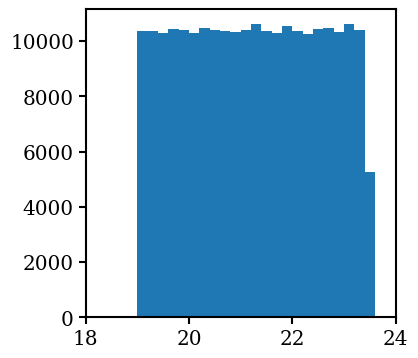

In [526]:
plt.figure(figsize = (4,4))
plt.hist(sum_emi_tot_v2["MAG_R"], bins = 30, range=(18,24))
plt.xlim([18,24])
plt.show()



In [527]:
from desi_lowz_funcs import get_contours



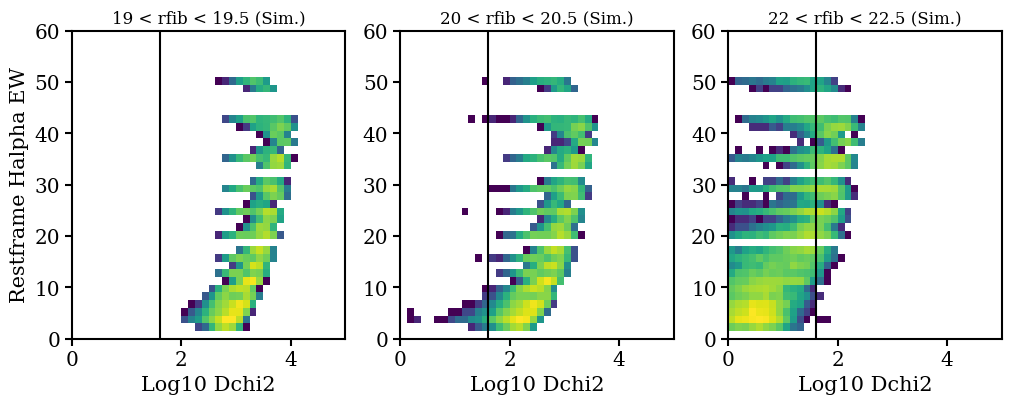

In [9]:
fig,ax = plt.subplots(1,3,figsize = (12,4))


mask = (sum_emi_tot_v2["MAG_R"] > 19) & (sum_emi_tot_v2["MAG_R"] < 19.5)
temp19 = get_contours( -1*sum_emi_tot_v2[mask]["HALPHA_EW"], np.log10(sum_emi_tot_v2[mask]["DELTACHI2_180s"]), bins = np.arange(0,60,5))
ax[0].hist2d( np.log10(sum_emi_tot_v2[mask]["DELTACHI2_180s"]), sum_emi_tot_v2[mask]["HALPHA_EW"],norm=LogNorm(),range=( (0,5),(0,60) ),bins=40)

mask = (sum_emi_tot_v2["MAG_R"] > 20) & (sum_emi_tot_v2["MAG_R"] < 20.5)
temp20 = get_contours( -1*sum_emi_tot_v2[mask]["HALPHA_EW"], np.log10(sum_emi_tot_v2[mask]["DELTACHI2_180s"]), bins = np.arange(0,60,5))

ax[1].hist2d( np.log10(sum_emi_tot_v2[mask]["DELTACHI2_180s"]), sum_emi_tot_v2[mask]["HALPHA_EW"],norm=LogNorm(),range=( (0,5),(0,60) ),bins=40)

mask = (sum_emi_tot_v2["MAG_R"] > 22) & (sum_emi_tot_v2["MAG_R"] < 22.5)
temp22 = get_contours( -1*sum_emi_tot_v2[mask]["HALPHA_EW"], np.log10(sum_emi_tot_v2[mask]["DELTACHI2_180s"]), bins = np.arange(0,60,5))

ax[2].hist2d( np.log10(sum_emi_tot_v2[mask]["DELTACHI2_180s"]), sum_emi_tot_v2[mask]["HALPHA_EW"],norm=LogNorm(),range=( (0,5),(0,60) ),bins=40)


ax[0].set_title("19 < rfib < 19.5 (Sim.)")
ax[1].set_title("20 < rfib < 20.5 (Sim.)")
ax[2].set_title("22 < rfib < 22.5 (Sim.)")


for axi in ax:
    axi.set_xlim([0,5])
    axi.set_ylim([0,60])
    # axi.vlines(x = np.log10(5e3),ymin=-1,ymax=5,color = "k")
    axi.vlines(x = np.log10(40),ymin=0,ymax=60,color = "k",ls = "-")
    axi.set_xlabel(r"Log10 Dchi2",fontsize = 15)
    ax[0].set_ylabel(r"Restframe Halpha EW",fontsize = 15)
    
plt.show()

#######

# rfib_min= 19
# rfib_max = 19.5
# # &  (bgs_vac["ZWARN"] == 0)
# vac_0 = (bgs_rfib_mag > rfib_min) & (bgs_rfib_mag < rfib_max) & (bgs_zred < 0.1)  &   (bgs_zred > 0.001) & (bgs_spect == "GALAXY") 

# rfib_min= 20
# rfib_max = 20.5
# vac_1 = (bgs_rfib_mag > rfib_min) & (bgs_rfib_mag < rfib_max) & (bgs_zred < 0.1)  &   (bgs_zred > 0.001) & (bgs_spect == "GALAXY")

# rfib_min= 22
# rfib_max = 22.5
# vac_2 = (bgs_rfib_mag > rfib_min) & (bgs_rfib_mag < rfib_max) & (bgs_zred < 0.1)  &   (bgs_zred > 0.001) & (bgs_spect == "GALAXY")

# fig,ax = plt.subplots(1,3,figsize = (12,4))


# ax[0].set_title("19 < rfib < 19.5")
# ax[1].set_title("20 < rfib < 20.5")
# ax[2].set_title("22 < rfib < 22.5")

# ax[0].hist2d( np.log10(bgs_dchi2[vac_0]), bgs_ha_ew[vac_0],norm=LogNorm(),range=( (0,5),(0,60) ),bins=40)
# ax[0].plot( temp19["median"],temp19["bin_cents"],color = "r",lw = 2)

# ax[1].hist2d( np.log10(bgs_dchi2[vac_1]), bgs_ha_ew[vac_1],norm=LogNorm(),range=( (0,5),(0,60) ),bins=40)
# ax[1].plot( temp20["median"],temp20["bin_cents"],color = "r",lw = 2)

# ax[2].hist2d( np.log10(bgs_dchi2[vac_2]), bgs_ha_ew[vac_2],norm=LogNorm(),range=( (0,5),(0,60) ),bins=40)
# ax[2].plot( temp22["median"],temp22["bin_cents"],color = "r",lw = 2)

# for axi in ax:
#     axi.set_xlim([0,5])
#     axi.set_ylim([0,60])
#     # axi.vlines(x = np.log10(5e3),ymin=-1,ymax=5,color = "k")
#     axi.vlines(x = np.log10(40),ymin=0,ymax=60,color = "k",ls = "-")
#     axi.set_xlabel(r"Log10 Dchi2",fontsize = 15)
#     ax[0].set_ylabel(r"Halpha EW",fontsize = 15)
    
# plt.show()



The behavior of dchi2 vs. Halpha EW seems to be as expected for simulations, albeit some offset in Dchi2 values. That in principle could br resolved by changing exposure time slightly, but we will leave this as is for now .

Also, the smaller Dchi2 at higher EW could be because of the weird spectra features, also could be because of higher zred? Test this by only doing z=0.05
spectra or something

## Part 1) Purity fractions 

In [84]:
# dchi2_bins = 10**np.arange(0,4.5,np.log10(9)/4) 
# dchi2_cens = 0.5*(dchi2_bins[1:] + dchi2_bins[:-1])

# ## SPLIT BY HA FLUX
# all_pw_bri = []
# all_pw_bri_err = []

# all_pw_dark = []
# all_pw_dark_err = []

# all_hacens = []

# halpha_bins = np.arange(0,20,5)

# for i in range(len(halpha_bins)-1):

#     pf180_highemi_j, pf180_highemi_j_err = get_purity_fracs(model_tot[(model_tot["HALPHA_FLUX_scaled"] > halpha_bins[i]) & (model_tot["HALPHA_FLUX_scaled"] < halpha_bins[i+1]) & (model_tot["ZRR_180s"] < 0.15)], dchi2_bins, 
#                                                             dchi2_lab="DELTACHI2_180s", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s",return_catas_frac=False)
    
#     pf900_highemi_j, pf900_highemi_j_err = get_purity_fracs(model_tot[(model_tot["HALPHA_FLUX_scaled"] > halpha_bins[i]) & (model_tot["HALPHA_FLUX_scaled"] < halpha_bins[i+1]) & (model_tot["ZRR_900s"] < 0.15)], dchi2_bins, 
#                                                             dchi2_lab="DELTACHI2_900s", zwarn_lab = "ZWARN_900s", zrr_lab = "ZRR_900s",return_catas_frac=False)
    
#     all_hacens.append( 0.5*(halpha_bins[i] + halpha_bins[i+1]) )
    
#     all_pw_bri.append(pf180_highemi_j)
#     all_pw_bri_err.append(pf180_highemi_j_err)
    
#     all_pw_dark.append(pf900_highemi_j)
#     all_pw_dark_err.append(pf900_highemi_j_err)
    

    

In [85]:
# ## what happens if I take a narrow range of Halpha flux and split by fiber mag


# pf180_highemi_g1, pf180_highemi_g1_err = get_purity_fracs(model_tot[(model_tot["HALPHA_FLUX_scaled"] > 5) & (model_tot["HALPHA_FLUX_scaled"] < 0) & (model_tot["ZRR_180s"] < 0.15)], dchi2_bins, 
#                                                         dchi2_lab="DELTACHI2_180s", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s",return_catas_frac=False)



Getting purity fractions for the theoretical emission line spectra

In [77]:
sum_emi_tot_v2[:3]

col0,Z,MAG_R,MAG_G,g-r,flux_factor,model_index,HALPHA_EW,model_num,DELTACHI2_180s,CHI2_180s,ZWARN_180s,ZERR_180s,ZRR_180s,DELTACHI2_900s,CHI2_900s,ZWARN_900s,ZERR_900s,ZRR_900s,DELTACHI2_3600s,CHI2_3600s,ZWARN_3600s,ZERR_3600s,ZRR_3600s
int64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,int64,float64,float64,float64,float64,int64,float64,float64,float64,float64,int64,float64,float64
0,0.10070212942140826,22.101579603755674,11.891664163549772,0.47084257898368875,5.3419127740651056e-05,0,-50.49606737085049,0,20.367572674527764,8753.541480852291,0,3.845786668406405e-05,0.1007037607896876,264.3879955112934,8907.31234022975,0,1.5357751481467645e-05,0.1007452887588219,1192.7638168931007,9788.673707902431,0,7.757245964370538e-06,0.10070433623691669
1,0.07857617390474986,19.06138741290446,11.874214825809739,0.4768583055501914,0.0008597806028230679,0,-50.49606737085049,0,2342.042454496026,11150.65989254415,0,7.470975478218874e-06,0.07858458406470596,16048.877353310585,23352.83107793331,0,3.407994939800756e-06,0.07859455148902572,66961.46252346039,69703.99607563019,0,1.7186043448250783e-06,0.07859589675755715
2,0.024551911827034083,19.499297866796898,11.883838569486137,0.43439958806354717,0.0006026379066609273,0,-50.49606737085049,0,690.1001161094755,10556.19312014617,0,1.0326440680220633e-05,0.02457866996234012,5130.7573205418885,19296.04932389781,0,4.6924159462793415e-06,0.024568653284905786,21548.457343161106,54628.95601552725,0,2.2700203925788e-06,0.024570614042915318


In [64]:
sum_emi_tot_v2ity frac by stellar continuum simulations from fsps 

# pf180_cont, pf180_cont_err = get_purity_fracs(sum_nonebi[ (sum_nonebi["ZRR_180s"] < 0.15)], dchi2_bins, dchi2_lab="DELTACHI2_180s", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s",return_catas_frac=False)
# pf900_cont, pf900_cont_err = get_purity_fracs(sum_nonebi[ (sum_nonebi["ZRR_180s"] < 0.15)], dchi2_bins, dchi2_lab="DELTACHI2_900s", zwarn_lab = "ZWARN_900s", zrr_lab = "ZRR_900s",return_catas_frac=False)

# what happens if we split the 180 one by fiber magnitude 
pf180_cont_g1, pf180_cont_g1_err = get_purity_fracs(sum_nonebi[(sum_nonebi["MAG_R"] < 23.5) & (sum_nonebi["MAG_R"] > 21.75) & (sum_nonebi["ZRR_180s"] < 0.15)], dchi2_bins, dchi2_lab="DELTACHI2_180s", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s",return_catas_frac=False)
pf180_cont_g2, pf180_cont_g2_err = get_purity_fracs(sum_nonebi[(sum_nonebi["MAG_R"] < 21.75) & (sum_nonebi["MAG_R"] > 20)& (sum_nonebi["ZRR_180s"] < 0.15)], dchi2_bins, dchi2_lab="DELTACHI2_180s", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s",return_catas_frac=False)


# what happens if we split the 180 one by fiber magnitude 
pf900_cont_g1, pf900_cont_g1_err = get_purity_fracs(sum_nonebi[(sum_nonebi["MAG_R"] < 23.5) & (sum_nonebi["MAG_R"] > 21.75)& (sum_nonebi["ZRR_180s"] < 0.15)], dchi2_bins, dchi2_lab="DELTACHI2_900s", zwarn_lab = "ZWARN_900s", zrr_lab = "ZRR_900s",return_catas_frac=False)
pf900_cont_g2, pf900_cont_g2_err = get_purity_fracs(sum_nonebi[(sum_nonebi["MAG_R"] < 21.75) & (sum_nonebi["MAG_R"] > 20)& (sum_nonebi["ZRR_180s"] < 0.15)], dchi2_bins, dchi2_lab="DELTACHI2_900s", zwarn_lab = "ZWARN_900s", zrr_lab = "ZRR_900s",return_catas_frac=False)




## Compute the 1D purity fractions 

In [528]:
def plot_1d_purity_fracs(dataset,  mask, dchi2_bins = 10**np.arange(0,4.5,np.log10(9)/4) , 
                         variable_split = "HALPHA_EW", var_plot_name = "HALPHA_EW", variable_bins = np.array([0,10,20,30,40]),
                         zrr_cut = 0.15,min_bin_count=5,cmap = plt.cm.viridis,return_catas_frac=False,ylabel = r"Purity Fraction"):
    '''
    In this funtion, we enter a dataset table and plot the purity fractions as a function of given variabels 
    '''

    dchi2_cens = 0.5*(dchi2_bins[1:] + dchi2_bins[:-1])
    var_cens = 0.5*(variable_bins[1:] + variable_bins[:-1])

    #the lists in which the purity fractions are stored
    pws_bri_emi = []
    pws_bri_emi_err = []

    pws_dark_emi = []
    pws_dark_emi_err = []

    for i in range(len(variable_bins)-1):
        
        if return_catas_frac:
            pf180_j, pf180_j_err = get_purity_fracs(dataset[(dataset[variable_split] < variable_bins[i+1]) & (dataset[variable_split] > variable_bins[i]) & mask ], dchi2_bins, 
                                                                    dchi2_lab="DELTACHI2_180s", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s",return_catas_frac=return_catas_frac,min_count=min_bin_count)

            pf900_j, pf900_j_err = get_purity_fracs(dataset[(dataset[variable_split] < variable_bins[i+1]) & (dataset[variable_split] > variable_bins[i]) & mask], dchi2_bins, 
                                                                    dchi2_lab="DELTACHI2_900s", zwarn_lab = "ZWARN_900s", zrr_lab = "ZRR_900s",return_catas_frac=return_catas_frac,min_count=min_bin_count)

        else:
            pf180_j, pf180_j_err = get_purity_fracs(dataset[(dataset[variable_split] < variable_bins[i+1]) & (dataset[variable_split] > variable_bins[i]) & mask & (dataset["ZRR_180s"] < zrr_cut) ], dchi2_bins, 
                                                                    dchi2_lab="DELTACHI2_180s", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s",return_catas_frac=return_catas_frac,min_count=min_bin_count)

            pf900_j, pf900_j_err = get_purity_fracs(dataset[(dataset[variable_split] < variable_bins[i+1]) & (dataset[variable_split] > variable_bins[i]) & mask & (dataset["ZRR_900s"] < zrr_cut) ], dchi2_bins, 
                                                                    dchi2_lab="DELTACHI2_900s", zwarn_lab = "ZWARN_900s", zrr_lab = "ZRR_900s",return_catas_frac=return_catas_frac,min_count=min_bin_count)

        pws_bri_emi.append(pf180_j)
        pws_bri_emi_err.append(pf180_j_err)

        pws_dark_emi.append(pf900_j)
        pws_dark_emi_err.append(pf900_j_err)

    ### make plot
    ax = make_subplots(ncol = 2, nrow = 1)
    
    colors_spec = cmap(np.linspace(0, 0.85, len(var_cens)))

    for i in range(len(var_cens)):
        plt_between(ax[0], dchi2_cens,np.array(pws_bri_emi[i]), np.array(pws_bri_emi_err[i]), color=colors_spec[i],alpha=0.2,plot_med=True,ls="-",label = r"%s = %.1f"%(var_plot_name, var_cens[i]) )

    for i in range(len(var_cens)):
        plt_between(ax[1], dchi2_cens,np.array(pws_dark_emi[i]), np.array(pws_dark_emi_err[i]), color=colors_spec[i],alpha=0.2,plot_med=True,ls="-",label = r"%s = %.1f"%(var_plot_name, var_cens[i]) )

    ax[0].set_ylabel(ylabel,fontsize = 14)
    ax[1].set_ylabel(ylabel,fontsize = 14)

    ax[0].set_title(r"EXPTIME = 180s",fontsize = 12)
    ax[1].set_title(r"EXPTIME = 900s",fontsize = 12)

    ax[1].legend(frameon=True,fontsize = 11,loc= "lower right")

    for axi in [ax[0],ax[1]]:
        axi.grid(ls = ":",color = "grey",alpha = 0.5)
        axi.set_xscale("log")
        axi.set_xlim([1,1e3])
        axi.set_ylim([-0.05,1.05])
        axi.set_xlabel(r"$\Delta\chi^2$",fontsize = 16)

    plt.show()

    return 


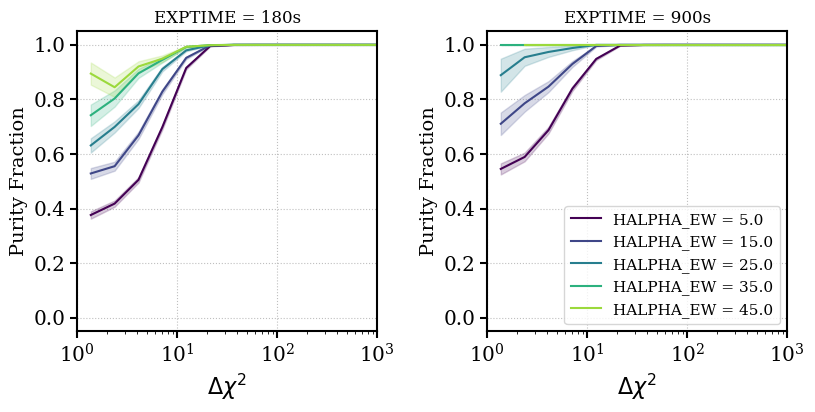

In [529]:

mask = (sum_emi_tot_v2["MAG_R"] > 19)& (sum_emi_tot_v2["MAG_R"] < 24)

plot_1d_purity_fracs(sum_emi_tot_v2,  mask, dchi2_bins = 10**np.arange(0,4.5,np.log10(9)/4) , 
                         variable_split = "HALPHA_EW", var_plot_name = "HALPHA_EW", variable_bins = np.array([0,10,20,30,40,50]),
                         zrr_cut = 0.15,min_bin_count=5)



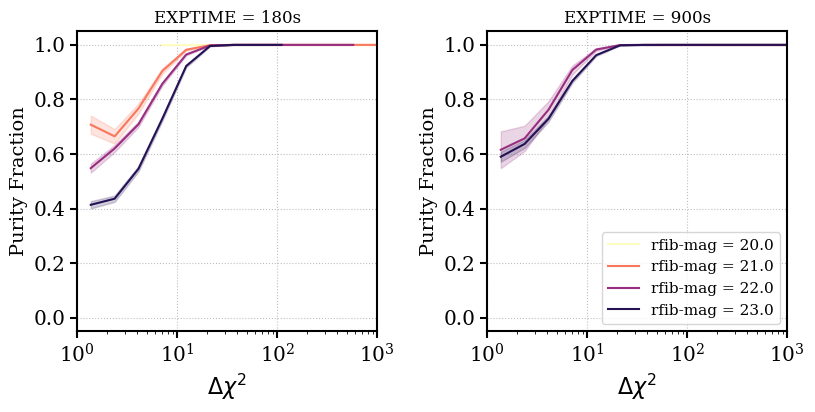

In [530]:
mask = (sum_emi_tot_v2["MAG_R"] > 19)& (sum_emi_tot_v2["MAG_R"] < 24)

plot_1d_purity_fracs(sum_emi_tot_v2,  mask, dchi2_bins = 10**np.arange(0,4.5,np.log10(9)/4) , 
                         variable_split = "MAG_R", var_plot_name = "rfib-mag", variable_bins = np.array([19.5,20.5,21.5,22.5,23.5]),
                         zrr_cut = 0.15,min_bin_count=5,cmap = plt.cm.magma_r)



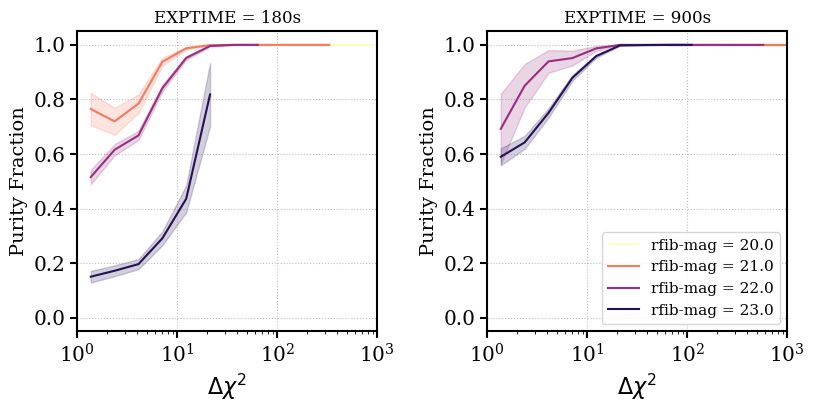

In [531]:
mask = (sum_emi_tot_v2["HALPHA_EW"] > 5)& (sum_emi_tot_v2["HALPHA_EW"] < 10)

plot_1d_purity_fracs(sum_emi_tot_v2,  mask, dchi2_bins = 10**np.arange(0,4.5,np.log10(9)/4), 
                         variable_split = "MAG_R", var_plot_name = "rfib-mag", variable_bins = np.array([19.5,20.5,21.5,22.5,23.5]),
                         zrr_cut = 0.15,min_bin_count=5,cmap = plt.cm.magma_r)



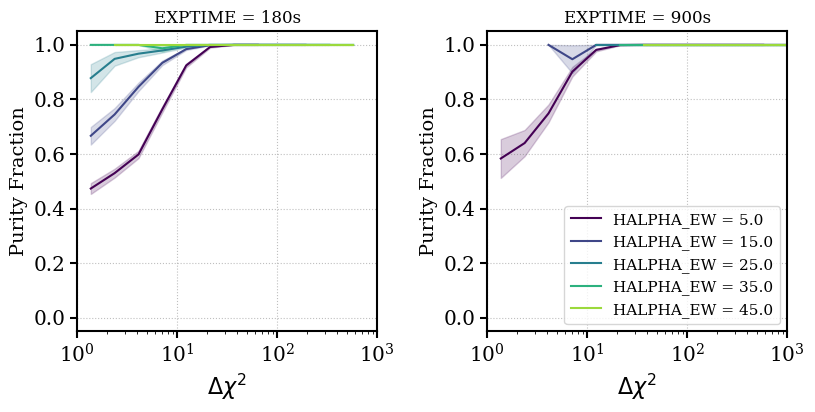

In [490]:
mask = (sum_emi_tot_v2["MAG_R"] > 21.5)& (sum_emi_tot_v2["MAG_R"] < 22.5)

plot_1d_purity_fracs(sum_emi_tot_v2,  mask, dchi2_bins = 10**np.arange(0,4.5,np.log10(9)/4), 
                         variable_split = "HALPHA_EW", var_plot_name = "HALPHA_EW", variable_bins = np.array([0,10,20,30,40,50]),
                         zrr_cut = 0.15,min_bin_count=5,cmap = plt.cm.viridis)



So it appears that both Halpha EW and fiber mag have an impact on the purity fraction. Does Dchi2 influence the purity fraction? Or do fiber mag and EW explain all the behavior??

## Compute the 2D purity fractions
 
This is to explore the trends a little bit more easily 

In [491]:
## before we begin on this, let us focus on a specific bin in Halph EW and fiber mag space. 
## Does the purity depend on dchi2 too?

ha_ew_1 = 5
ha_ew_2 = 7.5

rfib_1 = 21
rfib_2 = 21.5

temp_mods = sum_emi_tot_v2[(sum_emi_tot_v2["MAG_R"] > rfib_1) &(sum_emi_tot_v2["MAG_R"] < rfib_2) & (sum_emi_tot_v2["HALPHA_EW"] > ha_ew_1) & (sum_emi_tot_v2["HALPHA_EW"] < ha_ew_2)  ]


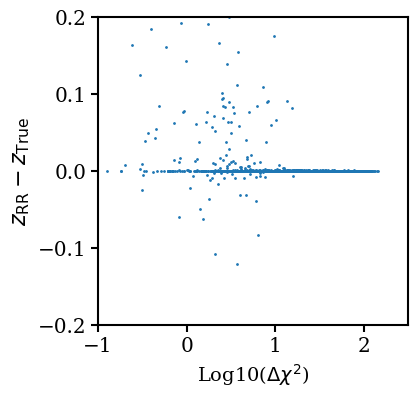

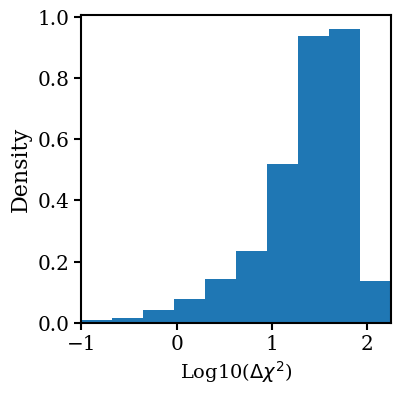

In [496]:
plt.figure(figsize = (4,4))
plt.scatter(np.log10(temp_mods["DELTACHI2_180s"]), temp_mods["ZRR_180s"] - temp_mods["Z"], s=1)
plt.ylim([-0.2,0.2])
plt.xlim([-1,2.5])
plt.ylabel(r"$z_{\rm RR} - z_{\rm True}$",fontsize = 16)
plt.xlabel(r"Log10($\Delta\chi^2$)",fontsize = 14)
plt.show()

plt.figure(figsize = (4,4))
plt.hist(np.log10(temp_mods["DELTACHI2_180s"]), range=(-1, 2.25), bins = 10,density=True)
plt.xlim(-1,2.25)
plt.ylabel(r"Density",fontsize = 16)
plt.xlabel(r"Log10($\Delta\chi^2$)",fontsize = 14)
plt.show()

In [503]:
# sum_emi_tot_v2
##we have a total fo 234k simulations, however, we can run more if need be 

## Part 2) Completeness Part

The fraction of truly low-z galaxies that have incorrect higher Redrock redshifts and so being knocked out of redshift range of interest

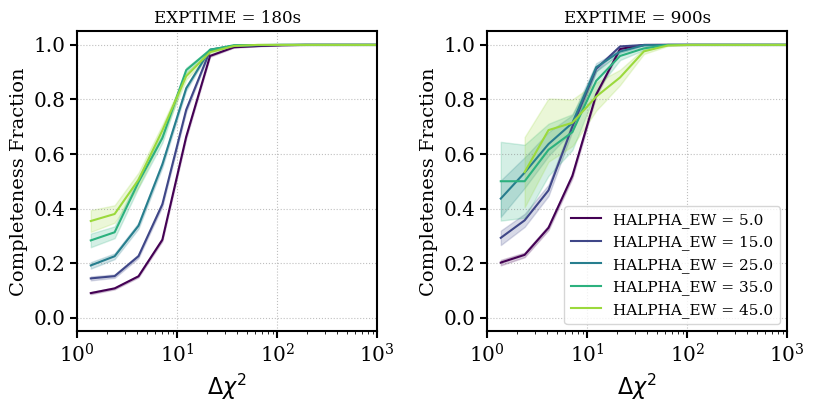

In [517]:

mask = (sum_emi_tot_v2["MAG_R"] > 19)& (sum_emi_tot_v2["MAG_R"] < 24)

plot_1d_purity_fracs(sum_emi_tot_v2,  mask, dchi2_bins = 10**np.arange(0,4.5,np.log10(9)/4) , 
                         variable_split = "HALPHA_EW", var_plot_name = "HALPHA_EW", variable_bins = np.array([0,10,20,30,40,50]),
                         zrr_cut = 0.15,min_bin_count=5,return_catas_frac=True,ylabel = r"Completeness Fraction")


## HMM IS THIS WEIRDNESS WITH LOWZ DUE TO OUT WEIRD GALAXIES?

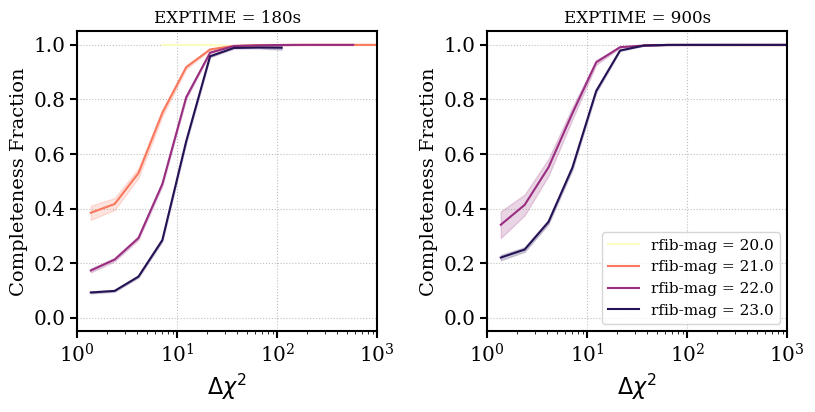

In [515]:
mask = (sum_emi_tot_v2["MAG_R"] > 19)& (sum_emi_tot_v2["MAG_R"] < 24)

plot_1d_purity_fracs(sum_emi_tot_v2,  mask, dchi2_bins = 10**np.arange(0,4.5,np.log10(9)/4) , 
                         variable_split = "MAG_R", var_plot_name = "rfib-mag", variable_bins = np.array([19.5,20.5,21.5,22.5,23.5]),
                         zrr_cut = 0.15,min_bin_count=5,cmap = plt.cm.magma_r,return_catas_frac=True,ylabel = r"Completeness Fraction")

Making redshift success rate plot for simulated spectra

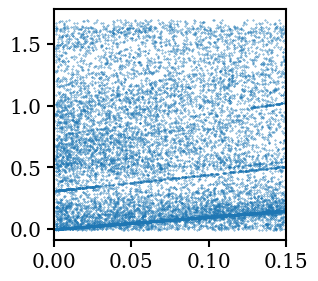

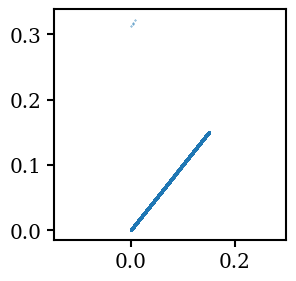

In [516]:
plt.figure(figsize = (3,3))
plt.scatter(sum_emi_tot_v2["Z"], sum_emi_tot_v2["ZRR_900s"],s=0.1)
plt.xlim([0,0.15])
plt.show()

plt.figure(figsize = (3,3))
plt.scatter(sum_emi_tot_v2[sum_emi_tot_v2["DELTACHI2_900s"] > 40]["Z"], sum_emi_tot_v2[sum_emi_tot_v2["DELTACHI2_900s"] > 40]["ZRR_900s"],s=0.1)
plt.show()


### Redshift success rate part

In [519]:
# sum_emi_tot_v2[:2]

In [17]:
def single_zsucc(dataset=sum_emi_tot_v2, dchi2_lab = "DELTACHI2_180s", zwarn_lab = "ZWARN_180s"):

    zfail_rate = []
    zfail_rate_err = []

    rfib_bins = np.arange(20,23.75,0.25)
    min_count = 5

    #looping over fiber mags 
    for r in range(len(rfib_bins) - 1):
        lowz_ij = dataset[(dataset["MAG_R"] >= rfib_bins[r]) & (dataset["MAG_R"] <= rfib_bins[r+1]) ]

        lowz_ij_zsucc = (lowz_ij[dchi2_lab] > 40) & (lowz_ij[zwarn_lab] == 0) 

        #now compute the redshift failure rate 
        tot_num = len(lowz_ij)
        fail_num = len(lowz_ij[~lowz_ij_zsucc])
        succ_num = len(lowz_ij[lowz_ij_zsucc])

        if tot_num > min_count:
            fail_rate = fail_num/(fail_num + succ_num)
            rate_err = np.sqrt(  fail_rate * (1 - fail_rate) / tot_num )

            #this is the error estimator from the binomial estimator
            zfail_rate.append(fail_rate)
            zfail_rate_err.append(rate_err)
        else:
            zfail_rate.append(np.nan)
            zfail_rate_err.append(np.nan)


    fb_vals = 0.5*(rfib_bins[1:] + rfib_bins[:-1])
    
    return fb_vals, zfail_rate, zfail_rate_err


In [37]:
ew_min = 0
ew_max = 5

fb_vals, zsucc_3600,_ = single_zsucc(dataset=sum_emi_tot_v2[(sum_emi_tot_v2["HALPHA_EW"] > ew_min) &(sum_emi_tot_v2["HALPHA_EW"] < ew_max) ], dchi2_lab = "DELTACHI2_3600s", zwarn_lab = "ZWARN_3600s")
fb_vals, zsucc_900,_ = single_zsucc(dataset=sum_emi_tot_v2[(sum_emi_tot_v2["HALPHA_EW"] > ew_min) &(sum_emi_tot_v2["HALPHA_EW"] < ew_max) ], dchi2_lab = "DELTACHI2_900s", zwarn_lab = "ZWARN_900s")
fb_vals, zsucc_180,_ = single_zsucc(dataset=sum_emi_tot_v2[(sum_emi_tot_v2["HALPHA_EW"] > ew_min) &(sum_emi_tot_v2["HALPHA_EW"] < ew_max) ], dchi2_lab = "DELTACHI2_180s", zwarn_lab = "ZWARN_180s")

ew_min = 5
ew_max = 20
fb_vals, zsucc_3600_sf,_ = single_zsucc(dataset=sum_emi_tot_v2[(sum_emi_tot_v2["HALPHA_EW"] > ew_min) &(sum_emi_tot_v2["HALPHA_EW"] < ew_max) ], dchi2_lab = "DELTACHI2_3600s", zwarn_lab = "ZWARN_3600s")
fb_vals, zsucc_900_sf,_ = single_zsucc(dataset=sum_emi_tot_v2[(sum_emi_tot_v2["HALPHA_EW"] > ew_min) &(sum_emi_tot_v2["HALPHA_EW"] < ew_max) ], dchi2_lab = "DELTACHI2_900s", zwarn_lab = "ZWARN_900s")
fb_vals, zsucc_180_sf,_ = single_zsucc(dataset=sum_emi_tot_v2[(sum_emi_tot_v2["HALPHA_EW"] > ew_min) &(sum_emi_tot_v2["HALPHA_EW"] < ew_max) ], dchi2_lab = "DELTACHI2_180s", zwarn_lab = "ZWARN_180s")



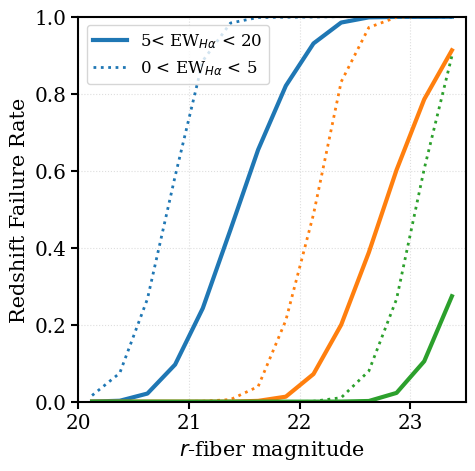

In [51]:
plt.figure(figsize = (5,5))
plt.plot(fb_vals, zsucc_180_sf,lw = 3,color = "tab:blue",label = r"5< EW$_{H\alpha}$ < 20")
plt.plot(fb_vals, zsucc_180,lw = 2,ls = "dotted",label = r"0 < EW$_{H\alpha}$ < 5")

plt.plot(fb_vals, zsucc_900_sf,lw = 3,color = "tab:orange")
plt.plot(fb_vals, zsucc_900,lw = 2,ls = "dotted")

plt.plot(fb_vals, zsucc_3600_sf,lw = 3,color = "tab:green")
plt.plot(fb_vals, zsucc_3600,lw = 2,ls = "dotted")

plt.ylim([0,1])
plt.xlim([20,23.5])
plt.legend(frameon=True,fontsize = 12)
plt.grid(ls=":",color ="lightgrey",alpha = 0.75)
plt.xlabel(r"$r$-fiber magnitude",fontsize = 15)
plt.ylabel(r"Redshift Failure Rate",fontsize = 15)
plt.show()

In [4]:
##in the faint fiber mag bin, what is success rate?
rfib_min = 23.4
rfib_max = 23.6


temp = sum_cont_tot[(sum_cont_tot["MAG_R"] > rfib_min) & (sum_cont_tot["MAG_R"] < rfib_max) & (sum_cont_tot["Z"] < 0.05) & (sum_cont_tot["age"] >= 1) ]
print(len(temp))

len(temp[temp["DELTACHI2_7200s"] > 25])/len(temp)

## with 2 hr exposures, we can detect quenched dwarf galaxy at ~50% completeness at rfib ~ 23.5
## that roughly corresponds to 


176


0.4772727272727273

In [5]:
temp = sum_emi_tot[(sum_emi_tot["MAG_R"] > rfib_min) & (sum_emi_tot["MAG_R"] < rfib_max) & (sum_emi_tot["Z"] < 0.1) & (sum_emi_tot["age"] > 2) ]
print(len(temp))

len(temp[temp["DELTACHI2_7200s"] > 25])/len(temp)

257


0.9027237354085603

### Validating NN model with real data

In [538]:
# from joblib import dump, load
# clf = load("/global/u1/v/virajvm/nn_completeness/mlp_180s_pw.joblib")


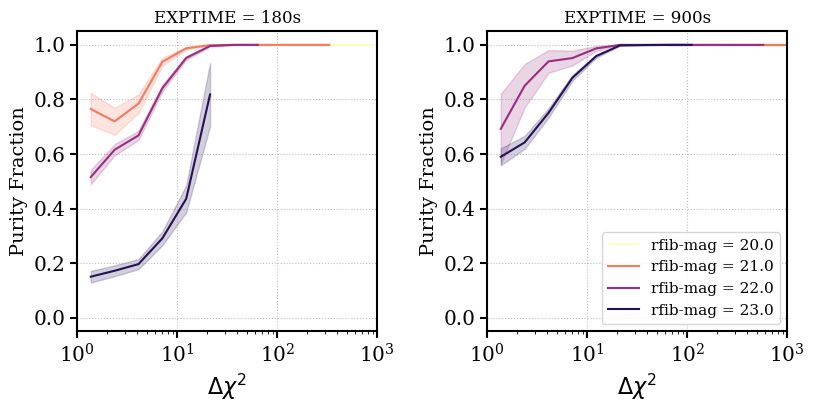

In [535]:
mask = (sum_emi_tot_v2["HALPHA_EW"] > 5)& (sum_emi_tot_v2["HALPHA_EW"] < 10)

plot_1d_purity_fracs(sum_emi_tot_v2,  mask, dchi2_bins = 10**np.arange(0,4.5,np.log10(9)/4), 
                         variable_split = "MAG_R", var_plot_name = "rfib-mag", variable_bins = np.array([19.5,20.5,21.5,22.5,23.5]),
                         zrr_cut = 0.15,min_bin_count=5,cmap = plt.cm.magma_r)



# Would also need to think about fiber assignment weights

Someone has probably already computed these and are somewhere ...

We add them to our final catalog in the analyze catal

In [15]:
import numpy as np

### Original implementation of the functions: https://github.com/cosmodesi/pycorr/tree/main
# from pycorr.twopoint_counter import get_inverse_probability_weight, get_default_nrealizations

def get_default_nrealizations(weights):
    """Return default number of realizations given input bitwise weights = the number of bits in input weights plus one."""
    return 1 + 8 * sum(weight.dtype.itemsize for weight in weights)

_popcount_lookuptable = np.array([bin(i).count('1') for i in range(256)], dtype=np.int32)


def popcount(*arrays):
    """
    Return number of 1 bits in each value of input array.
    Inspired from https://github.com/numpy/numpy/issues/16325.
    """
    # if not np.issubdtype(array.dtype, np.unsignedinteger):
    #     raise ValueError('input array must be an unsigned int dtype')
    toret = _popcount_lookuptable[arrays[0].view((np.uint8, (arrays[0].dtype.itemsize,)))].sum(axis=-1)
    for array in arrays[1:]: toret += popcount(array)
    return toret

def _vlogical_and(*arrays):
    # & between any number of arrays
    toret = arrays[0].copy()
    for array in arrays[1:]: toret &= array
    return toret

def get_inverse_probability_weight(*weights, noffset=1, nrealizations=None, default_value=0., correction=None, dtype='f8'):
    r"""
    Return inverse probability weight given input bitwise weights.
    Inverse probability weight is computed as::math:`\mathrm{nrealizations}/(\mathrm{noffset} + \mathrm{popcount}(w_{1} \& w_{2} \& ...))`.
    If denominator is 0, weight is set to default_value.

    Parameters
    ----------
    weights : int arrays
        Bitwise weights.

    noffset : int, default=1
        The offset to be added to the bitwise counts in the denominator (defaults to 1).

    nrealizations : int, default=None
        Number of realizations (defaults to the number of bits in input weights plus one).

    default_value : float, default=0.
        Default weight value, if the denominator is zero (defaults to 0).

    correction : 2D array, default=None
        Optionally, divide weight by ``correction[nbits1, nbits2]`` with ``nbits1``, ``nbits2`` the number of non-zero bits in weights.

    dtype : string, np.dtype
        Type for output weight.

    Returns
    -------
    weight : array
        IIP weight.
    """
    if nrealizations is None:
        nrealizations = get_default_nrealizations(weights[0])
    # denom = noffset + sum(utils.popcount(w1 & w2) for w1, w2 in zip(*weights))
    denom = noffset + sum(popcount(_vlogical_and(*weight)) for weight in zip(*weights))
    mask = denom == 0
    denom[mask] = 1
    toret = np.empty_like(denom, dtype=dtype)
    toret[...] = nrealizations / denom
    if correction is not None:
        c = tuple(sum(popcount(w) for w in weight) for weight in weights)
        toret /= correction[c]
    toret[mask] = default_value
    return toret

def _format_bitweights(bitweights):
    if bitweights.ndim == 2: return list(bitweights.T)
    return [bitweights]

from astropy.table import Table

tab = Table.read("/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/kibo-v1/LSScats/v0.1/BGS_ANY_full.dat.fits")


In [2]:
iip_weight = get_inverse_probability_weight(_format_bitweights(tab['BITWEIGHTS'].data))
tab.add_column(iip_weight, name='WEIGHT_IIP')

In [3]:
tab = tab["TARGETID","RA","DEC","WEIGHT_IIP"]

In [6]:
tab[:2]

TARGETID,RA,DEC,WEIGHT_IIP
int64,float64,float64,float64
39627322533350395,11.20171365459861,-19.375325006211153,2.58
39627322533350460,11.203232281237451,-19.376395065537405,1.8695652173913044


In [7]:
bgs_bri = Table.read("/pscratch/sd/v/virajvm/catalog/jura_bgs_bright_all_phot_final_filter.fits")

In [9]:
import astropy.units as u
from astropy.coordinates import SkyCoord

In [10]:
## we need to match by TARGETID so we an assign WEIGHT_IIP column
catalog = SkyCoord(ra= np.array(tab["RA"])* u.degree, dec= np.array(tab["DEC"])*u.degree )
c = SkyCoord(ra=np.array(bgs_bri["TARGET_RA"])*u.degree, dec=np.array(bgs_bri["TARGET_DEC"])*u.degree )

idx, d2d, d3d = c.match_to_catalog_sky(catalog)


In [11]:
len(d2d)

8503924

In [12]:
len(d2d[d2d.arcsec != 0])

334944

In [16]:
tab[tab["TARGETID"] == 39627797550863303]

TARGETID,MWS_TARGET,SUBPRIORITY,PRIORITY_INIT,TARGET_STATE,TIMESTAMP,PRIORITY,LOCATION,TILEID,TILELOCID,LASTNIGHT,Z_not4clus,ZERR,ZWARN,CHI2,COEFF,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,FIBER,COADD_FIBERSTATUS,FIBERASSIGN_X,FIBERASSIGN_Y,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_PSF_TO_FIBER_SPECFLUX,TSNR2_BGS_B,TSNR2_ELG_B,TSNR2_LRG_B,TSNR2_LYA_B,TSNR2_QSO_B,TSNR2_BGS_R,TSNR2_ELG_R,TSNR2_LRG_R,TSNR2_LYA_R,TSNR2_QSO_R,TSNR2_BGS_Z,TSNR2_ELG_Z,TSNR2_LRG_Z,TSNR2_LYA_Z,TSNR2_QSO_Z,TSNR2_BGS,TSNR2_ELG,TSNR2_LRG,TSNR2_LYA,TSNR2_QSO,ZWARN_MTL,Z_QN,Z_QN_CONF,IS_QSO_QN,PRIORITY_ASSIGNED,GOODPRI,GOODHARDLOC,LOCATION_ASSIGNED,TILELOCID_ASSIGNED,NTILE,TILES,BRICKID,BRICKNAME,MORPHTYPE,RA,DEC,DCHISQ,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,NOBS_G,NOBS_R,NOBS_Z,PSFDEPTH_G,PSFDEPTH_R,PSFDEPTH_Z,GALDEPTH_G,GALDEPTH_R,GALDEPTH_Z,FLUX_W1,FLUX_W2,FLUX_IVAR_W1,FLUX_IVAR_W2,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,WISEMASK_W1,WISEMASK_W2,MASKBITS,SHAPE_R,PHOTSYS,DESI_TARGET,BGS_TARGET,COMP_TILE,FRACZ_TILELOCID,FRAC_TLOBS_TILES,WEIGHT_ZFAIL,mod_success_rate,BITWEIGHTS,PROB_OBS
int64,int64,float64,int64,bytes30,bytes25,int64,int64,int64,int64,int32,float64,float64,int64,float64,float64[10],int64,bytes6,bytes20,int64,float64,int32,int32,float32,float32,int16,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,float64,float64,int16,int32,bool,bool,bool,bool,int64,bytes29,int32,bytes8,bytes4,float64,float64,float32[5],float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,uint8,uint8,int16,float32,bytes1,int64,int64,float64,float64,float64,float64,float64,int64[2],float64


In [17]:
## hmmmm so there are some objects that do not have rows in the LSS catalog file ...

# Getting stellar mass-complete sample

This would be useful for comparing our volume correction method to stellar-mass complete sample. Also, check for any redshift trends.


Need to determine the completeness of each stellar mass at each redshift.

One strategy is to just identify the volume in which I can identify $g-r = 0.8$ galaxies.



In [68]:
## load the dataset

bgs_bri = Table.read("/pscratch/sd/v/virajvm/catalog/Iron_bgs_bright_all_phot_final_filter.fits")
# lowz_dark = Table.read("/pscratch/sd/v/virajvm/catalog/Iron_lowz_dark_all_phot_final_fixed.fits")
bgs_bri_zsucc = bgs_bri[(bgs_bri["ZWARN"] == 0) & (bgs_bri["Z"] < 0.2) & (bgs_bri["Z"] > 0.001) & (bgs_bri["SPECTYPE"] == "GALAXY") ]
print(len(bgs_bri_zsucc))

del bgs_bri

## now get stellar mass
from desi_lowz_funcs import get_stellar_mass

bgs_bri_zsucc['LOGMSTAR'] = get_stellar_mass(bgs_bri_zsucc["MAG_G"] - bgs_bri_zsucc["MAG_R"], bgs_bri_zsucc["MAG_R"], bgs_bri_zsucc['Z'])

# bgs_bri_zsucc  = Table.read("/pscratch/sd/v/virajvm/catalog/Iron_bgs_bright_zsucc_ms_z01_wenv.fits")


1995034


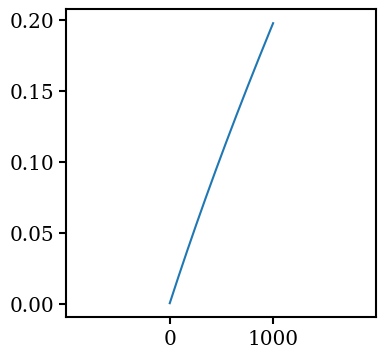

In [60]:
## get a spline interpolation for z_at_value for speed

# let us define a spline for z_at_value function
from scipy.interpolate import UnivariateSpline
from astropy.cosmology import Planck18, z_at_value

    
max_d_grid = np.linspace(1,1000,20000)
z_lumi_grid = z_at_value( Planck18.luminosity_distance, max_d_grid*u.Mpc).value

z_at_lumi_spl = UnivariateSpline(max_d_grid, z_lumi_grid, s= 0)

plt.figure(figsize = (4,4))
plt.plot(max_d_grid, z_lumi_grid)
plt.show()


In [69]:
## finding the redshift at which a given stellar mass and color are within r<19.5

def get_mag_from_stellar_mass(gr,mstar):
    '''
    Computes the stellar mass of object using the SAGA 2 conversion
    
    It is given by Log10(Mstar) = 1.254 + 1.098*(g-r) - 0.4 M_r
    /
    We would need to get the absolute r band mag above. We will also have to a K correction to the absolute magnitude .. 
    
    '''
    from astropy.cosmology import Planck18, z_at_value
    
    # log_star = 1.254 + 1.098*gr - 0.4*M_r
    M_r = -1*(mstar - 1.254 - 1.098*gr)/0.4

#     #M = m + 5 - 5*log10(d/pc) - Kcor
    # rmag = M_r - 5 + 5*np.log10(d_in_pc)
    
    d_in_mpc = 10**((19.5 - M_r + 5)/5) / 1e6
    # zred_limit = z_at_value(Planck18.luminosity_distance, d_in_mpc*u.Mpc)
    zred_limit = z_at_lumi_spl(d_in_mpc)
    
    return zred_limit


In [70]:
mstar_grid = np.linspace(6,9,100)
zred_complete = get_mag_from_stellar_mass(0.8, mstar_grid)

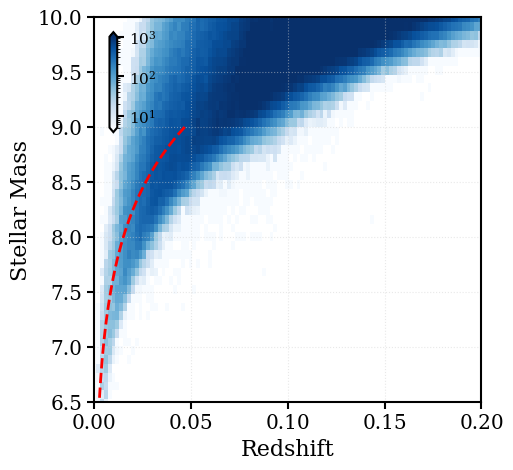

In [71]:
fig, ax = plt.subplots(figsize = (5,5))

hist = ax.hist2d(bgs_bri_zsucc["Z"],bgs_bri_zsucc["LOGMSTAR"], bins=100, norm = LogNorm(vmin = 5,vmax = 1e3),cmap = "Blues",
         label = "Y1 BGS Bright")

plt.plot(zred_complete, mstar_grid, color = "r",lw =2,ls = "--")

p  = ax.get_position().get_points().flatten()
# this is used to modify the position of the colorbar in the plot
# last number is thickness
cax= fig.add_axes([p[0]+0.04*(p[2]-p[0]) , p[1]+0.7*(p[3]-p[1]) , 0.02*(p[2]-p[0]) , 0.2])

cbarticks = [1e1,1e2,1e3]

cbar = plt.colorbar(hist[3], cax=cax, orientation='vertical', ticklocation='right', extend='both', ticks=cbarticks)
# cbar.set_label(r'Galaxy Counts', fontsize=11)
cbar.ax.tick_params(labelsize = 11)

ax.set_ylim([6.5,10])
ax.grid(ls=":",color = "lightgrey",alpha = 0.5)
ax.set_xlim([0,0.2])
ax.set_xlabel("Redshift",fontsize = 16)
ax.set_ylabel("Stellar Mass",fontsize = 16)

# ax.text(0.065, 7.15,"BGS Bright ($r$ = 19.5)",fontsize = 14, color = bgs_col, weight = "bold")

# plt.savefig("paper_plots/mstar_zred_iron_bgs_lowz_v1.png",bbox_inches="tight")

plt.show()

The above line denotes the region of space where we are complete to both blue and red galaxies at that stellar mass.
That will be the region in which we can do our stellar mass complete analysis (no need for additional volume correction).

This is a little more tricky to do for larger stellar mass galaxies as the g-r=0.8 limit for them no longer applies. Those galaxies can be redder.



In [72]:
bgs_bri_zsucc_ms9 = bgs_bri_zsucc[(bgs_bri_zsucc["LOGMSTAR"] < 9) & (bgs_bri_zsucc["LOGMSTAR"] > 6)]

In [73]:
ms_complete_mask = bgs_bri_zsucc_ms9["Z"] < get_mag_from_stellar_mass(0.8, bgs_bri_zsucc_ms9["LOGMSTAR"])

In [74]:
bgs_bri_zsucc_ms9_complete = bgs_bri_zsucc_ms9[ms_complete_mask]

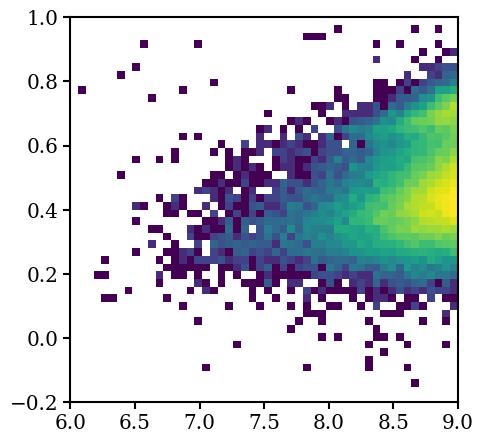

In [75]:
plt.figure(figsize = (5,5))
# plt.scatter(bgs_bri_zsucc_ms9_complete["LOGMSTAR"], bgs_bri_zsucc_ms9_complete["MAG_G"] - bgs_bri_zsucc_ms9_complete["MAG_R"],s=1)
plt.hist2d(bgs_bri_zsucc_ms9_complete["LOGMSTAR"], bgs_bri_zsucc_ms9_complete["MAG_G"] - bgs_bri_zsucc_ms9_complete["MAG_R"],cmap = "viridis",
          range = ( (6,9),(-0.2,1) ), bins = 50,norm=LogNorm())
plt.xlim([6,9])
plt.ylim([-0.2,1])
plt.show()


In [76]:
bgs_bri_zsucc_ms9_complete

TARGETID,SURVEY,PROGRAM,HEALPIX,TILEID_LIST,RA,DEC,COADD_FIBERSTATUS,CMX_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,SV2_DESI_TARGET,SV2_BGS_TARGET,SV2_MWS_TARGET,SV3_DESI_TARGET,SV3_BGS_TARGET,SV3_MWS_TARGET,SV1_SCND_TARGET,SV2_SCND_TARGET,SV3_SCND_TARGET,Z,ZWARN,DELTACHI2,SPECTYPE,Z_RR,TSNR2_BGS,TSNR2_LRG,TSNR2_ELG,TSNR2_QSO,TSNR2_LYA,PHOTSYS,LS_ID,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_W3,FLUX_W4,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FLUX_IVAR_W3,FLUX_IVAR_W4,EBV,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,MW_TRANSMISSION_W3,MW_TRANSMISSION_W4,MAG_G,MAG_R,MAG_Z,MAG_W1,MAG_W2,MAG_G_ERR,MAG_R_ERR,MAG_Z_ERR,MAG_W1_ERR,MAG_W2_ERR,SHAPE_R,SHAPE_R_ERR,MU_R,MU_R_ERR,SERSIC,SERSIC_IVAR,BA,TYPE,PHI,FIBERMAG_R,zfail_all_phot,zfail_all_phot_tsnr,zfail_rfib_tsnr,zfail_all_phot_norz,LOGMSTAR
int64,bytes7,bytes6,int32,bytes47,float64,float64,int32,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,int64,float64,bytes6,float64,float32,float32,float32,float32,float32,bytes1,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,bytes3,float32,float32,float64,float64,float64,float64,float64
39627791523646374,main,bright,0,23814,45.107412081061895,0.15230363149867882,0,--,1152921504606846976,131074,0,0,--,--,--,--,--,--,--,--,--,--,--,--,0.023979384866062825,0,998.654891833663,GALAXY,0.023979384866062825,1698.4805,20.544725,31.885496,7.350897,15.145401,S,9906621523430310,1.5225862,2.3564954,3.1799943,2.0524378,2.8816452,3.5589495,34.808796,48.871937,60.358833,42.207447,34.450256,-67.93599,-2133.855,71.45392,45.246964,5.934168,0.9519575,0.23028675,0.00065966515,1.031006e-05,0.10094031,0.7418428,0.8177604,0.8935205,0.9830391,0.98954946,0.99776196,0.9991543,18.645777,18.277351,18.048147,18.436527,18.657019,0.0036942605,0.0033065514,0.007392797,0.026395608,0.06575104,8.992577,0.0025444517,25.042221,0.0033631278,1.4359561,9755.252,0.09652821,SER,-64.44043,21.569334,0.10655737704918034,0.11538461538461542,0.04276060878460064,0.09956709956709953,8.412725420149336
39627791523649383,main,bright,0,23814,45.21519322729799,0.3557050164646805,0,--,1152921504606846976,131074,0,0,--,--,--,--,--,--,--,--,--,--,--,--,0.02806489239734739,0,4583.252862840891,GALAXY,0.02806489239734739,1518.9043,17.400623,28.273912,6.466544,9.145574,S,9906621523433319,5.121034,7.456024,9.522251,7.1014457,9.293273,10.771419,75.16758,98.3677,114.013596,39.0841,38.380505,323.46268,-12447.799,69.8278,48.53407,8.844204,1.281558,0.33848524,0.0009369062,1.0069285e-05,0.11051457,0.72112554,0.8023033,0.88402945,0.9814454,0.9885639,0.99754995,0.99907416,17.809923,17.517868,17.357609,18.52,18.539722,0.0017305526,0.0015861845,0.0032058524,0.024567463,0.04867982,3.3729134,0.0037637802,22.153343,0.0028956684,1.6623745,48190.312,0.66264373,SER,89.52266,20.318731,0.017921146953404965,0.00512820512820511,0.021925662784454514,0.019108280254777066,8.769690376302345
39627803603245552,main,bright,0,25387,45.22907948186613,0.7727302746954612,0,--,1152921504606846976,131074,0,0,--,--,--,--,--,--,--,--,--,--,--,--,0.04347297871159505,0,129.5014958884567,GALAXY,0.04347297871159505,1414.5103,16.981112,27.307835,6.0110598,13.781524,S,9906621712177648,1.0849725,1.7471046,2.3811576,1.4332765,2.1075587,2.6446886,29.093061,42.779835,53.68265,22.431103,6.567202,42.033722,583.57855,91.34042,49.060425,7.753145,1.2221589,0.30761486,0.0007844981,9.785911e-06,0.09410903,0.7569875,0.8289708,0.9003546,0.9841778,0.99025327,0.99791324,0.99921155,18

## Generative model to forward model quenched fraction observations

The trickiest part is to model the color distribution and the mapping from color to quenched. One idea is to look at a volume-complete sample and look at color dist. (hopefully simple like Gaussian) and fquench as a function of color. 

If I have a complete sample of color distribution. Looking at Figure 11 in SAGA 3 paper, it seems it is non-trivial to model it? I could go in a plane perpendicular to that line and model like that?

How do I get the number density in different environments correctly? I will be looking at isolated galaxies and so would need to know what is the number density of galaxies to correctly forward model .. The question is:  what is the luminosity function of galaxies conditioned on distance to nearby host. We could assume it has the same slope etc., but the amplitude? Maybe, the amplitude can be obtained by seeing what fraction of volume we remove when drawing spheres around massive galaxies ..??


Maybe the best approach is to model the color distribution of quenched galaxies and star-forming galaxies separately



In [23]:
# ## I want to measure the HALPHA FLUX using the truth redshft
# ## this would entail going into the spectra and redshifting to restframe and then seeing if there is an emission line ...

# ## so the program is bright and survey is main
# ## we just need healpix

# # import DESI related modules - 
# from desimodel.footprint import radec2pix      # For getting healpix values
# import desispec.io                             # Input/Output functions related to DESI spectra
# from desispec import coaddition                # Functions related to coadding the spectra
# from astropy.convolution import convolve, Gaussian1DKernel
# from astropy.table import QTable

# def get_spectra(tgid_interest,hpx,ztrue,plot=True,save=False,save_path=None):
#     '''
#     Function that gets the spectra for the single object.
    
#     The following need to be run before this function
    
#     # import DESI related modules - 
#     from desimodel.footprint import radec2pix      # For getting healpix values
#     import desispec.io                             # Input/Output functions related to DESI spectra
#     from desispec import coaddition                # Functions related to coadding the spectra
#     from astropy.convolution import convolve, Gaussian1DKernel

#     specprod = 'iron'    # Internal name for the EDR
#     specprod_dir = '/global/cfs/cdirs/desi/spectro/redux/iron/'

#     zpix_cat = Table.read(f'{specprod_dir}/zcatalog/zall-pix-{specprod}.fits', hdu="ZCATALOG")  
#     healpix_dir = f'{specprod_dir}/healpix'
    
#     '''
#     # Let us explore the target directory
#     # Note that the target directory is different for the different spectra.
#     # We first explore the primary spectra and look at the other spectra later.
#     healpix_dir = "/global/cfs/cdirs/desi/spectro/redux/jura/healpix"
#     survey = "main"
#     program = "bright"
    
#     tgt_dir = f'{healpix_dir}/{survey}/{program}/{hpx//100}/{hpx}'
    
#     coadd_filename = f'coadd-{survey}-{program}-{hpx}.fits'    
    
#     h_coadd = fits.open(f'{tgt_dir}/{coadd_filename}')
    
#     coadd_obj = desispec.io.read_spectra(f'{tgt_dir}/{coadd_filename}')
#     coadd_tgts = coadd_obj.target_ids().data
#     #coadd the spec now 
    
#     # Selecting the particular spectra of the targetid
#     row = (coadd_tgts == tgid_interest)
#     coadd_spec = coadd_obj[row]
    
#     spec_combined = coaddition.coadd_cameras(coadd_spec)    
    
    
#     if plot==True:
#         plt.figure(figsize = (7, 7))
#         # Plot the combined spectrum in maroon
#         plt.plot(spec_combined.wave['brz']/(1+ztrue), spec_combined.flux['brz'][0], color = 'grey', alpha = 0.4)
#         plt.plot(spec_combined.wave['brz']/(1+ztrue), 1/np.sqrt(spec_combined.ivar['brz'][0]),color = "darkorange",alpha = 0.3)
#         # Over-plotting smoothed spectra 
#         plt.plot(spec_combined.wave['brz']/(1+ztrue), convolve(spec_combined.flux['brz'][0], Gaussian1DKernel(2)) , color = 'k', lw = 1.25)

#         # plt.text(6000,np.max(spec_combined.flux['brz'][0][500:-500])*0.7,r"$z_{\rm True} = %.4f$, TARGETID = %d"%(ztrue,tgid_interest),fontsize = 22)

#         ## we need to plot the restframe lines here
#         # plt.vlines(x = 6562.8, ymin = -1,ymax = 10,lw = 1,alpha = 0.75,ls = "--",color ="slateblue",zorder = -10)
#         # plt.vlines(x = 4861.4, ymin = -1,ymax = 10,lw = 1,alpha = 0.75,ls = "--",color ="slateblue",zorder = -10)
#         # plt.vlines(x = 4340.5, ymin = -1,ymax = 10,lw = 1,alpha = 0.75,ls = "--",color ="slateblue",zorder = -10)
#         # plt.vlines(x = 4959, ymin = -1,ymax = 10,lw = 2,alpha = .75,ls = "--",color ="slateblue",zorder = -10)
#         # plt.vlines(x = 5007, ymin = -1,ymax = 10,lw = 2,alpha = .75,ls = "--",color ="slateblue",zorder = -10)
#         # plt.vlines(x = 3729, ymin = -1,ymax = 10,lw = 2,alpha = .75,ls = "--",color ="slateblue",zorder = -10)
            
#         # plt.xlim([3550, 9400])
#         plt.xlim([6563 - 50, 6553 + 50])
#         wave_rest = spec_combined.wave['brz']/(1+ztrue)
        
#         wmask = (wave_rest > 6563 - 50) & (wave_rest < 6563 + 50)
        
#         plt.vlines( x = 6564, ymin =-0.2, ymax= np.max(spec_combined.flux['brz'][0][wmask] )*1.1, lw = 2,  color = "slateblue",alpha = 0.6   )
#         plt.vlines( x = 6564-4*1.6, ymin =-0.2, ymax= np.max(spec_combined.flux['brz'][0][wmask] )*1.1, lw = 2,  color = "slateblue",alpha = 0.6   )
#         plt.vlines( x = 6564+4*1.6, ymin =-0.2, ymax= np.max(spec_combined.flux['brz'][0][wmask] )*1.1, lw = 2,  color = "slateblue",alpha = 0.6   )
        
#         ## let us draw a horizontal line
#         wmask_cont = (wave_rest > 6500) & (wave_rest < 6535)
#         cont_est = np.mean(spec_combined.flux['brz'][0][wmask_cont]) 
#         plt.hlines(y = cont_est , xmin = 6563-50, xmax = 6563 + 50,color = "k", lw =2 )
        
#         plt.ylim([-0.2,np.max(spec_combined.flux['brz'][0][wmask] )*1.1])
#         plt.xlabel('Rest-Frame Wavelength [$\AA$]',fontsize = 22)
#         plt.ylabel('$F_{\lambda}$ [$10^{-17} erg\ s^{-1}\ cm^{-2}\ \AA^{-1}$]',fontsize = 22)
#         plt.xticks(fontsize = 15)
#         plt.yticks(fontsize = 12)
       
#         if save:
#             plt.savefig(save_path + "plot_%d.png"%tgid_interest)
#             plt.close()
#         else:
#             plt.show()
            
#     if save:
#         spec_tab = QTable([spec_combined.wave['brz'], spec_combined.flux['brz'][0], spec_combined.ivar['brz'][0]],names=('wave', 'flux', 'ivar') )
#         spec_tab.write(save_path + "spectra_%d.fits"%tgid_interest,overwrite=True)

        
#     wave = spec_combined.wave['brz']/(1+ztrue)
#     flux = spec_combined.flux['brz'][0]
    
#     haflux_val = np.sum( flux[(wave > 6564 - 3*1.6) & (wave < 6564 + 3*1.6)] * np.diff(wave)[0] )
    
#     cont_flux = cont_est * (2 * 3 * 1.6)
    
#     return haflux_val - cont_flux

